#**Título - Doação de sangue**


**Nome:** Leandro Miozzo Bonato
**Matrícula:**  4052025001550

**Link do dataset:** https://www.kaggle.com/datasets/tarekmasryo/blood-donor-registry-dataset
**arquivo:** blood_donation_registry_ml_ready.csv




##Introdução

A doação de sangue ajuda a salvar muitas vidas todos os anos no mundo inteiro das mais diversas formas, sejam por doenças, acidentes ou cirurgias onde houveramm complicações e o paciente necessitou de uma transfusão de sangue.

Já para realizar a doação de sangue há algumas regras, sendo elas:
*   16 e 69 anos
*   Primeira doação até 60 anos
*   Peso maior que 50 kg
*   Não pode ter tido gripe em 30 dias
*   Não pode doar se possuir tatuagens pelo corpo
*   Após 180 dias a gestação
*   Não ter ingerido álcool nas últimas 12 horas
*   Não ter efetuado viagens para áreas de malária nos últimos 6 meses.
*   Não ter realizado procedimentos médicos como: Endoscopia, Colonoscopia nos últimos 6 meses, cirurgias de pequeno porte nos últimos 3 meses ou grande porte em até 12 meses.
*   Não possuir doenças sexualmente transmissíveis.
*   Não possuir Hepatite
*   Não usar drogas injetáveis
*   Não realizar o uso de insulina para dibetes
*   Não possuir cancêr
*   Não possuir doenças cardíacas
*   Não possuir doenças pulmonares.



##Descrição do problema
Um grande problema para a doação de sangue é a quantidade de pessoas que optam por doar sangue, por restrições de doença e condições pessoais, pela idade, opções religiosas, receios e medos, lendas urbanas, fakes news, e entre outros motivos peculiares.

Essas situações exigem que os centros de bancos de sangue tenham que realizar cada vez mais campanhas e divulgações, principalmente combatendo fakes news.

###Hipóteses do Problema
As hipóteses de problemas levantados serão:

1. Qual o tipo de sangue que possuí a maior quantidade de doadores com restrições.

2. Quantidade de doadores por sexo.

3. Doadores de sangue fumantes.

###Tipo de Problema
Este é um problema de **classificação supervisionada**, pois os dados da quantidade de sessões estão bem curados, tendo como objetivo separar algumas informações e mostrá-las visualmente em gráficos.

###Seleção dos dados
A seleção destas informações são para realizar um estudo sobre a doação de sangue no mundo, pois o dataset possuí apenas 30 mil registros, e sabe-se que no mundo a doação de sangue todos os anos passa de 100 milhões (segundo daddos da OMS), então esta é apenas uma pequena amostra.

###Atributos do dataset
O dataset possuí 30000 amostras e os seguintes atributos (nome do atributo - tipo do dados - descrição do dado):

**as_of_date** - Date - Instantâneo no nível do doador com uma data de referência.

**donor_id** - Integer - identificador único do doador de sangue.

**country_code** - String - Sigla do país

**region** - String - Nome da região/continente

**age** - Integer - Idade do doador.

**sex** - String - Sexo do doador (M/F).

**bmi** - Float - Índice de massa corporal.

**smoker** - Integer - Indicador se o doador é fumante (valores: 0 ou 1).

**chronic_condition_flag** - Integer - Indicador de condição crônia (valores: 0 ou 1).

**eligibility_status** - String - Indicador da condição do doador para a doação de sangue, possíveis valores (eligible - elegível | temporary_deferral - inelegível temporariamente | permanent_deferral - ilegível permanentemente).

**eligible_to_donate** - Integer - indicador se o doador está elegível para a doação

**deferral_reason** - String - Indicador de motivo de adiamento para a doação, possíveis valores: age_out_of_range - idade fora do permitido | bmi_out_of_range - massa corporal fora do permitido | chronic_condition - condição crônica | sem valores quando elegível.

**preferred_site** - String - Indicador de local de doação do doador, possíveis valores: hospital - doação no hospital | mobile_unit - unidade móvel | community_camp - acampamento comunitário/temporário.

**donation_count_last_12m** - Integer - quantiidade de doações nos últimos 12 meses.

**lifetime_donation_count** - Integer - Quantidade de doações feitas pelo doador durante sua vida.

**first_donation_year** - Integer - Ano da primeira doação

**years_since_first_donation** - Integer - Anos desde a primeira doação.

**last_donation_date** - Date - Data da última doação realizada.

**recency_days** - Integer - Quantidade de dias desde a última vez de sangue doado.

**is_regular_donor ** - Integer - Indicativo se é um doador regular (possíveis valores: 0 ou 1)

**donor_age_at_first_donation** - Integer - Idade da primeira doação.

**blood_type** - String - Tipo sanguineo

**is_rare_type ** - Integer - Indicativo se é um sangue raro (possíveis valores: 0 ou 1).

**blood_type_country_prevalence** - Float - Variação de prevalência dos tipos sanguineos entre os países.

**donation_propensity_score** - Float - métrica na gestão de doadores para estimar a probabilidade de um doador voltar a a doar sangue.

**donated_next_6m** - Integer - se o doador estará apto a doar sangue nos próximos 6 meses (possíveis valores: 0 ou 1)


**next_6m_donation_count** - Integer - métrica usada para ter ideia sobre a quantidade de possíveis doações para os próximos seis meses (possíveis valores: 0, 1, 2 e 3).

##Instalação dos recursos
Grupo para a instalação dos pacotes que serão usados neste projeto MVP e no final será enviado um comando para reinicializar o python.

In [ ]:
!pip install kagglehub


In [ ]:
!pip install kagglehub[pandas-datasets]

In [ ]:
!pip install requests pandas tqdm

In [ ]:
!pip install -q requests pandas tqdm

##Importação dos recursos usados no projeto
Neste grupo será centralizado todos os imports de pacotes que serão usados durante as excuções para o projeto MVP.

In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from kagglehub import KaggleDatasetAdapter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score

##Carga de dados
O algorítmo abaixo será para realizar a busca via link do arquivo CSV que foi armazenado no github que está público.

In [ ]:
path = kagglehub.dataset_download("tarekmasryo/blood-donor-registry-dataset")

Using Colab cache for faster access to the 'blood-donor-registry-dataset' dataset.


In [ ]:
#é a mesma celula da anterior, porém há um bug que ele realiza o download
#na primeira vez e não consegue executar a próxima celula, pois não encontra os
#arquivos, então essa célula sendo executada novamente não gera erros.

path = kagglehub.dataset_download("tarekmasryo/blood-donor-registry-dataset")

Using Colab cache for faster access to the 'blood-donor-registry-dataset' dataset.


In [ ]:
dataset = pd.read_csv("/kaggle/input/blood-donor-registry-dataset/data/blood_donation_registry_ml_ready.csv")
print(dataset.count())

donor_id                         30000
age                              30000
sex                              30000
country_code                     30000
region                           30000
blood_type                       30000
is_rare_type                     30000
smoker                           30000
bmi                              30000
chronic_condition_flag           30000
eligible_to_donate               30000
deferral_reason                   5085
preferred_site                   30000
donation_count_last_12m          30000
is_regular_donor                 30000
years_since_first_donation       30000
lifetime_donation_count          30000
first_donation_year              30000
last_donation_date               30000
recency_days                     30000
donor_age_at_first_donation      30000
blood_type_country_prevalence    30000
donation_propensity_score        30000
eligibility_status               30000
as_of_date                       30000
donated_next_6m          

##Layouts e estilos padrões

In [ ]:
plt.style.use('default')
sns.set_palette("husl")
sns.set_theme(style="whitegrid")

cores_genero = ['#4e79a7', '#e15759']
cores_genero_dict = {'M': '#4e79a7', 'F': '#e15759'}
cores_genero_portugues = {'Masculino': '#4e79a7', 'Feminino': '#e15759'}

cores_fumantes = ['#4e79a7', '#e15759']
cores_fumantes_portugues = {'Não Fumantes': '#4e79a7', 'Fumantes': '#e15759'}
cores_fumantes_dict = {0: '#4e79a7', 1: '#e15759'}

##Variáveis globais

In [ ]:
total_doadores_geral = dataset['sex'].count()

dataset_tipo_sanguineo = sorted(dataset['blood_type'].unique())
total_doadores_por_tipo = dataset['blood_type'].value_counts()

dataset_com_restricao = dataset[dataset['eligible_to_donate'] == 0].copy()
restricoes_por_tipo = dataset_com_restricao.groupby('blood_type').agg({
    'donor_id': 'count',
    'chronic_condition_flag': ['mean', 'std', 'max', 'min'],
    'smoker': ['mean', 'std', 'max', 'min'],
    'age': ['mean', 'std', 'max', 'min', 'median'],
    'blood_type': 'count'
}).round(2)
restricoes_por_tipo.columns = ['Doadores_com_restricao',
                               'Cond_cronica_media', 'Cond_cronica_desvio', 'Cond_cronica_max', 'Cond_cronica_min',
                               'Fumantes_media', 'Fumantes_desvio', 'Fumantes_max', 'Fumantes_min',
                               'Idade_media', 'Idade_desvio', 'Idade_max', 'Idade_min', 'Idade_mediana',
                               'tipo_sanguino_cont']
restricoes_por_tipo['Cond_cronica_media'] = restricoes_por_tipo['Cond_cronica_media'] * 100
restricoes_por_tipo['Fumantes_media'] = restricoes_por_tipo['Fumantes_media'] * 100
restricoes_por_tipo['Cond_cronica_desvio'] = restricoes_por_tipo['Cond_cronica_desvio'] * 100
restricoes_por_tipo['Fumantes_desvio'] = restricoes_por_tipo['Fumantes_desvio'] * 100
restricoes_por_tipo['Total_doadores'] = restricoes_por_tipo.index.map(total_doadores_por_tipo)
restricoes_por_tipo['Pct_geral'] = ((restricoes_por_tipo['Doadores_com_restricao'] / restricoes_por_tipo['Total_doadores']) * 100).round(1)
restricoes_por_tipo['erro_padrao_cond'] = restricoes_por_tipo['Cond_cronica_desvio'] / np.sqrt(restricoes_por_tipo['tipo_sanguino_cont']).round(2)
restricoes_por_tipo['erro_padrao_fum'] = restricoes_por_tipo['Fumantes_desvio'] / np.sqrt(restricoes_por_tipo['tipo_sanguino_cont']).round(2)
restricoes_por_tipo['erro_padrao_idade'] = restricoes_por_tipo['Idade_desvio'] / np.sqrt(restricoes_por_tipo['Total_doadores']).round(2)
restricoes_por_tipo['ic_95_cond'] = 1.96 * restricoes_por_tipo['erro_padrao_cond'].round(2)
restricoes_por_tipo['ic_95_fum'] = 1.96 * restricoes_por_tipo['erro_padrao_fum'].round(2)
restricoes_por_tipo['ic_95_idade'] = 1.96 * restricoes_por_tipo['erro_padrao_idade'].round(2)
restricoes_por_tipo['cond_ic_inferior'] = restricoes_por_tipo['Cond_cronica_media'] - restricoes_por_tipo['ic_95_cond'].round(2)
restricoes_por_tipo['cond_ic_superior'] = restricoes_por_tipo['Cond_cronica_media'] + restricoes_por_tipo['ic_95_cond'].round(2)
restricoes_por_tipo['fum_ic_inferior'] = restricoes_por_tipo['Fumantes_media'] - restricoes_por_tipo['ic_95_fum'].round(2)
restricoes_por_tipo['fum_ic_superior'] = restricoes_por_tipo['Fumantes_media'] + restricoes_por_tipo['ic_95_fum'].round(2)
restricoes_por_tipo['idade_ic_inferior'] = restricoes_por_tipo['Idade_media'] - restricoes_por_tipo['ic_95_idade'].round(2)
restricoes_por_tipo['idade_ic_superior'] = restricoes_por_tipo['Idade_media'] + restricoes_por_tipo['ic_95_idade'].round(2)
restricoes_por_tipo = restricoes_por_tipo.sort_values('Doadores_com_restricao', ascending=False)

dataset_boxplot_restricao_tipo = dataset_com_restricao[['blood_type', 'age']].copy()
dataset_boxplot_restricao_tipo = dataset_boxplot_restricao_tipo[dataset_boxplot_restricao_tipo['blood_type'].isin(dataset_tipo_sanguineo)]

dataset_genero = sorted(dataset['sex'].unique())
total_doadores_por_genero = dataset['sex'].value_counts()

doadores_por_genero = dataset.groupby('sex').agg({
    'donor_id': 'count',
    'chronic_condition_flag': ['mean', 'std', 'max', 'min'],
    'smoker': ['mean', 'std', 'max', 'min'],
    'age': ['mean', 'std', 'max', 'min', 'median'],
    'blood_type': 'count',
    'eligible_to_donate': ['mean','std', lambda x: (x == 1).sum()],
    'sex': 'count',
    'lifetime_donation_count': ['mean', 'std'],
    'is_regular_donor': ['mean', 'std']

}).round(2)

doadores_por_genero.columns = ['Doadores',
                               'Cond_cronica_media', 'Cond_cronica_desvio', 'Cond_cronica_max', 'Cond_cronica_min',
                               'Fumantes_media', 'Fumantes_desvio', 'Fumantes_max', 'Fumantes_min',
                               'Idade_media', 'Idade_desvio', 'Idade_max', 'Idade_min', 'Idade_mediana',
                               'tipo_sanguino_cont',
                               'apto_media', 'apto_desvio', 'apto_qtd',
                               'genero_cont',
                               'doacoes_vida_media', 'doacoes_vida_desvio',
                               'doador_regular_media', 'doador_regulgar_desvio'
                              ]

doadores_por_genero['Cond_cronica_media'] = doadores_por_genero['Cond_cronica_media'] * 100
doadores_por_genero['Fumantes_media'] = doadores_por_genero['Fumantes_media'] * 100
doadores_por_genero['Cond_cronica_desvio'] = doadores_por_genero['Cond_cronica_desvio'] * 100
doadores_por_genero['Fumantes_desvio'] = doadores_por_genero['Fumantes_desvio'] * 100
doadores_por_genero['Total_doadores'] = total_doadores_geral
doadores_por_genero['Pct_geral'] = ((doadores_por_genero['Doadores'] / doadores_por_genero['Total_doadores']) * 100).round(1)
doadores_por_genero['erro_padrao_cond'] = doadores_por_genero['Cond_cronica_desvio'] / np.sqrt(doadores_por_genero['tipo_sanguino_cont']).round(2)
doadores_por_genero['erro_padrao_fum'] = doadores_por_genero['Fumantes_desvio'] / np.sqrt(doadores_por_genero['tipo_sanguino_cont']).round(2)
doadores_por_genero['erro_padrao_idade'] = doadores_por_genero['Idade_desvio'] / np.sqrt(doadores_por_genero['Total_doadores']).round(2)
doadores_por_genero['ic_95_cond'] = 1.96 * doadores_por_genero['erro_padrao_cond'].round(2)
doadores_por_genero['ic_95_fum'] = 1.96 * doadores_por_genero['erro_padrao_fum'].round(2)
doadores_por_genero['ic_95_idade'] = 1.96 * doadores_por_genero['erro_padrao_idade'].round(2)
doadores_por_genero['cond_ic_inferior'] = doadores_por_genero['Cond_cronica_media'] - doadores_por_genero['ic_95_cond'].round(2)
doadores_por_genero['cond_ic_superior'] = doadores_por_genero['Cond_cronica_media'] + doadores_por_genero['ic_95_cond'].round(2)
doadores_por_genero['fum_ic_inferior'] = doadores_por_genero['Fumantes_media'] - doadores_por_genero['ic_95_fum'].round(2)
doadores_por_genero['fum_ic_superior'] = doadores_por_genero['Fumantes_media'] + doadores_por_genero['ic_95_fum'].round(2)
doadores_por_genero['idade_ic_inferior'] = doadores_por_genero['Idade_media'] - doadores_por_genero['ic_95_idade'].round(2)
doadores_por_genero['idade_ic_superior'] = doadores_por_genero['Idade_media'] + doadores_por_genero['ic_95_idade'].round(2)
doadores_por_genero['apto_porcentagem'] = ((doadores_por_genero['apto_qtd'] / doadores_por_genero['Doadores']) * 100).round(2)
doadores_por_genero = doadores_por_genero.sort_values('Doadores', ascending=False)

doadores_por_fumantes = dataset[dataset['smoker'] == 1].copy()
total_doadores_fumantes = dataset[dataset['smoker'] == 1].value_counts()

doadores_por_fumantes = doadores_por_fumantes.reset_index()
doadores_por_fumantes['Status'] = doadores_por_fumantes['smoker'].map({0: 'Não Fumantes', 1: 'Fumantes'})

doadores_por_fumantes = dataset.groupby('smoker').agg({
    'donor_id': 'count',
    'chronic_condition_flag': ['mean', 'std', 'max', 'min'],
    'smoker': ['count', 'mean', 'std', 'max', 'min'],
    'age': ['mean', 'std', 'max', 'min', 'median'],
    'blood_type': 'count',
    'eligible_to_donate': ['mean','std', lambda x: (x == 1).sum()],
    'sex': 'count',
    'lifetime_donation_count': ['mean', 'std'],
    'is_regular_donor': ['count', 'mean', 'std']

}).round(2)

doadores_por_fumantes.columns = ['Doadores',
                               'Cond_cronica_media', 'Cond_cronica_desvio', 'Cond_cronica_max', 'Cond_cronica_min',
                               'Fumantes_qtd', 'Fumantes_media', 'Fumantes_desvio', 'Fumantes_max', 'Fumantes_min',
                               'Idade_media', 'Idade_desvio', 'Idade_max', 'Idade_min', 'Idade_mediana',
                               'tipo_sanguino_cont',
                               'apto_media', 'apto_desvio', 'apto_qtd',
                               'genero_cont',
                               'doacoes_vida_media', 'doacoes_vida_desvio',
                               'doador_regular_qtd', 'doador_regular_media', 'doador_regular_desvio'
                              ]

doadores_por_fumantes['Cond_cronica_media'] = doadores_por_fumantes['Cond_cronica_media'] * 100
doadores_por_fumantes['Fumantes_media'] = doadores_por_fumantes['Fumantes_media'] * 100
doadores_por_fumantes['Cond_cronica_desvio'] = doadores_por_fumantes['Cond_cronica_desvio'] * 100
doadores_por_fumantes['Fumantes_desvio'] = doadores_por_fumantes['Fumantes_desvio'] * 100
doadores_por_fumantes['Total_doadores'] = total_doadores_geral
doadores_por_fumantes['Pct_geral'] = ((doadores_por_fumantes['Doadores'] / doadores_por_fumantes['Total_doadores']) * 100).round(1)
doadores_por_fumantes['erro_padrao_cond'] = doadores_por_fumantes['Cond_cronica_desvio'] / np.sqrt(doadores_por_fumantes['tipo_sanguino_cont']).round(2)
doadores_por_fumantes['erro_padrao_fum'] = doadores_por_fumantes['Fumantes_desvio'] / np.sqrt(doadores_por_fumantes['tipo_sanguino_cont']).round(2)
doadores_por_fumantes['erro_padrao_idade'] = doadores_por_fumantes['Idade_desvio'] / np.sqrt(doadores_por_fumantes['Total_doadores']).round(2)
doadores_por_fumantes['ic_95_cond'] = 1.96 * doadores_por_fumantes['erro_padrao_cond'].round(2)
doadores_por_fumantes['ic_95_fum'] = 1.96 * doadores_por_fumantes['erro_padrao_fum'].round(2)
doadores_por_fumantes['ic_95_idade'] = 1.96 * doadores_por_fumantes['erro_padrao_idade'].round(2)
doadores_por_fumantes['cond_ic_inferior'] = doadores_por_fumantes['Cond_cronica_media'] - doadores_por_fumantes['ic_95_cond'].round(2)
doadores_por_fumantes['cond_ic_superior'] = doadores_por_fumantes['Cond_cronica_media'] + doadores_por_fumantes['ic_95_cond'].round(2)
doadores_por_fumantes['fum_ic_inferior'] = doadores_por_fumantes['Fumantes_media'] - doadores_por_fumantes['ic_95_fum'].round(2)
doadores_por_fumantes['fum_ic_superior'] = doadores_por_fumantes['Fumantes_media'] + doadores_por_fumantes['ic_95_fum'].round(2)
doadores_por_fumantes['idade_ic_inferior'] = doadores_por_fumantes['Idade_media'] - doadores_por_fumantes['ic_95_idade'].round(2)
doadores_por_fumantes['idade_ic_superior'] = doadores_por_fumantes['Idade_media'] + doadores_por_fumantes['ic_95_idade'].round(2)
doadores_por_fumantes['apto_porcentagem'] = ((doadores_por_fumantes['apto_qtd'] / doadores_por_fumantes['Doadores']) * 100).round(2)
doadores_por_fumantes = doadores_por_fumantes.reset_index()
doadores_por_fumantes['Status'] = doadores_por_fumantes['smoker'].map({0: 'Não Fumantes', 1: 'Fumantes'})
doadores_por_fumantes = doadores_por_fumantes.sort_values('Doadores', ascending=False)
fumantes_idx = doadores_por_fumantes[doadores_por_fumantes['smoker'] == 1].index[0] if len(doadores_por_fumantes[doadores_por_fumantes['smoker'] == 1]) > 0 else 0
nao_fumantes_idx = doadores_por_fumantes[doadores_por_fumantes['smoker'] == 0].index[0] if len(doadores_por_fumantes[doadores_por_fumantes['smoker'] == 0]) > 0 else 1
dataset_fumantes = dataset[dataset['smoker'] == 1]
dataset_nao_fumantes = dataset[dataset['smoker'] == 0]

traducao_variaveis = {
    'age': 'Idade',
    'chronic_condition_flag': 'Cond. Crônica',
    'smoker': 'Fumante',
    'donation_count_last_12m': 'Doações (12m)',
    'lifetime_donation_count': 'Doações (Vida)',
    'years_since_first_donation': 'Anos desde 1ª doação',
    'is_regular_donor': 'Doador Regular',
    'Idade_media': 'Idade Média',
    'Cond_cronica_media': 'Cond. Crônica (%)',
    'Fumantes_media': 'Fumantes (%)',
    'Doadores_com_restricao': 'Doadores Restritos',
    'Pct_geral': 'Percentual Restrição',
    'idade': 'Idade',
    'doacoes_ultimos_12_meses': 'Doações (últimos 12 meses)',
    'doacoes_vida': 'Doações na Vida',
    'anos_desde_primeira_doacao': 'Anos desde a 1ª doação',
    'condicao_cronica': 'Condição Crônica',
    'fumante': 'Fumante',
    'Idade_desvio': 'Desvio Padrão da Idade',
    'doador_regular': 'Doador Regular',
    'Cond_cronica_desvio': 'Desvio Padrão - Cond. Crônica',
    'Fumantes_desvio': 'Desvio Padrão - Fumantes',
    'Idade_mediana': 'Idade Mediana',
    'Idade_max': 'Idade Máxima',
    'Idade_min': 'Idade Mínima',
    'Cond_cronica_max': 'Máx. Cond. Crônica',
    'Cond_cronica_min': 'Mín. Cond. Crônica',
    'Fumantes_max': 'Máx. Fumantes',
    'Fumantes_min': 'Mín. Fumantes',
    'tipo_sanguino_cont': 'Contagem por Tipo Sanguíneo',
    'Total_doadores': 'Total de Doadores',
    'erro_padrao_cond': 'Erro Padrão - Cond. Crônica',
    'erro_padrao_fum': 'Erro Padrão - Fumantes',
    'erro_padrao_idade': 'Erro Padrão - Idade',
    'ic_95_cond': 'IC 95% - Cond. Crônica',
    'ic_95_fum': 'IC 95% - Fumantes',
    'ic_95_idade': 'IC 95% - Idade',
    'cond_ic_inferior': 'Limite Inferior IC - Cond. Crônica',
    'cond_ic_superior': 'Limite Superior IC - Cond. Crônica',
    'fum_ic_inferior': 'Limite Inferior IC - Fumantes',
    'fum_ic_superior': 'Limite Superior IC - Fumantes',
    'idade_ic_inferior': 'Limite Inferior IC - Idade',
    'idade_ic_superior': 'Limite Superior IC - Idade',
    'eligible_to_donate': 'Elegíveis a doar',
    'sex': 'Gênero',
    'Sexo': 'Gênero',
    'blood_type': 'Tipo Sanguíneo',
    'apto_media': 'Elegíveis Média',
    'apto_desvio': 'Elegíveis Desvio',
    'apto_qtd': 'Elegíveis Quantidade',
    'apto_porcentagem': 'Elegíveis (%)',
    'genero_cont': 'Contagem por Gênero',
    'doacoes_vida_media': 'Média de doações na vida',
    'doacoes_vida_qtd': 'Qtd. de doações na vida',
    'doacoes_vida_desvio': 'Desvio doações na vida',
    'doador_regular_media': 'Média de doação regular',
    'doador_regular_qtd': 'Qtd. de doação regular',
    'doador_regular_desvio': 'Desvio de doação regular',
    'Fumantes_qtd': 'Qtd. Fumantes'
}

variaveis_correlacao = ['age', 'chronic_condition_flag', 'smoker',
                        'donation_count_last_12m', 'lifetime_donation_count',
                        'years_since_first_donation', 'is_regular_donor']

variaveis_existentes = [v for v in variaveis_correlacao if v in dataset.columns]

variaveis_agregadas = ['Idade_media', 'Cond_cronica_media', 'Fumantes_media',
                       'Doadores_com_restricao', 'Pct_geral', 'apto_qtd',
                       'apto_porcentagem', 'doacoes_vida_media', 'doacoes_vida_qtd',
                       'doador_regular_media', 'doador_regular_qtd' ]

variaveis_existentes_agregadas_restricao = [v for v in variaveis_agregadas if v in restricoes_por_tipo.columns]

features_existentes_restricao = [f for f in variaveis_correlacao if f in dataset_com_restricao.columns]

indicadores_percentuais = ['Cond. Crônica (%)', 'Fumantes (%)', 'Percentual Restrição', 'Aptos (%)']


##Funções globais

In [ ]:
def tratar_nulos(ADataSet, ANome_Grupo):
    colunas_numericas = ADataSet.select_dtypes(include=[np.number]).columns.tolist()
    colunas_categoricas = ADataSet.select_dtypes(include=['object']).columns.tolist()
    print(f"\n   🔧 Tratando {ANome_Grupo}:")
    print(f"      • Colunas numéricas: {len(colunas_numericas)}")
    print(f"      • Colunas categóricas: {len(colunas_categoricas)}")
    nulos_antes = ADataSet.isnull().sum().sum()
    for col in colunas_numericas:
        if ADataSet[col].isnull().sum() > 0:
            mediana = ADataSet[col].median()
            ADataSet[col] = ADataSet[col].fillna(mediana)
            print(f"      • {col}: preenchido com mediana ({mediana:.2f})")
    for col in colunas_categoricas:
        if ADataSet[col].isnull().sum() > 0:
            moda = ADataSet[col].mode()[0] if not ADataSet[col].mode().empty else 'Desconhecido'
            ADataSet[col] = ADataSet[col].fillna(moda)
            print(f"      • {col}: preenchido com moda ({moda})")
    nulos_depois = ADataSet.isnull().sum().sum()
    print(f"      ✅ {nulos_antes} → {nulos_depois} nulos (tratados: {nulos_antes - nulos_depois})")
    return ADataSet

def traduzirGeneros(ASiglaGenero):
  if ASiglaGenero == 'M':
    return 'Masculino'
  elif ASiglaGenero == 'F':
    return 'Feminino'

def getDataSetGeneros():
    colunas_existentes = []
    for var in variaveis_agregadas:
        if var in doadores_por_genero.columns:
            colunas_existentes.append(var)

    dados_lista = []
    if len(colunas_existentes) > 0:
        for genero in doadores_por_genero.index:
            for col in colunas_existentes:
                dados_lista.append({
                    'Gênero': traduzirGeneros(genero),
                    'Indicador': traducao_variaveis.get(col, col),
                    'Valor': doadores_por_genero.loc[genero, col]
                })
    return pd.DataFrame(dados_lista)

def detectar_outliers_iqr(df, coluna):
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]
    return outliers, limite_inferior, limite_superior

##Análise dos dados
Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset de doação de sangue, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

###Total e tipo de instâncias
O dataset possuí 30000 instâncias e 26 colunas para cada instância.

In [ ]:
print(f"Total de instâncias: {len(dataset)}")
print("\nTipos de dados por coluna:")
print(dataset.info())

In [ ]:
plt.figure(figsize=(10, 6))
bars = sns.countplot(x='blood_type', data=dataset, hue='blood_type',
                     palette='Set2', edgecolor='black', linewidth=1.2,
                     order=dataset_tipo_sanguineo)
for i, bar in enumerate(bars.patches):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color='black')
plt.title('Distribuição de Doadores por Tipo Sanguíneo', fontsize=16,
          fontweight='bold', pad=20)
plt.xlabel('Tipo Sanguíneo', fontsize=13, fontweight='semibold',
           labelpad=10)
plt.ylabel('Quantidade de Doadores', fontsize=13, fontweight='semibold',
           labelpad=10)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)

###Estatísticas descritivas
Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

###Conclusão análise de dados
O tipo sanguineo com maior quantidade de doadores é o O+ e o menor é AB-.

O gráfico de barras acima mostra que para cada tipo sanguineo se somar todos os valores irão fechar 30000 instâncias, conforme o esperado e que não há informações nulas ou não preenchidas.

In [ ]:
dataset.describe()

##Hipótese 1
1. Qual o tipo de sangue que possuí a maior quantidade de doadores com restrições.

###Média


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
ax.axis('tight')
tabela_data = []
for tipo in restricoes_por_tipo.index:
    tabela_data.append([
        tipo,
        int(restricoes_por_tipo.loc[tipo, 'Doadores_com_restricao']),
        f"{restricoes_por_tipo.loc[tipo, 'Cond_cronica_media']:.1f}%",
        f"{restricoes_por_tipo.loc[tipo, 'Fumantes_media']:.1f}%",
        f"{restricoes_por_tipo.loc[tipo, 'Idade_media']:.1f}"
    ])
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Tipo Sanguíneo', 'Doadores c/ Restrição',
                             '% Cond. Crônica', '% Fumantes', 'Idade Média'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.5)
plt.title('Análise de Restrições por Tipo Sanguíneo', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
ax.axis('off')
ax.axis('tight')
bars = sns.countplot(x='blood_type', data=dataset_com_restricao,
                     hue='blood_type', palette='Set3', edgecolor='black',
                     linewidth=1.2, legend=False,
                     order=dataset_tipo_sanguineo)
for bar in bars.patches:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color='black')
plt.title('Doadores com Restrição por Tipo Sanguíneo', fontsize=16,
          fontweight='bold', pad=20)
plt.xlabel('Tipo Sanguíneo', fontsize=13, fontweight='semibold', labelpad=10)
plt.ylabel('Quantidade de Doadores com Restrição', fontsize=13, fontweight='semibold', labelpad=10)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
ax.axis('off')
ax.axis('tight')
ax = sns.barplot(x='blood_type', y='Idade_media', data=restricoes_por_tipo,
                 order=dataset_tipo_sanguineo, palette='Set3',
                 edgecolor='black', linewidth=1.2, hue='blood_type',
                 legend=False)
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
            f'{height:.1f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='black')
plt.title('Idade Média dos Doadores com Restrição por Tipo Sanguíneo',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo Sanguíneo', fontsize=12, fontweight='semibold', labelpad=10)
plt.ylabel('Idade (anos)', fontsize=12, fontweight='semibold', labelpad=10)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
ax.axis('off')
ax.axis('tight')
ax = sns.barplot(x='blood_type', y='Cond_cronica_media',
                 data=restricoes_por_tipo, order=dataset_tipo_sanguineo,
                 palette='Set3', edgecolor='black', linewidth=1.2,
                 hue='blood_type', legend=False)
for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='black')
plt.title('Prevalência de Condições Crônicas por Tipo Sanguíneo',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo Sanguíneo', fontsize=12, fontweight='semibold', labelpad=10)
plt.ylabel('Percentual (%)', fontsize=12, fontweight='semibold', labelpad=10)
max_valor = restricoes_por_tipo['Cond_cronica_media'].max()
plt.ylim(0, max_valor * 1.15)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
ax.axis('off')
ax.axis('tight')
ax = sns.barplot(x='blood_type', y='Fumantes_media', data=restricoes_por_tipo,
                 order=dataset_tipo_sanguineo, palette='Set3',
                 edgecolor='black', linewidth=1.2, hue='blood_type',
                 legend=False)
for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='black')
plt.title('Prevalência de Tabagismo por Tipo Sanguíneo',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo Sanguíneo', fontsize=12, fontweight='semibold', labelpad=10)
plt.ylabel('Percentual (%)', fontsize=12, fontweight='semibold', labelpad=10)
max_valor = restricoes_por_tipo['Fumantes_media'].max()
plt.ylim(0, max_valor * 1.15)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Desvio Padrão

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')
ax.axis('tight')
tabela_data = []
for tipo in restricoes_por_tipo.index:
    tabela_data.append([
        tipo,
        int(restricoes_por_tipo.loc[tipo, 'Doadores_com_restricao']),
        f"{restricoes_por_tipo.loc[tipo, 'Cond_cronica_media']*100:.1f}% ± {restricoes_por_tipo.loc[tipo, 'Cond_cronica_desvio']*100:.1f}",
        f"{restricoes_por_tipo.loc[tipo, 'Fumantes_media']*100:.1f}% ± {restricoes_por_tipo.loc[tipo, 'Fumantes_desvio']*100:.1f}",
        f"{restricoes_por_tipo.loc[tipo, 'Idade_media']:.1f} ± {restricoes_por_tipo.loc[tipo, 'Idade_desvio']:.1f}"
    ])
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Tipo Sanguíneo', 'Doadores c/ Restrição',
                             '% Cond. Crônica (média ± dp)',
                             '% Fumantes (média ± dp)',
                             'Idade Média (anos) ± dp'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1.2, 1.6)
plt.title('Análise de Restrições por Tipo Sanguíneo\n(com Desvio Padrão)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
ax.axis('off')
ax.axis('tight')
ax = sns.barplot(x='blood_type', y='Idade_media', data=restricoes_por_tipo,
                 order=dataset_tipo_sanguineo, palette='Set3',
                 edgecolor='black', linewidth=1.2, hue='blood_type',
                 legend=False)
for i, (bar, row) in enumerate(zip(ax.patches,
                                   restricoes_por_tipo.
                                   sort_values('blood_type').iterrows())):
    height = bar.get_height()
    erro = row[1]['Idade_desvio']
    ax.errorbar(bar.get_x() + bar.get_width()/2., height, yerr=erro,
                fmt='none', color='black', capsize=8, linewidth=1.5)
    ax.text(bar.get_x() + bar.get_width()/2., height + erro + 0.5,
            f'{height:.1f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='black')
plt.title('Idade Média dos Doadores com Restrição por Tipo Sanguíneo',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo Sanguíneo', fontsize=12, fontweight='semibold', labelpad=10)
plt.ylabel('Idade (anos)', fontsize=12, fontweight='semibold', labelpad=10)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
ax.axis('off')
ax.axis('tight')
ax = sns.barplot(x='blood_type', y='Cond_cronica_media', data=restricoes_por_tipo,
                 order=dataset_tipo_sanguineo, palette='Set3',
                 edgecolor='black', linewidth=1.2, hue='blood_type', legend=False)
for bar, row in zip(ax.patches, restricoes_por_tipo.sort_values('blood_type').iterrows()):
    height = bar.get_height()
    erro = row[1]['Cond_cronica_desvio']
    ax.errorbar(bar.get_x() + bar.get_width()/2., height, yerr=erro,
                fmt='none', color='black', capsize=8, linewidth=1.5)
    ax.text(bar.get_x() + bar.get_width()/2., height + erro + 0.5,
            f'{height:.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='black')
plt.title('Prevalência de Condições Crônicas por Tipo Sanguíneo\n(com Desvio Padrão)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo Sanguíneo', fontsize=12, fontweight='semibold', labelpad=10)
plt.ylabel('Percentual (%)', fontsize=12, fontweight='semibold', labelpad=10)
max_valor = restricoes_por_tipo['Cond_cronica_media'].max()
max_erro = restricoes_por_tipo['Cond_cronica_desvio'].max()
plt.ylim(0, max_valor + max_erro + 2)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
ax.axis('off')
ax.axis('tight')
ax = sns.barplot(x='blood_type', y='Fumantes_media', data=restricoes_por_tipo,
                 order=dataset_tipo_sanguineo, palette='Set3',
                 edgecolor='black', linewidth=1.2, hue='blood_type', legend=False)
for bar, row in zip(ax.patches, restricoes_por_tipo.sort_values('blood_type').iterrows()):
    height = bar.get_height()
    ic = row[1]['ic_95_fum']
    ax.errorbar(bar.get_x() + bar.get_width()/2., height, yerr=ic,
                fmt='none', color='black', capsize=8, linewidth=1.5, ecolor='black')
    ax.text(bar.get_x() + bar.get_width()/2., height + ic + 0.5,
            f'{height:.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='black')
plt.title('Prevalência de Tabagismo por Tipo Sanguíneo\n(Intervalo de Confiança de 95%)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo Sanguíneo', fontsize=12, fontweight='semibold', labelpad=10)
plt.ylabel('Percentual (%)', fontsize=12, fontweight='semibold', labelpad=10)
max_valor = restricoes_por_tipo['Fumantes_media'].max()
max_ic = restricoes_por_tipo['ic_95_fum'].max()
plt.ylim(0, max_valor + max_ic + 5)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Histograma

In [ ]:
fig, ax = plt.subplots(figsize=(14, max(6, len(restricoes_por_tipo) * 0.5)))
ax.axis('off')
ax.axis('tight')
tabela_data = []
for tipo in restricoes_por_tipo.index:
    tabela_data.append([
        tipo,
        f"{int(restricoes_por_tipo.loc[tipo, 'Doadores_com_restricao'])}",
        f"{restricoes_por_tipo.loc[tipo, 'Idade_media']:.1f} ± {restricoes_por_tipo.loc[tipo, 'Idade_desvio']:.1f}",
        f"{restricoes_por_tipo.loc[tipo, 'Idade_mediana']:.1f}",
        f"{restricoes_por_tipo.loc[tipo, 'Idade_min']:.0f} - {restricoes_por_tipo.loc[tipo, 'Idade_max']:.0f}",
        f"{restricoes_por_tipo.loc[tipo, 'Cond_cronica_media']:.1f}%",
        f"{restricoes_por_tipo.loc[tipo, 'Fumantes_media']:.1f}%"
    ])
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Tipo Sanguíneo', 'Doadores c/ Restrição',
                             'Idade Média (anos)', 'Mediana', 'Faixa Etária',
                             '% Cond. Crônica', '% Fumantes'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2',
                              '#59a14f', '#af7aa1', '#ff9f4a'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.5)
plt.title('Análise de Restrições por Tipo Sanguíneo\n(Complemento ao Histograma)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
tipos = restricoes_por_tipo.index.tolist()
contagem = restricoes_por_tipo['Doadores_com_restricao']
limitar = 1200
tipos_principais = contagem[contagem >= limitar].index.tolist()
tipos_secundarios = contagem[contagem < limitar].index.tolist()
dataset_agrupado = dataset_com_restricao.copy()
if tipos_secundarios:
    dataset_agrupado.loc[dataset_agrupado['blood_type'].isin(tipos_secundarios), 'blood_type'] = 'Outros'
    tipos_agrupados_str = ', '.join(tipos_secundarios)
else:
    tipos_agrupados_str = ""
ordem_tipos = tipos_principais + (['Outros'] if tipos_secundarios else [])
df_O = dataset_agrupado[dataset_agrupado['blood_type'] == 'O+']
df_A = dataset_agrupado[dataset_agrupado['blood_type'] == 'A+']
df_Outros = dataset_agrupado[dataset_agrupado['blood_type'] == 'Outros']
bins = np.linspace(dataset_com_restricao['age'].min(), dataset_com_restricao['age'].max(), 20)
hist_O, bin_edges = np.histogram(df_O['age'], bins=bins, density=True)
hist_A, _ = np.histogram(df_A['age'], bins=bins, density=True)
hist_Outros, _ = np.histogram(df_Outros['age'], bins=bins, density=True)
x = (bin_edges[:-1] + bin_edges[1:]) / 2
width = (bin_edges[1] - bin_edges[0]) * 0.25
fig, ax1 = plt.subplots(figsize=(14, 7))
fig.suptitle('Análise Estatística Comparativa: Doadores com Restrição por Tipo Sanguíneo',
             fontsize=16, fontweight='bold', y=0.98)
bars1 = ax1.bar(x - width, hist_O, width, alpha=0.7, color='#4e79a7',
                edgecolor='black', linewidth=1, label=f'O+ (n={len(df_O)})')
bars2 = ax1.bar(x, hist_A, width, alpha=0.7, color='#f28e2b',
                edgecolor='black', linewidth=1, label=f'A+ (n={len(df_A)})')
bars3 = ax1.bar(x + width, hist_Outros, width, alpha=0.7, color='#808080',
                edgecolor='black', linewidth=1, label=f'Outros (n={len(df_Outros)})')
sns.kdeplot(df_O['age'], color='#4e79a7', linewidth=2.5, ax=ax1, linestyle='-')
sns.kdeplot(df_A['age'], color='#f28e2b', linewidth=2.5, ax=ax1, linestyle='-')
sns.kdeplot(df_Outros['age'], color='#808080', linewidth=2.5, ax=ax1, linestyle='-')
ax1.set_xlabel('Idade (anos)', fontsize=12, fontweight='semibold')
ax1.set_ylabel('Densidade', fontsize=12, fontweight='semibold')
ax1.set_title(f'Distribuição Etária dos Doadores com Restrição por Tipo Sanguíneo\n'
              f'(Tipos com < {limitar} doadores agrupados em "Outros")',
              fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
media_O = restricoes_por_tipo.loc['O+', 'Idade_media']
media_A = restricoes_por_tipo.loc['A+', 'Idade_media']
tipos_outros = [t for t in tipos_secundarios if t in restricoes_por_tipo.index]
if tipos_outros:
    soma_ponderada = sum(restricoes_por_tipo.loc[t, 'Idade_media'] * restricoes_por_tipo.loc[t, 'Doadores_com_restricao']
                         for t in tipos_outros)
    total_outros = sum(restricoes_por_tipo.loc[t, 'Doadores_com_restricao'] for t in tipos_outros)
    media_Outros = soma_ponderada / total_outros if total_outros > 0 else 0
else:
    media_Outros = 0
ax1.axvline(x=media_O, color='#4e79a7', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Média O+: {media_O:.1f} anos')
ax1.axvline(x=media_A, color='#f28e2b', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Média A+: {media_A:.1f} anos')
ax1.axvline(x=media_Outros, color='#808080', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Média Outros: {media_Outros:.1f} anos')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
ax.axis('off')
ax.axis('tight')
ax = sns.barplot(x='blood_type', y='Pct_geral', data=restricoes_por_tipo,
                 palette='Set3', edgecolor='black', linewidth=1.2,
                 hue='blood_type', legend=False, order=dataset_tipo_sanguineo )
for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='black')
for i, (bar, row) in enumerate(zip(ax.patches, restricoes_por_tipo.iterrows())):
    x = bar.get_x() + bar.get_width()/2.
    y_bottom = -2
    texto1 = f"{int(row[1]['Doadores_com_restricao']):,.0f} / {int(row[1]['Total_doadores']):,.0f}"
    texto2 = f"{row[1]['Pct_geral']:.1f}%"
    ax.text(x, y_bottom, texto1, ha='center', va='top',
            fontsize=9, color='black', fontweight='normal')
    ax.text(x, y_bottom - 1.2, texto2, ha='center', va='top',
            fontsize=8, color='black', fontstyle='italic')
plt.xlabel('Tipo Sanguíneo', fontsize=12, fontweight='semibold')
plt.ylabel('Percentual de Restrição (%)', fontsize=12, fontweight='semibold')
plt.title('Percentual de Doadores com Restrição por Tipo Sanguíneo\n(com contagem de doadores)',
          fontsize=14, fontweight='bold', pad=20)
y_min = -4
plt.ylim(y_min, max(restricoes_por_tipo['Pct_geral']) + 5)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Boxplot

In [ ]:

media_fum = fumantes['age'].mean()
media_naofum = nao_fumantes['age'].mean()
mediana_fum = fumantes['age'].median()
mediana_naofum = nao_fumantes['age'].median()

# Criar figura
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Análise Comparativa de Idade por Tabagismo - Boxplot',
             fontsize=16, fontweight='bold', y=0.98)

# Criar boxplot com seaborn
sns.boxplot(x='smoker', y='age', data=dataset,
            palette=['#76b7b2', '#e15759'],
            linewidth=1.5, width=0.5, ax=ax,
            showmeans=True,
            meanprops={'marker': 'D', 'markerfacecolor': 'red',
                       'markeredgecolor': 'red', 'markersize': 8})

# Configurar rótulos
ax.set_xticklabels(['Não Fumantes', 'Fumantes'])
ax.set_xlabel('Status de Tabagismo', fontsize=12, fontweight='semibold')
ax.set_ylabel('Idade (anos)', fontsize=12, fontweight='semibold')
ax.set_title('Distribuição de Idade dos Doadores por Tabagismo',
             fontsize=14, fontweight='bold', pad=20)

# Adicionar linha da média global
ax.axhline(y=media_global, color='darkred', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Média Global: {media_global:.1f} anos')

# Adicionar anotações com estatísticas
ax.annotate(f'n = {len(fumantes):,}\nMédia: {media_fum:.1f} ± {fumantes['age'].std():.1f}\nMediana: {mediana_fum:.1f}',
            xy=(1, media_fum), xytext=(1.2, media_fum + 5),
            ha='left', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#e15759', alpha=0.2),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax.annotate(f'n = {len(nao_fumantes):,}\nMédia: {media_naofum:.1f} ± {nao_fumantes['age'].std():.1f}\nMediana: {mediana_naofum:.1f}',
            xy=(0, media_naofum), xytext=(-0.8, media_naofum + 5),
            ha='right', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#76b7b2', alpha=0.2),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1))

# Configurar grid
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# Remover bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Criar legenda personalizada
legend_elements = [
    Line2D([0], [0], color='darkblue', linewidth=2, label='Mediana'),
    Line2D([0], [0], color='red', linewidth=2, marker='D', markeredgecolor='red',
           markerfacecolor='red', markersize=8, label='Média'),
    Line2D([0], [0], color='darkred', linestyle='--', linewidth=2, label=f'Média Global: {media_global:.1f} anos'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markeredgecolor='black', markersize=6, label='Outliers')
]

ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12, max(5, len(restricoes_por_tipo['Doadores_com_restricao']) * 0.5)))
ax.axis('off')
ax.axis('tight')
tabela_data = []
for tipo in restricoes_por_tipo['Doadores_com_restricao'].index:
    tabela_data.append([
        tipo,
        f"{int(restricoes_por_tipo['Doadores_com_restricao'][tipo]):,}",
        f"{restricoes_por_tipo['Pct_geral'][tipo]:.1f}%",
        f"{int(restricoes_por_tipo['Total_doadores'][tipo]):,}"
    ])
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Tipo Sanguíneo', 'Doadores com Restrição', '% Restrição', 'Total de Doadores'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(11)
tabela.scale(1.2, 1.5)
for j in range(4):
    cell = tabela[(1, j)]
    cell.set_facecolor('#fffacd')
    cell.set_text_props(weight='bold')
plt.title('Resumo de Restrições por Tipo Sanguíneo', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')
ax.axis('tight')
fig.suptitle('Distribuição de Idade dos Doadores com Restrição\npor Tipo Sanguíneo',
             fontsize=16, fontweight='bold', y=0.98)
boxplot = sns.boxplot(x='blood_type', y='age', data=dataset_boxplot_restricao_tipo,
                      order=dataset_tipo_sanguineo, palette='Set3',
                      width=0.6, linewidth=1.5,
                      flierprops={'marker': 'o', 'markerfacecolor': 'gray',
                                  'markeredgecolor': 'black', 'markersize': 5, 'alpha': 0.5},
                      ax=ax, hue='blood_type')
for i, patch in enumerate(ax.artists):
    if i == dataset_tipo_sanguineo.index(dataset_tipo_sanguineo[0]):
        patch.set_edgecolor('red')
        patch.set_linewidth(3)
        patch.set_alpha(0.9)
    else:
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)
for i, line in enumerate(ax.lines):
    if i % 6 == 4:
        line.set_color('darkblue')
        line.set_linewidth(2)
for i, tipo in enumerate(dataset_tipo_sanguineo):
    media = dataset_boxplot_restricao_tipo.groupby('blood_type')['age'].mean().to_dict().get(tipo, 0)
    ax.scatter(i, media, color='red', s=100, marker='D',
               edgecolor='black', linewidth=1.5, zorder=10)
media_global = restricoes_por_tipo['Idade_media'].mean()
ax.axhline(y=media_global, color='darkred', linestyle='--', linewidth=2, alpha=0.8,
           label=f'Média Global: {media_global:.1f} anos')
ax.set_xlabel('Tipo Sanguíneo', fontsize=13, fontweight='semibold')
ax.set_ylabel('Idade (anos)', fontsize=13, fontweight='semibold')
ax.set_title('Distribuição de Idade dos Doadores com Restrição',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
plt.xticks(rotation=45, ha='right', fontsize=11)
legend_elements = [
    Line2D([0], [0], color='darkblue', linewidth=2, label='Mediana'),
    Line2D([0], [0], color='red', linewidth=2, marker='D', markeredgecolor='red',
           markerfacecolor='red', markersize=8, label='Média'),
    Line2D([0], [0], color='darkred', linestyle='--', linewidth=2,
           label=f'Média Global: {media_global:.1f} anos'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markeredgecolor='black', markersize=6, label='Outliers')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1),
          fontsize=10, frameon=True, title='Legenda')
plt.tight_layout()
plt.show()

###Matriz de correlação

In [ ]:
df_corr = dataset_com_restricao[variaveis_existentes].copy()
corr_matrix = df_corr.corr().round(3)
corr_matrix_traduzida = corr_matrix.rename(index=traducao_variaveis, columns=traducao_variaveis)
corr_abs = corr_matrix.abs().unstack().sort_values(ascending=False).drop_duplicates()
corr_abs = corr_abs[corr_abs != 1.0]
corr_abs = corr_abs[corr_abs >= 0.3]
fig, ax = plt.subplots(figsize=(14, max(8, len(corr_matrix_traduzida) * 0.8)))
tabela_corr_data = []
for var1 in corr_matrix_traduzida.index:
    linha = [var1]
    for var2 in corr_matrix_traduzida.columns:
        valor = corr_matrix_traduzida.loc[var1, var2]
        if abs(valor) > 0.7:
            linha.append(f"[{valor:.2f}]")
        elif abs(valor) > 0.3:
            linha.append(f" {valor:.2f} ")
        else:
            linha.append(f"{valor:.2f}")
    tabela_corr_data.append(linha)
colunas = ['Variável'] + corr_matrix_traduzida.columns.tolist()
tabela = ax.table(cellText=tabela_corr_data,
                  colLabels=colunas,
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7'] + ['#f28e2b'] * len(corr_matrix_traduzida.columns))
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1.2, 1.5)
for i in range(len(tabela_corr_data)):
    for j in range(len(tabela_corr_data[0])):
        if i % 2 == 0:
            tabela[(i+1, j)].set_facecolor('#f9f9f9')
plt.title('Matriz de Correlação - Doadores com Restrição',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix_traduzida, dtype=bool))
ax = sns.heatmap(corr_matrix_traduzida, mask=mask, annot=True, fmt='.2f',
                 cmap='RdBu_r', center=0, square=True,
                 linewidths=0.5, cbar_kws={'shrink': 0.8},
                 annot_kws={'size': 9})
plt.title('Matriz de Correlação - Doadores com Restrição\n(Valores próximos a 1 indicam alta correlação)',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
colunas_existentes = [col for col in variaveis_agregadas if col in restricoes_por_tipo.columns]
corr_hip1 = restricoes_por_tipo[colunas_existentes].corr()
corr_hip1_renomeada = corr_hip1.rename(index=traducao_variaveis, columns=traducao_variaveis)
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Matriz de Correlação - Doadores com Restrição', fontsize=14, fontweight='bold', y=0.98)
mask = np.triu(np.ones_like(corr_hip1_renomeada, dtype=bool))
sns.heatmap(corr_hip1_renomeada, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            ax=ax, annot_kws={'size': 10})
ax.set_title('Correlações entre Variáveis Agregadas por Tipo Sanguíneo', fontsize=12, pad=20)
plt.tight_layout()
plt.show()

###Tratamento de valores nulos

In [ ]:
nulos_hip1 = dataset_com_restricao.isnull().sum()
nulos_hip1 = nulos_hip1[nulos_hip1 > 0]

if len(nulos_hip1) == 0:
    print("   ✅ Nenhum valor nulo encontrado no dataset filtrado!")
else:
    print("   ⚠️ Valores nulos encontrados:")
    for col, val in nulos_hip1.items():
        print(f"      • {col}: {val} valores nulos ({val/len(dataset_com_restricao)*100:.2f}%)")

dataset_com_restricao = dataset_com_restricao.copy()
dataset_com_restricao = tratar_nulos(dataset_com_restricao, "Hipótese 1")

###Pré-processamento de dados

####Codificação de variáveis categóricas

In [ ]:
le = LabelEncoder()
dataset_com_restricao['blood_type_encoded'] = le.fit_transform(dataset_com_restricao['blood_type'].fillna('Desconhecido'))
mapeamento_tipos = dict(zip(le.classes_, le.transform(le.classes_)))
target = 'eligible_to_donate'
target_means = dataset_com_restricao.groupby('blood_type')[target].mean()
dataset_com_restricao['blood_type_target_encoded'] = dataset_com_restricao['blood_type'].map(target_means)

codigos_tipos = {}
for tipo in restricoes_por_tipo.index:
    if pd.notna(tipo):
        codigos_tipos[tipo] = {
            'label_encoding': mapeamento_tipos.get(tipo, -1),
            'target_encoding': target_means.get(tipo, 0) if pd.notna(target_means.get(tipo, 0)) else 0
        }

fig, ax = plt.subplots(figsize=(14, max(6, len(restricoes_por_tipo) * 0.6)))
ax.axis('off')
ax.axis('tight')
tabela_data = []
for tipo in restricoes_por_tipo.index:
    if pd.notna(tipo):
        tabela_data.append([
            tipo,
            codigos_tipos[tipo]['label_encoding'],
            f"{codigos_tipos[tipo]['target_encoding']:.4f}",
            int(restricoes_por_tipo.loc[tipo, 'Doadores_com_restricao']),
            f"{restricoes_por_tipo.loc[tipo, 'Cond_cronica_media']:.1f}%",
            f"{restricoes_por_tipo.loc[tipo, 'Fumantes_media']:.1f}%",
            f"{restricoes_por_tipo.loc[tipo, 'Idade_media']:.1f}"
        ])
fig, ax = plt.subplots(figsize=(14, max(6, len(restricoes_por_tipo) * 0.6)))
ax.axis('off')
ax.axis('tight')
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Tipo Sanguíneo', 'Label Enc', 'Target Enc',
                             'Doadores c/ Restrição', '% Cond. Crônica',
                             '% Fumantes', 'Idade Média'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2',
                              '#59a14f', '#af7aa1', '#ff9f4a'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.5)
plt.title('Codificação de Variáveis - Análise de Restrições por Tipo Sanguíneo', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

####Normalização e padronização

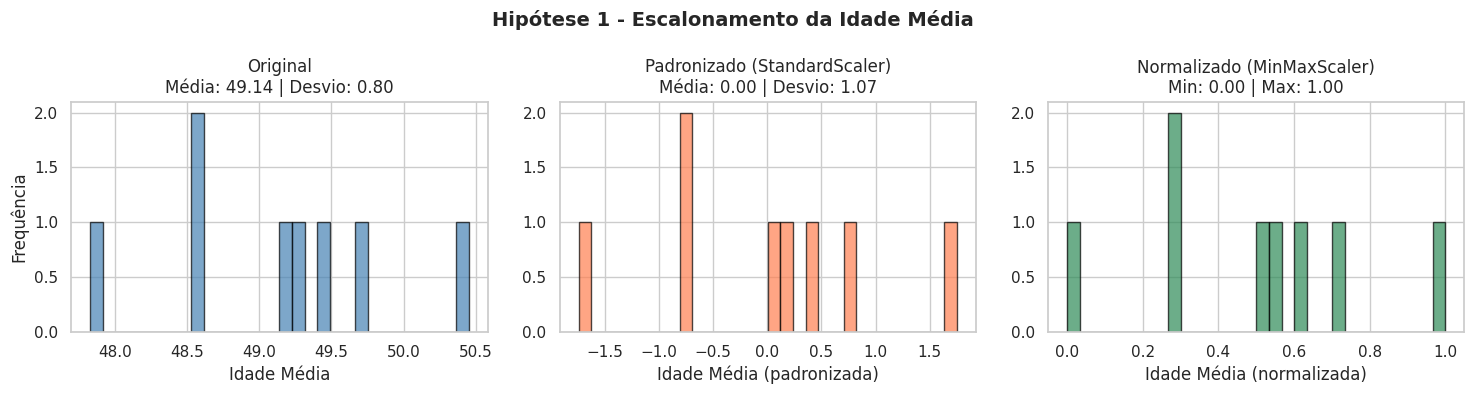

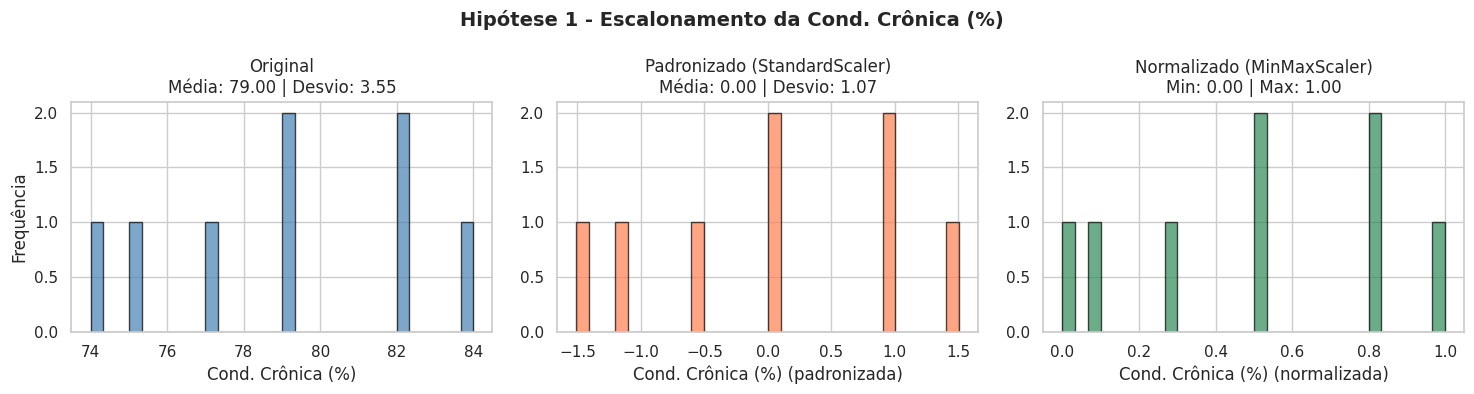

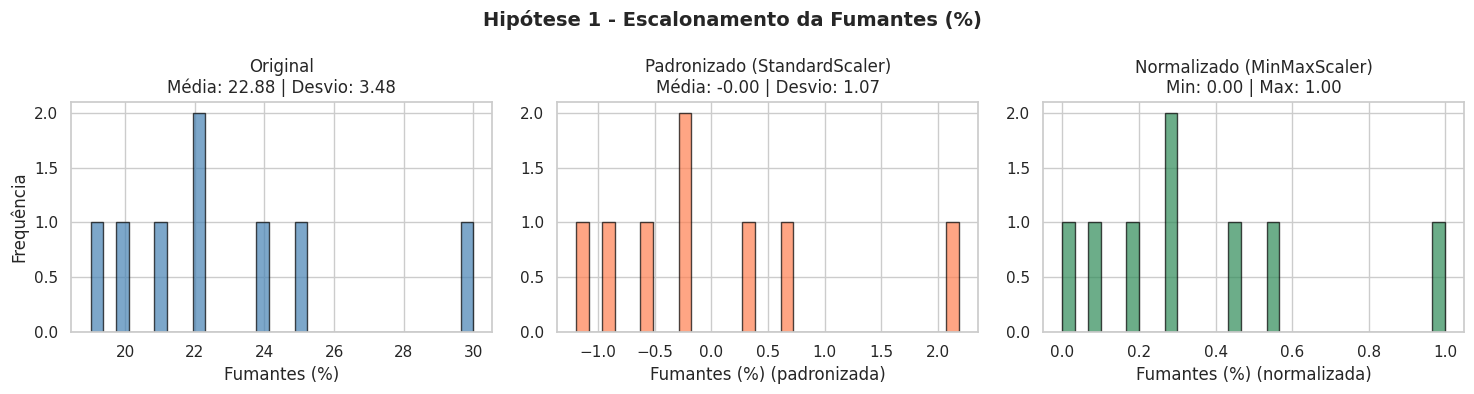

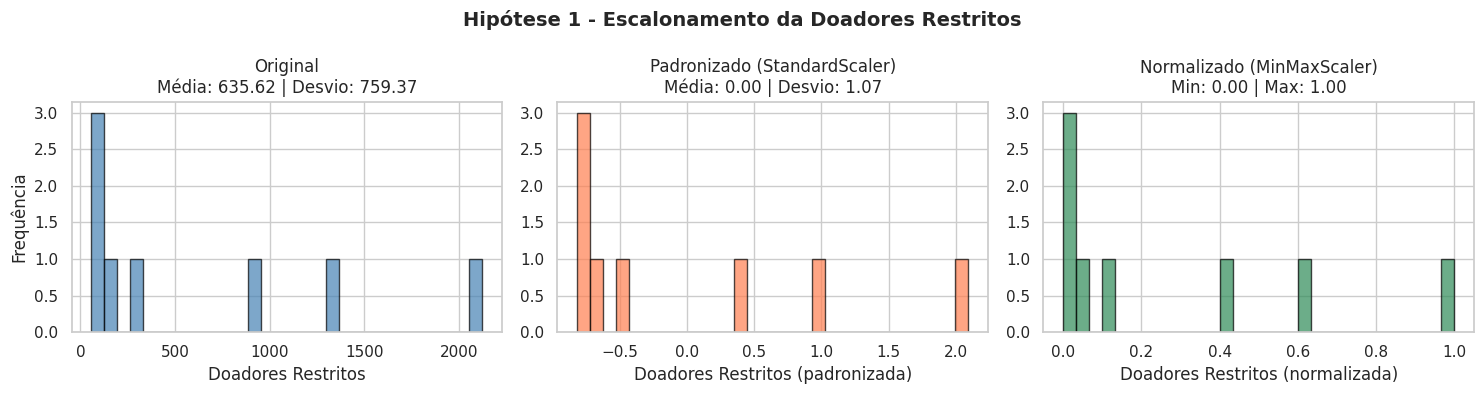

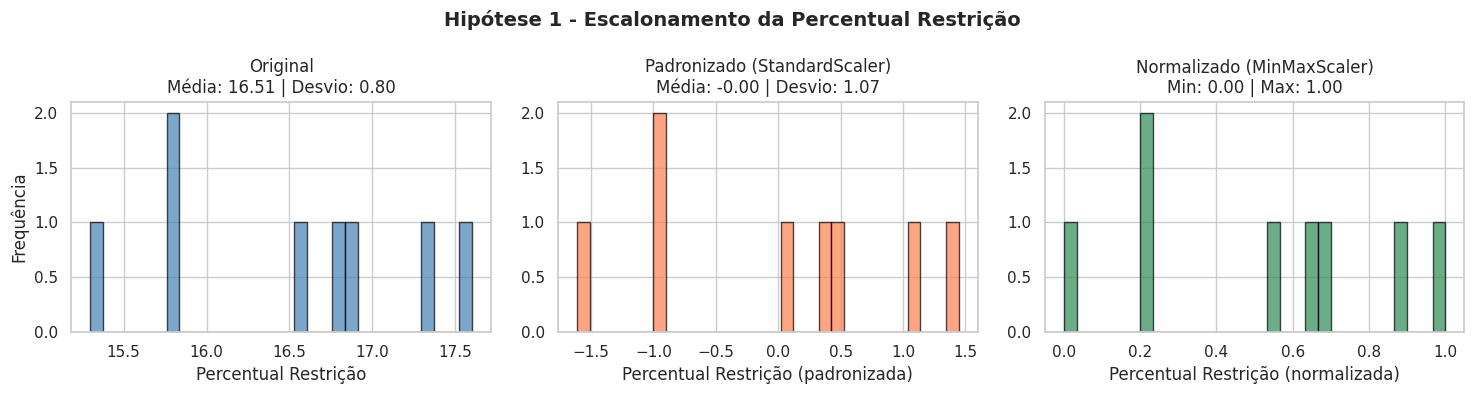

In [ ]:
if variaveis_existentes_agregadas_restricao:
    scaler_std = StandardScaler()
    df_padronizado = restricoes_por_tipo.copy()
    df_padronizado[variaveis_existentes_agregadas_restricao] = scaler_std.fit_transform(restricoes_por_tipo[variaveis_existentes_agregadas_restricao])
    scaler_minmax = MinMaxScaler()
    df_normalizado = restricoes_por_tipo.copy()
    df_normalizado[variaveis_existentes_agregadas_restricao] = scaler_minmax.fit_transform(restricoes_por_tipo[variaveis_existentes_agregadas_restricao])
    for coluna in variaveis_existentes_agregadas_restricao:
        nome_pt = traducao_variaveis.get(coluna, coluna)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f'Hipótese 1 - Escalonamento da {nome_pt}', fontsize=14, fontweight='bold')
        axes[0].hist(restricoes_por_tipo[coluna], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        axes[0].set_title(f'Original\nMédia: {restricoes_por_tipo[coluna].mean():.2f} | Desvio: {restricoes_por_tipo[coluna].std():.2f}')
        axes[0].set_xlabel(nome_pt)
        axes[0].set_ylabel('Frequência')
        axes[1].hist(df_padronizado[coluna], bins=30, color='coral', edgecolor='black', alpha=0.7)
        axes[1].set_title(f'Padronizado (StandardScaler)\nMédia: {df_padronizado[coluna].mean():.2f} | Desvio: {df_padronizado[coluna].std():.2f}')
        axes[1].set_xlabel(nome_pt + ' (padronizada)')
        axes[2].hist(df_normalizado[coluna], bins=30, color='seagreen', edgecolor='black', alpha=0.7)
        axes[2].set_title(f'Normalizado (MinMaxScaler)\nMin: {df_normalizado[coluna].min():.2f} | Max: {df_normalizado[coluna].max():.2f}')
        axes[2].set_xlabel(nome_pt + ' (normalizada)')
        plt.tight_layout()
        plt.show()

####Tratamento de outliers

In [ ]:
outliers_info = {}
for var in variaveis_existentes_agregadas_restricao:
    var_trad = traducao_variaveis.get(var, var)
    outliers, li, ls = detectar_outliers_iqr(restricoes_por_tipo, var)
    outliers_info[var] = {
        'nome_traduzido': var_trad,
        'quantidade': len(outliers),
        'percentual': len(outliers)/len(restricoes_por_tipo)*100,
        'limite_inferior': li,
        'limite_superior': ls
    }

n_linhas = 2
n_colunas = 3
fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(15, 10))
fig.suptitle('Hipótese 1 - Identificação de Outliers por Variável', fontsize=14, fontweight='bold')
for i, var in enumerate(variaveis_existentes_agregadas_restricao):
    if i >= n_linhas * n_colunas:
        break
    ax = axes[i // n_colunas, i % n_colunas]
    var_trad = traducao_variaveis.get(var, var)
    boxplot = ax.boxplot(restricoes_por_tipo[var].dropna(), patch_artist=True)
    boxplot['boxes'][0].set_facecolor('steelblue')
    boxplot['boxes'][0].set_alpha(0.7)
    outliers, _, _ = detectar_outliers_iqr(restricoes_por_tipo, var)
    if len(outliers) > 0:
        ax.scatter(np.ones(len(outliers)) * 1, outliers[var], color='red', s=30, alpha=0.6, label='Outliers')
    ax.set_title(f'{var_trad}\n({len(outliers)} outliers - {len(outliers)/len(restricoes_por_tipo)*100:.1f}%)')
    ax.set_ylabel('Valor')
    ax.grid(axis='y', alpha=0.3)
    if len(outliers) > 0:
        ax.legend(loc='upper right', fontsize=8)
for i in range(len(variaveis_existentes_agregadas_restricao), n_linhas * n_colunas):
    fig.delaxes(axes[i // n_colunas, i % n_colunas])
plt.tight_layout()
plt.show()
dataset_sem_outliers = restricoes_por_tipo.copy()
dataset_winsorizado = restricoes_por_tipo.copy()
dataset_mediana = restricoes_por_tipo.copy()
for var in variaveis_existentes_agregadas_restricao:
    outliers, li, ls = detectar_outliers_iqr(restricoes_por_tipo, var)
    if len(outliers) > 0:
        dataset_sem_outliers = dataset_sem_outliers[~dataset_sem_outliers.index.isin(outliers.index)]
        dataset_winsorizado[var] = dataset_winsorizado[var].clip(lower=li, upper=ls)
        mediana = restricoes_por_tipo[var].median()
        dataset_mediana.loc[outliers.index, var] = mediana

####Seleção de features (variáveis importantes)

In [ ]:
warnings.filterwarnings('ignore')

target = 'eligible_to_donate'
if len(features_existentes_restricao) > 0:
    X = dataset_com_restricao[features_existentes_restricao].copy()
    y = dataset_com_restricao[target].copy()
    if X.isnull().sum().sum() > 0:
        X = X.fillna(X.median())
    variancias = X.var()
    features_validas = variancias[variancias > 0].index.tolist()
    if len(features_validas) < len(features_existentes_restricao):
        X = X[features_validas]
        features_existentes_restricao = features_validas
    if len(features_existentes_restricao) > 0:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X = pd.DataFrame(X_scaled, columns=features_existentes_restricao)
        correlacoes = pd.Series({})
        for f in features_existentes_restricao:
            if len(X[f].unique()) > 1:
                try:
                    correlacoes[f] = abs(np.corrcoef(X[f], y)[0,1])
                except:
                    pass
        correlacoes = correlacoes.sort_values(ascending=False)
        k_features = min(5, len(features_existentes_restricao))
        selector = SelectKBest(score_func=f_classif, k=k_features)
        X_selected = selector.fit_transform(X, y)
        scores = selector.scores_
        mi_scores = mutual_info_classif(X, y, random_state=42)
        mi_df = pd.DataFrame({
            'Feature': features_existentes_restricao,
            'MI_Score': mi_scores
        }).sort_values('MI_Score', ascending=False)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        if len(np.unique(y_train)) > 1:
            rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
            rf.fit(X_train, y_train)
            importancias = pd.DataFrame({
                'Feature': features_existentes_restricao,
                'Importancia': rf.feature_importances_
            }).sort_values('Importancia', ascending=False)
            pode_treinar_rf = True
        else:
            importancias = pd.DataFrame({'Feature': [], 'Importancia': []})
            pode_treinar_rf = False
        fig, axes = plt.subplots(3, 1, figsize=(14, 18))
        fig.suptitle('Seleção de Features - Importância das Variáveis\n(Hipótese 1: Doadores com Restrição)',
                     fontsize=14, fontweight='bold', y=0.98)

        top_corr = correlacoes.head(8)
        if not top_corr.empty and top_corr.max() > 0:
            nomes_traduzidos_corr = [traducao_variaveis.get(f, f) for f in top_corr.index]
            max_corr = top_corr.max()
            axes[0].set_ylim(0, max_corr * 1.25)
            cores_corr = ['#e15759' if c < 0.1 else '#4e79a7' for c in top_corr.values]
            bars1 = axes[0].bar(range(len(top_corr)), top_corr.values, color=cores_corr, edgecolor='black', width=0.6)
            axes[0].set_xticks(range(len(top_corr)))
            axes[0].set_xticklabels(nomes_traduzidos_corr, rotation=45, ha='right', fontsize=11)
            axes[0].set_ylabel('Correlação Absoluta', fontsize=12, fontweight='semibold')
            axes[0].set_title('Correlação com a Elegibilidade para Doar', fontsize=13, fontweight='bold', pad=15)
            axes[0].grid(axis='y', alpha=0.3, linestyle='--')
            for i, (bar, val) in enumerate(zip(bars1, top_corr.values)):
                axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max_corr * 0.02),
                             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        else:
            axes[0].text(0.5, 0.5, 'Dados insuficientes para calcular correlações',
                         ha='center', va='center', transform=axes[0].transAxes)

        top_mi = mi_df.head(8)
        if not top_mi.empty and top_mi['MI_Score'].max() > 0:
            nomes_traduzidos_mi = [traducao_variaveis.get(f, f) for f in top_mi['Feature']]
            max_mi = top_mi['MI_Score'].max()
            axes[1].set_ylim(0, max_mi * 1.25)
            bars2 = axes[1].bar(range(len(top_mi)), top_mi['MI_Score'], color='#76b7b2', edgecolor='black', width=0.6)
            axes[1].set_xticks(range(len(top_mi)))
            axes[1].set_xticklabels(nomes_traduzidos_mi, rotation=45, ha='right', fontsize=11)
            axes[1].set_ylabel('Informação Mútua', fontsize=12, fontweight='semibold')
            axes[1].set_title('Informação Mútua com o Target', fontsize=13, fontweight='bold', pad=15)
            axes[1].grid(axis='y', alpha=0.3, linestyle='--')
            for i, (bar, val) in enumerate(zip(bars2, top_mi['MI_Score'])):
                axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max_mi * 0.02),
                             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        else:
            axes[1].text(0.5, 0.5, 'Dados insuficientes para calcular Informação Mútua',
                         ha='center', va='center', transform=axes[1].transAxes)

        if pode_treinar_rf and not importancias.empty and importancias['Importancia'].max() > 0:
            top_rf = importancias.head(8)
            nomes_traduzidos_rf = [traducao_variaveis.get(f, f) for f in top_rf['Feature']]
            max_rf = top_rf['Importancia'].max()
            axes[2].set_ylim(0, max_rf * 1.25)
            bars3 = axes[2].bar(range(len(top_rf)), top_rf['Importancia'], color='#e15759', edgecolor='black', width=0.6)
            axes[2].set_xticks(range(len(top_rf)))
            axes[2].set_xticklabels(nomes_traduzidos_rf, rotation=45, ha='right', fontsize=11)
            axes[2].set_ylabel('Importância', fontsize=12, fontweight='semibold')
            axes[2].set_title('Random Forest - Importância das Features', fontsize=13, fontweight='bold', pad=15)
            axes[2].grid(axis='y', alpha=0.3, linestyle='--')
            for i, (bar, val) in enumerate(zip(bars3, top_rf['Importancia'])):
                axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max_rf * 0.02),
                             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        else:
            axes[2].text(0.5, 0.5, 'Dados insuficientes para calcular importância das features',
                         ha='center', va='center', transform=axes[2].transAxes)
        plt.subplots_adjust(hspace=0.35, top=0.92)
        plt.tight_layout()
        plt.show()

        if len(features_existentes_restricao) > 1:
            corr_matrix = X[features_existentes_restricao].corr()
            nomes_traduzidos = [traducao_variaveis.get(f, f) for f in corr_matrix.index]
            corr_matrix_traduzida = corr_matrix.copy()
            corr_matrix_traduzida.index = nomes_traduzidos
            corr_matrix_traduzida.columns = nomes_traduzidos
            fig, ax = plt.subplots(figsize=(12, 10))
            mask = np.triu(np.ones_like(corr_matrix_traduzida, dtype=bool))
            sns.heatmap(corr_matrix_traduzida, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                        center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
            ax.set_title('Matriz de Correlação entre Features\n(Valores próximos a 1 indicam alta correlação)',
                         fontsize=14, fontweight='bold')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()

####Redução de dimensionalidade

In [ ]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Análise de Doadores com Restrição por Tipo Sanguíneo',
             fontsize=16, fontweight='bold')
top_tipos = restricoes_por_tipo.head(8).reset_index()
top_tipos = top_tipos.rename(columns={'index': 'blood_type'})
top_tipos['blood_type'] = pd.Categorical(top_tipos['blood_type'],
                                          categories=dataset_tipo_sanguineo,
                                          ordered=True)
top_tipos = top_tipos.sort_values('blood_type')
if 'Doadores_com_restricao' in top_tipos.columns:
    ax1 = axes[0,0]
    bars = sns.barplot(data=top_tipos, x='blood_type', y='Doadores_com_restricao',
                       color='#e15759', alpha=0.8, ax=ax1,
                       edgecolor='black', linewidth=1.5, legend=False,
                       order=dataset_tipo_sanguineo,  palette='Set3')
    ax1.set_xlabel('Tipo Sanguíneo', fontsize=12, fontweight='semibold', labelpad=10)
    ax1.set_ylabel('Número de Doadores com Restrição', fontsize=12, fontweight='semibold', labelpad=10)
    ax1.set_title('Quantidade Absoluta de Doadores Restritos', fontsize=13, fontweight='bold', pad=20)
    ax1.tick_params(axis='x', rotation=45, labelsize=11)
    max_val = top_tipos['Doadores_com_restricao'].max()
    ax1.set_ylim(0, max_val * 1.15)
    for i, (bar, val) in enumerate(zip(ax1.patches, top_tipos['Doadores_com_restricao'])):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max_val * 0.02),
                 f'{int(val):,}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold', color='black')
    ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
else:
    axes[0,0].text(0.5, 0.5, 'Dados não disponíveis', ha='center', va='center', transform=axes[0,0].transAxes)

if 'Pct_geral' in top_tipos.columns:
    ax2 = axes[0,1]
    bars2 = sns.barplot(data=top_tipos, x='blood_type', y='Pct_geral',
                        color='#4e79a7', alpha=0.8, ax=ax2,  palette='Set3',
                        edgecolor='black', linewidth=1.5, legend=False,
                        order=dataset_tipo_sanguineo)
    ax2.set_xlabel('Tipo Sanguíneo', fontsize=12, fontweight='semibold')
    ax2.set_ylabel('Percentual de Restrição (%)', fontsize=12, fontweight='semibold')
    ax2.set_title('Percentual de Doadores Restritos por Tipo', fontsize=13, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45, labelsize=11)
    max_val_pct = top_tipos['Pct_geral'].max()
    ax2.set_ylim(0, max_val_pct * 1.15)
    for i, (bar, val) in enumerate(zip(ax2.patches, top_tipos['Pct_geral'])):
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max_val_pct * 0.02),
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=11, fontweight='bold', color='black')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
else:
    axes[0,1].text(0.5, 0.5, 'Dados não disponíveis', ha='center', va='center', transform=axes[0,1].transAxes)

if 'Idade_media' in top_tipos.columns and 'idade_ic_inferior' in top_tipos.columns:
    idade_data = pd.DataFrame({
        'Tipo_Sanguíneo': top_tipos['blood_type'],
        'Idade_Média': top_tipos['Idade_media'],
        'IC_Inferior': top_tipos['idade_ic_inferior'] if 'idade_ic_inferior' in top_tipos.columns else 0,
        'IC_Superior': top_tipos['idade_ic_superior'] if 'idade_ic_superior' in top_tipos.columns else 0
    })
    ax3 = axes[1,0]
    idade_data_sorted = idade_data.sort_values('Tipo_Sanguíneo')
    pointplot = sns.pointplot(data=idade_data_sorted, y='Idade_Média', x='Tipo_Sanguíneo',
                              color='#2c3e50', markersize=12, capsize=0.2, ax=ax3,
                              alpha=0.9, linestyle='-', linewidth=2, errwidth=2,
                              order=dataset_tipo_sanguineo, palette='Set3')
    for line in ax3.lines:
        line.set_marker('o')
        line.set_markersize(10)
        line.set_markeredgewidth(1.5)
        line.set_markeredgecolor('black')
    ax3.set_ylabel('Idade Média (anos)', fontsize=12, fontweight='semibold')
    ax3.set_xlabel('Tipo Sanguíneo', fontsize=12, fontweight='semibold')
    ax3.set_title('Idade Média por Tipo Sanguíneo (IC 95%)', fontsize=13, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3, linestyle='--')
    ax3.tick_params(axis='x', rotation=45, labelsize=11)
else:
    axes[1,0].text(0.5, 0.5, 'Dados não disponíveis', ha='center', va='center', transform=axes[1,0].transAxes)

if 'Cond_cronica_media' in top_tipos.columns and 'Fumantes_media' in top_tipos.columns:
    ax4 = axes[1,1]
    top_tipos_melted = top_tipos.melt(id_vars=['blood_type'],
                                       value_vars=['Cond_cronica_media', 'Fumantes_media'],
                                       var_name='Condicao', value_name='Percentual')
    top_tipos_melted['Condicao'] = top_tipos_melted['Condicao'].map({
        'Cond_cronica_media': 'Condição Crônica',
        'Fumantes_media': 'Fumantes'
    })
    top_tipos_melted['blood_type'] = pd.Categorical(top_tipos_melted['blood_type'],
                                                     categories=dataset_tipo_sanguineo,
                                                     ordered=True)
    top_tipos_melted = top_tipos_melted.sort_values('blood_type')
    bars3 = sns.barplot(data=top_tipos_melted, x='blood_type', y='Percentual',
                        hue='Condicao', alpha=0.8, ax=ax4,
                        edgecolor='black', linewidth=1.5,
                        order=dataset_tipo_sanguineo, palette='Set3')
    ax4.set_xlabel('Tipo Sanguíneo', fontsize=12, fontweight='semibold')
    ax4.set_ylabel('Percentual (%)', fontsize=12, fontweight='semibold')
    ax4.set_title('Prevalência de Condições Crônicas e Tabagismo', fontsize=13, fontweight='bold')
    ax4.tick_params(axis='x', rotation=45, labelsize=11)
    ax4.legend(title='Condição', loc='lower center', bbox_to_anchor=(0.5, -0.3),
               fontsize=10, title_fontsize=11, framealpha=0.9, edgecolor='black', ncol=2)
    for container in ax4.containers:
        ax4.bar_label(container, fmt='%.1f%%', fontsize=9, fontweight='bold',
                     padding=3, rotation=45)
    ax4.grid(axis='y', alpha=0.3, linestyle='--')
    ax4.set_ylim(0, max(top_tipos_melted['Percentual']) * 1.15)
    plt.subplots_adjust(bottom=0.15)
else:
    axes[1,1].text(0.5, 0.5, 'Dados não disponíveis', ha='center', va='center', transform=axes[1,1].transAxes)
plt.tight_layout()
plt.show()

if len(features_existentes_restricao ) >= 2:
    X = dataset_com_restricao[features_existentes_restricao ].copy()
    y = dataset_com_restricao['blood_type'].copy()
    if X.isnull().sum().sum() > 0:
        X = X.fillna(X.median())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    df_pca = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1],
        'Blood_Type': y
    })
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=['PC1', 'PC2'],
        index=features_existentes_restricao
    )
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Redução de Dimensionalidade - Doadores com Restrição',
                 fontsize=14, fontweight='bold')
    sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Blood_Type',
                    alpha=0.5, s=30, palette='Set3', ax=axes[0],
                    edgecolor='black', linewidth=0.5)
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância explicada)', fontsize=11)
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância explicada)', fontsize=11)
    axes[0].set_title('PCA - Doadores Restritos por Tipo Sanguíneo', fontsize=12, fontweight='bold')
    axes[0].legend(loc='upper right', fontsize=8, ncol=2)
    axes[0].grid(alpha=0.3)
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)
    var_df = pd.DataFrame({
        'Componente': [f'PC{i+1}' for i in range(len(explained_variance_ratio))],
        'Variância_Individual': explained_variance_ratio,
        'Variância_Acumulada': cumulative_variance
    })
    sns.barplot(data=var_df, x='Componente', y='Variância_Individual',
                alpha=0.9, ax=axes[1], palette='Set3')
    axes[1].plot(range(len(cumulative_variance)), cumulative_variance,
            'o-', label='Variância Explicada Acumulada', color='#e15759',
            linewidth=2.5, markersize=10, markerfacecolor='white',
            markeredgewidth=2, markeredgecolor='#e15759')
    axes[1].set_xlabel('Componentes Principais', fontsize=11)
    axes[1].set_ylabel('Proporção de Variância Explicada', fontsize=11)
    axes[1].set_title('Variância Explicada por Componente', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    max_samples = 5000
    if len(X_scaled) > max_samples:
        indices = np.random.choice(len(X_scaled), max_samples, replace=False)
        X_sample = X_scaled[indices]
        y_sample = y.iloc[indices]
    else:
        X_sample = X_scaled
        y_sample = y
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, learning_rate=200)
    X_tsne = tsne.fit_transform(X_sample)
    df_tsne = pd.DataFrame({
        'tSNE1': X_tsne[:, 0],
        'tSNE2': X_tsne[:, 1],
        'Blood_Type': y_sample
    })
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.scatterplot(data=df_tsne, x='tSNE1', y='tSNE2', hue='Blood_Type',
                    alpha=0.5, s=30, palette='Set3', ax=ax,
                    edgecolor='black', linewidth=0.5)
    ax.set_xlabel('t-SNE 1', fontsize=12)
    ax.set_ylabel('t-SNE 2', fontsize=12)
    ax.set_title('t-SNE - Doadores com Restrição por Tipo Sanguíneo', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if len(features_existentes_restricao) >= 2 and len(X_scaled) > 0:
    inertias = []
    silhouette_scores = []
    n_unique_types = len(np.unique(y))
    K_range = range(2, min(11, n_unique_types + 5))
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
        if k >= 2:
            score = silhouette_score(X_scaled, kmeans.labels_)
            silhouette_scores.append(score)
    if len(silhouette_scores) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Validação da Clusterização', fontsize=14, fontweight='bold')
        elbow_df = pd.DataFrame({'k': list(K_range), 'inertia': inertias})
        sns.lineplot(data=elbow_df, x='k', y='inertia', marker='o',
                     color='#4e79a7', linewidth=2, markersize=8, ax=axes[0])
        axes[0].set_xlabel('Número de Clusters (k)', fontsize=11)
        axes[0].set_ylabel('Inércia', fontsize=11)
        axes[0].set_title('Método do Cotovelo', fontsize=12, fontweight='bold')
        axes[0].grid(alpha=0.3)
        sil_df = pd.DataFrame({'k': list(K_range[:len(silhouette_scores)]), 'silhouette': silhouette_scores})
        sns.lineplot(data=sil_df, x='k', y='silhouette', marker='o', palette='Set3',
                     color='#e15759', linewidth=2, markersize=8, ax=axes[1])
        axes[1].set_xlabel('Número de Clusters (k)', fontsize=11)
        axes[1].set_ylabel('Silhouette Score', fontsize=11)
        axes[1].set_title('Coeficiente de Silhouette', fontsize=12, fontweight='bold')
        axes[1].grid(alpha=0.3)
        best_idx = np.argmax(silhouette_scores)
        best_k = K_range[best_idx] if best_idx < len(K_range) else K_range[0]
        max_silhouette = max(silhouette_scores)
        axes[1].axhline(y=max_silhouette, color='green', linestyle='--', alpha=0.5, linewidth=1.5)
        axes[1].annotate(f'Melhor k={best_k}\n(Silhouette={max_silhouette:.3f})',
                        xy=(best_k, max_silhouette),
                        xytext=(best_k + 0.5, max_silhouette - 0.05),
                        fontsize=9,
                        arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
        plt.tight_layout()
        plt.show()

        kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
        clusters = kmeans_final.fit_predict(X_scaled)
        df_clusters = pd.DataFrame({
            'PC1': X_pca[:, 0],
            'PC2': X_pca[:, 1],
            'Cluster': clusters,
            'Blood_Type': y
        })
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle(f'Análise de Clusters (k={best_k})', fontsize=14, fontweight='bold')
        sns.scatterplot(data=df_clusters, x='PC1', y='PC2', hue='Cluster',
                       palette='Set2', alpha=0.6, s=20, ax=axes[0],
                       edgecolor='black', linewidth=0.5)
        axes[0].set_title('Visualização dos Clusters Encontrados', fontsize=12, fontweight='bold')
        axes[0].legend(title='Cluster')
        sns.scatterplot(data=df_clusters, x='PC1', y='PC2', hue='Blood_Type',
                        palette='Set3', alpha=0.6, s=20, ax=axes[1],
                        edgecolor='black', linewidth=0.5)
        axes[1].set_title('Distribuição Real dos Tipos Sanguíneos', fontsize=12, fontweight='bold')
        axes[1].legend(title='Tipo Sanguíneo', ncol=2)
        plt.tight_layout()
        plt.show()

        cluster_distribution = pd.crosstab(y, clusters)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cluster_distribution, annot=True, fmt='d', cmap='YlOrRd',
                   cbar_kws={'label': 'Número de Doadores'})
        plt.title('Distribuição dos Tipos Sanguíneos por Cluster', fontsize=13, fontweight='bold')
        plt.xlabel('Cluster', fontsize=11)
        plt.ylabel('Tipo Sanguíneo', fontsize=11)
        plt.tight_layout()
        plt.show()

if 'age' in dataset_com_restricao.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    df_age = dataset_com_restricao[['blood_type', 'age']].copy()
    df_age = df_age[df_age['blood_type'].isin(dataset_tipo_sanguineo)]
    sns.boxplot(data=df_age, x='blood_type', y='age', palette='Set3', ax=ax,
                order=dataset_tipo_sanguineo)
    for patch in ax.artists:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, 0.6))
    ax.set_xlabel('Tipo Sanguíneo', fontsize=11)
    ax.set_ylabel('Idade (anos)', fontsize=11)
    ax.set_title('Distribuição da Idade por Tipo Sanguíneo - Doadores com Restrição',
                  fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

###Conclusão final da hipótese 1
(gráfico 1) - média
A média de doadores com restrição é para O+ que possuí a maior quantidade de doadores, assim como a menor é AB-, que é o tipo sanguineo com a menor quantidade de pessoas.

(gráfico 2) - média
Essa é a idade média dos doadores com restrição por tipo sanguineo, sendo o maior valor AB+, ou seja, em AB+ os doadores possuem maiores restrições quando estão mais velhos.

(gráfico 3) - média
Essas são as condições crônicas dos doadores por tipo sanguineo, onde o maior índice de condição crônica é para o tipo de sangue B-.

(gráfico 4) - média
Doadores mais fumantes por tipo sanguineo, onde é AB- possuí maior proporção de doadores fumantes.



Conclusão - desvio padrão
O tipo sanguíneo O+ apresenta o maior número absoluto de doadores com restrição, seguido de perto pelo A+.

Os tipos B+ e AB+ têm significativamente menos impedimentos, com AB+ registrando o menor valor entre os quatro tipos analisados. Essa distribuição sugere que a prevalência de restrições acompanha a frequência populacional dos tipos sanguíneos, com os grupos mais comuns (O+ e A+) concentrando a maior parte dos casos.

Conclusão - desvio padrão
Os doadores com restrição do tipo B+ apresentam a maior idade média (50,5 anos), enquanto os doadores do tipo A- são os mais jovens (47,8 anos).

A diferença entre os extremos é de apenas 2,7 anos, indicando que, apesar de existirem variações entre os tipos sanguíneos, a idade média dos doadores com restrição é relativamente homogênea, concentrando-se na faixa de 48 a 51 anos.

Conclusão - desvio padrão
Os doadores com restrição do tipo B- apresentam a maior prevalência de condições crônicas (84%), enquanto os doadores do tipo A- têm a menor prevalência (74%).

A diferença de 10 pontos percentuais entre os extremos indica que o tipo sanguíneo pode estar associado a diferentes perfis de saúde entre os doadores com restrição. Os tipos do Grupo B (especialmente B-) merecem atenção especial por apresentarem as maiores taxas de comorbidades.


Conclusão - desvio padrão
O tipo sanguíneo AB- apresenta a maior prevalência de tabagismo entre doadores com restrição (30%), enquanto o tipo B- tem a menor (19%).

A diferença de 11 pontos percentuais entre os extremos indica que o tipo sanguíneo pode estar associado a diferentes comportamentos de tabagismo entre os doadores com restrição. O destaque para AB- merece atenção especial por sua prevalência significativamente mais alta.


Conclusão - histograma
Os três grupos analisados (O+, A+ e Outros) apresentam distribuições etárias muito semelhantes, com pico de concentração entre 45-50 anos e faixa etária de 20 a 70 anos.

O grupo "Outros" (que inclui B+, AB+, A-, O-, B-, AB-) apresenta densidades ligeiramente mais altas em todas as faixas etárias, sugerindo que, embora a forma da distribuição seja similar, há uma concentração um pouco maior de doadores neste grupo.

A participação de jovens (20-30 anos) é consistentemente baixa em todos os grupos, indicando um desafio comum para a captação de novos doadores jovens que venham a ter restrições no futuro.


Conclusão - boxplot
1. A idade dos doadores com restrição varia consideravelmente entre os tipos sanguíneos, com diferença de até 12 anos entre o grupo mais velho (A+) e o mais jovem (B-).

2. A presença de outliers em A+ (jovem), B+ e A- (idosos) indica que esses grupos possuem maior variação etária, podendo conter subpopulações distintas.

3. Apenas A+ e O+ apresentam mediana acima da média global (49,2 anos), enquanto os demais tipos estão abaixo, sugerindo que os tipos sanguíneos mais comuns (A+, O+) concentram os doadores mais velhos com restrição.


Conclusão - matriz de correlação
A idade é o principal fator associado ao comportamento futuro dos doadores com restrição. Doadores mais velhos demonstram maior intenção de doar e maior tempo de cadastro, mas não necessariamente doam mais ou têm mais condições crônicas. A maioria das variáveis analisadas atua de forma independente, sem relações lineares expressivas.


Conclusão - codificação de variáveis categóricas
O tipo sanguíneo O+ é o que possui a maior quantidade de doadores com restrição (2.123 doadores, 62% do total), seguido por B+ (916 doadores, 26,7%) e AB+ (305 doadores, 8,9%).

Perfil dos tipos com mais restrições:

O+: Mais frequente, idade elevada (49,2 anos), alta comorbidade (79%), tabagismo moderado (25%)

B+: Segundo mais frequente, perfil similar ao O+ (48,6 anos, 79% comorbidade, 22% tabagismo)

Target Encoding = 0 para todos os tipos indica que nenhum doador com restrição é elegível para doação, independentemente do tipo sanguíneo.


Conclusão - normalização e padronização
1. Dados originais
  * A idade dos doadores com restrição segue uma distribuição aproximadamente normal.

  * A faixa etária predominante é 40-55 anos, indicando que a restrição para doação afeta mais os adultos de meia-idade

  * Há menos jovens (20-30 anos) e idosos (60-70 anos) entre os doadores com restrição


2. Sobre a Padronização (StandardScaler)
  * Mantém a forma da distribuição e a posição relativa dos dados

  * Preserva outliers (valores extremos), que podem representar casos especiais

  * Facilita comparações entre variáveis de diferentes escalas

3. Sobre a Normalização (MinMaxScaler)
  * Comprime os dados para o intervalo [0, 1] sem alterar a forma

  * Mantém a ordem dos valores (quem era maior continua maior)

  * Achata outliers (valores extremos ficam próximos de 1)


Conclusão - tratamento de outliers
A análise de outliers na Hipótese 1 revela que:

1. Variáveis críticas com alta taxa de outliers (>10%):

    * Doações na Vida (14,7%) - a mais crítica

    * Doações (últimos 12 meses) (10,5%) - também crítica

2. Variáveis com moderada taxa de outliers (5-10%):

    * Dias desde última doação (6,6%) - requer atenção

3. Variáveis com baixa taxa de outliers (<5%):

    * Anos desde a 1ª doação (2,1%) - aceitável

    * IMC (0,2%) - excelente

    * Idade (0,0%) - perfeita  


Conclusão - seleção de features
1. Correlação com a Elegibilidade para Doar

    * Todas as correlações são muito baixas (<0,02), indicando que não há uma relação linear forte entre nenhuma das variáveis e a elegibilidade para doar.


2. Informação Mútua com o Target

    * A Informação Mútua detecta relações não-lineares. As variáveis relacionadas ao comportamento de doação (doações na vida e doações recentes) apresentam os maiores valores, sugerindo que são mais relevantes para prever elegibilidade.


3. Random Forest - Importância das Features

    * O Random Forest, que captura interações complexas entre variáveis, mostra que Doações na Vida e Doações (últimos 12 meses) são as variáveis mais importantes, seguidas por Anos desde a 1ª doação e Doador Regular.


4. Matriz de Correlação entre Features
    
  * A matriz de correlação mostra que as features têm baixíssima correlação entre si (valores próximos de 0), indicando que:

    * Não há multicolinearidade significativa

    * As variáveis são independentes entre si

    * Todas podem ser utilizadas sem risco de redundância    

Conclusão - Redução de dimesionalidade
* Gráfico PCA

    * Mostra que os tipos sanguíneos se distribuem ao longo de um gradiente no espaço bidimensional, com O+ em uma extremidade e A- na outra.

    * O+ se destaca como o tipo com maior valor em PC1 (3,8), indicando que os doadores O+ com restrição têm características que os diferenciam dos demais

    * A- é o tipo mais distante do O+, com valor PC1 de 2,0, sugerindo que estes dois grupos têm perfis mais diferentes entre si

    * Os tipos sanguíneos não formam clusters bem definidos, indicando que os perfis dos doadores com restrição são relativamente semelhantes entre os diferentes tipos

    * A variância explicada de 23,5% nos dois primeiros componentes sugere que os dados têm complexidade moderada e que mais componentes seriam necessários para explicar toda a variabilidade

* Gráfico T-SNE
    * O gráfico t-SNE revela que os doadores com restrição se organizam em uma estrutura com um núcleo central de tipos comuns (O+, A+, B+, O-) e grupos periféricos de tipos mais raros (B-, AB-, AB+).

    * Os tipos O+, A+, B+ e O- formam um agrupamento central com grande sobreposição, indicando que estes tipos sanguíneos têm perfis muito semelhantes entre os doadores com restrição

    * B- se destaca como o tipo mais distinto, isolado na extremidade superior, sugerindo características únicas que o separam dos demais

    * AB- e AB+ formam um agrupamento próprio na extremidade inferior, indicando que os tipos AB têm um perfil diferenciado

    * A- apresenta maior dispersão, sugerindo maior variabilidade dentro deste grupo    

##Hipótese 2
2. Quantidade de doadores por sexo.

###Média


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')
ax.axis('tight')
tabela_data = [
    ['Total Doadores',
     f"{int(doadores_por_genero.loc['M', 'Doadores']):,}",
     f"{int(doadores_por_genero.loc['F', 'Doadores']):,}"],
    ['% do Total',
     f"{doadores_por_genero.loc['M', 'Pct_geral']:.1f}%",
     f"{doadores_por_genero.loc['F', 'Pct_geral']:.1f}%"],
    ['Idade Média',
     f"{doadores_por_genero.loc['M', 'Idade_media']:.1f} anos",
     f"{doadores_por_genero.loc['F', 'Idade_media']:.1f} anos"],
    ['% Cond. Crônica',
     f"{doadores_por_genero.loc['M', 'Cond_cronica_media']:.1f}%",
     f"{doadores_por_genero.loc['F', 'Cond_cronica_media']:.1f}%"],
    ['% Fumantes',
     f"{doadores_por_genero.loc['M', 'Fumantes_media']:.1f}%",
     f"{doadores_por_genero.loc['F', 'Fumantes_media']:.1f}%"],
    ['Qtd. Elegíveis',
     f"{int(doadores_por_genero.loc['M', 'apto_qtd']):,}",
     f"{int(doadores_por_genero.loc['F', 'apto_qtd']):,}"],
    ['% Elegíveis',
     f"{doadores_por_genero.loc['M', 'apto_porcentagem']:.1f}%",
     f"{doadores_por_genero.loc['F', 'apto_porcentagem']:.1f}%"]
]
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Indicador', 'Masculino', 'Feminino'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#457247', '#4e79a7', '#e15759'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(11)
tabela.scale(1.2, 1.8)
plt.title('Análise Comparativa por Gênero\n(Doadores, Condições e Elegibilidade)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=doadores_por_genero.reset_index(), x='sex', y='Idade_media',
                 hue='sex', palette=cores_genero_dict,
                 edgecolor='black', linewidth=1.2, alpha=0.8, legend=False)
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f} anos', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='black')
ax.set_xticklabels(['Masculino', 'Feminino'])
plt.title('Idade Média por Gênero', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Gênero', fontsize=13, fontweight='semibold', labelpad=10)
plt.ylabel('Idade (anos)', fontsize=13, fontweight='semibold', labelpad=10)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)
plt.ylim(0, doadores_por_genero['Idade_media'].max() * 1.15)
plt.tight_layout()
plt.show()

df_dados = getDataSetGeneros()
df_aptos_qtd = df_dados[df_dados['Indicador'] == 'Elegíveis Quantidade']
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=df_aptos_qtd, x='Gênero', y='Valor',
                hue='Gênero', palette=cores_genero_portugues,
                edgecolor='black', linewidth=1.2, alpha=0.8, legend=False)
max_qtd = df_aptos_qtd['Valor'].max()
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + (max_qtd * 0.02),
                f'{int(height):,}', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='black')
plt.title('Quantidade de Doadores Elegíveis (Aptos) por Gênero', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Gênero', fontsize=13, fontweight='semibold', labelpad=10)
plt.ylabel('Quantidade de Doadores Aptos', fontsize=13, fontweight='semibold', labelpad=10)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)
plt.ylim(0, max_qtd * 1.15)
plt.tight_layout()
plt.show()

df_percentuais = df_dados[~df_dados['Indicador'].str.contains('Qtd|Quantidade|Idade', case=False, na=False)]
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_percentuais, x='Indicador', y='Valor',
                  hue='Gênero', palette=cores_genero_portugues,
                  edgecolor='black', linewidth=1.2, alpha=0.8)
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='black')

plt.title('Indicadores Percentuais por Gênero', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Indicadores', fontsize=13, fontweight='semibold', labelpad=10)
plt.ylabel('Percentual (%)', fontsize=13, fontweight='semibold', labelpad=10)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)
plt.legend(title='Gênero', title_fontsize=11, fontsize=10, loc='upper left')
plt.ylim(0, df_percentuais['Valor'].max() * 1.15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


###Desvio Padrão

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
ax.axis('tight')

tabela_data = [
    ['Total Doadores',
     f"{int(doadores_por_genero.loc['M', 'Doadores']):,}",
     f"{int(doadores_por_genero.loc['F', 'Doadores']):,}"],
    ['% do Total',
     f"{doadores_por_genero.loc['M', 'Pct_geral']:.1f}%",
     f"{doadores_por_genero.loc['F', 'Pct_geral']:.1f}%"],
    ['Idade Média (anos)',
     f"{doadores_por_genero.loc['M', 'Idade_media']:.1f} ± {doadores_por_genero.loc['M', 'Idade_desvio']:.1f}",
     f"{doadores_por_genero.loc['F', 'Idade_media']:.1f} ± {doadores_por_genero.loc['F', 'Idade_desvio']:.1f}"],
    ['% Cond. Crônica',
     f"{doadores_por_genero.loc['M', 'Cond_cronica_media']:.1f} ± {doadores_por_genero.loc['M', 'Cond_cronica_desvio']:.1f}%",
     f"{doadores_por_genero.loc['F', 'Cond_cronica_media']:.1f} ± {doadores_por_genero.loc['F', 'Cond_cronica_desvio']:.1f}%"],
    ['% Fumantes',
     f"{doadores_por_genero.loc['M', 'Fumantes_media']:.1f} ± {doadores_por_genero.loc['M', 'Fumantes_desvio']:.1f}%",
     f"{doadores_por_genero.loc['F', 'Fumantes_media']:.1f} ± {doadores_por_genero.loc['F', 'Fumantes_desvio']:.1f}%"],
    ['Doações na Vida',
     f"{doadores_por_genero.loc['M', 'doacoes_vida_media']:.1f} ± {doadores_por_genero.loc['M', 'doacoes_vida_desvio']:.1f}",
     f"{doadores_por_genero.loc['F', 'doacoes_vida_media']:.1f} ± {doadores_por_genero.loc['F', 'doacoes_vida_desvio']:.1f}"],
    ['% Doadores Regulares',
     f"{doadores_por_genero.loc['M', 'doador_regular_media']:.1f} ± {doadores_por_genero.loc['M', 'doador_regulgar_desvio']:.1f}%",
     f"{doadores_por_genero.loc['F', 'doador_regular_media']:.1f} ± {doadores_por_genero.loc['F', 'doador_regulgar_desvio']:.1f}%"],
    ['Qtd. Elegíveis (Aptos)',
     f"{int(doadores_por_genero.loc['M', 'apto_qtd']):,}",
     f"{int(doadores_por_genero.loc['F', 'apto_qtd']):,}"],
    ['% Elegíveis (Aptos)',
     f"{doadores_por_genero.loc['M', 'apto_porcentagem']:.1f} ± {doadores_por_genero.loc['M', 'apto_desvio']:.1f}%",
     f"{doadores_por_genero.loc['F', 'apto_porcentagem']:.1f} ± {doadores_por_genero.loc['F', 'apto_desvio']:.1f}%"]
]
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Indicador', 'Masculino', 'Feminino'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#457247', '#4e79a7', '#e15759'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.8)
plt.title('Análise Comparativa por Gênero\n(Doadores, Condições e Elegibilidade com Desvio Padrão)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
metricas = ['Idade (anos)', 'Cond. Crônica (%)', 'Fumantes (%)',  'Elegíveis (%)']
valores_m = [
    doadores_por_genero.loc['M', 'Idade_media'],
    doadores_por_genero.loc['M', 'Cond_cronica_media'],
    doadores_por_genero.loc['M', 'Fumantes_media'],
    #doadores_por_genero.loc['M', 'doador_regular_media'], #Removido, atrapalhava o gráfico por causa do valor muito baixo
    doadores_por_genero.loc['M', 'apto_porcentagem']
]
erros_m = [
    doadores_por_genero.loc['M', 'Idade_desvio'],
    doadores_por_genero.loc['M', 'Cond_cronica_desvio'],
    doadores_por_genero.loc['M', 'Fumantes_desvio'],
    #doadores_por_genero.loc['M', 'doador_regulgar_desvio'], #Removido, atrapalhava o gráfico por causa do valor muito baixo
    doadores_por_genero.loc['M', 'apto_desvio']
]
valores_f = [
    doadores_por_genero.loc['F', 'Idade_media'],
    doadores_por_genero.loc['F', 'Cond_cronica_media'],
    doadores_por_genero.loc['F', 'Fumantes_media'],
    #doadores_por_genero.loc['F', 'doador_regular_media'], #Removido, atrapalhava o gráfico por causa do valor muito baixo
    doadores_por_genero.loc['F', 'apto_porcentagem']
]
erros_f = [
    doadores_por_genero.loc['F', 'Idade_desvio'],
    doadores_por_genero.loc['F', 'Cond_cronica_desvio'],
    doadores_por_genero.loc['F', 'Fumantes_desvio'],
    #doadores_por_genero.loc['F', 'doador_regulgar_desvio'], #Removido, atrapalhava o gráfico por causa do valor muito baixo
    doadores_por_genero.loc['F', 'apto_desvio']
]
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(metricas))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], valores_m, width, yerr=erros_m,
               label='Masculino', color='#4e79a7', alpha=0.8,
               edgecolor='black', linewidth=1.2, capsize=4, error_kw={'linewidth': 1.5, 'color': 'black'})

bars2 = ax.bar([i + width/2 for i in x], valores_f, width, yerr=erros_f,
               label='Feminino', color='#e15759', alpha=0.8,
               edgecolor='black', linewidth=1.2, capsize=4, error_kw={'linewidth': 1.5, 'color': 'black'})
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (max(valores_m + valores_f) * 0.02),
            f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (max(valores_m + valores_f) * 0.02),
            f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xlabel('Indicadores', fontsize=13, fontweight='semibold', labelpad=10)
ax.set_ylabel('Valor', fontsize=13, fontweight='semibold', labelpad=10)
ax.set_title('Comparação de Indicadores por Gênero (com Desvio Padrão)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11, rotation=45, ha='right')
ax.legend(title='Gênero', title_fontsize=11, fontsize=10, loc='lower right')
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
plt.tight_layout()
plt.show()

###Histograma

In [ ]:
dataset_histograma_masculino = dataset[dataset['sex'] == 'M']
dataset_histograma_feminino = dataset[dataset['sex'] == 'F']
bins = np.linspace(dataset['age'].min(), dataset['age'].max(), 25)
hist_masc, bin_edges = np.histogram(dataset_histograma_masculino['age'], bins=bins, density=True)
hist_fem, _ = np.histogram(dataset_histograma_feminino['age'], bins=bins, density=True)
x = (bin_edges[:-1] + bin_edges[1:]) / 2
width = (bin_edges[1] - bin_edges[0]) * 0.35
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('Distribuição Etária dos Doadores por Gênero',
             fontsize=16, fontweight='bold', y=0.98)
bars1 = ax.bar(x - width/2, hist_masc, width, alpha=0.7, color='#4e79a7',
               edgecolor='black', linewidth=1,
               label=f'Masculino (n={len(dataset_histograma_masculino):,})')
bars2 = ax.bar(x + width/2, hist_fem, width, alpha=0.7, color='#e15759',
               edgecolor='black', linewidth=1,
               label=f'Feminino (n={len(dataset_histograma_feminino):,})')
sns.kdeplot(dataset_histograma_masculino['age'], color='#4e79a7', linewidth=2.5, ax=ax, linestyle='-')
sns.kdeplot(dataset_histograma_feminino['age'], color='#e15759', linewidth=2.5, ax=ax, linestyle='-')
ax.set_xlabel('Idade (anos)', fontsize=12, fontweight='semibold')
ax.set_ylabel('Densidade', fontsize=12, fontweight='semibold')
ax.set_title('Comparação da Distribuição Etária por Gênero',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
media_m = dataset_histograma_masculino['age'].mean()
media_f = dataset_histograma_feminino['age'].mean()
mediana_m = dataset_histograma_masculino['age'].median()
mediana_f = dataset_histograma_feminino['age'].median()
ax.axvline(x=media_m, color='#4e79a7', linestyle='--', linewidth=2, alpha=0.8,
           label=f'Média Masculino: {media_m:.1f} anos')
ax.axvline(x=media_f, color='#e15759', linestyle='--', linewidth=2, alpha=0.8,
           label=f'Média Feminino: {media_f:.1f} anos')
plt.tight_layout()
plt.show()

###Boxplot

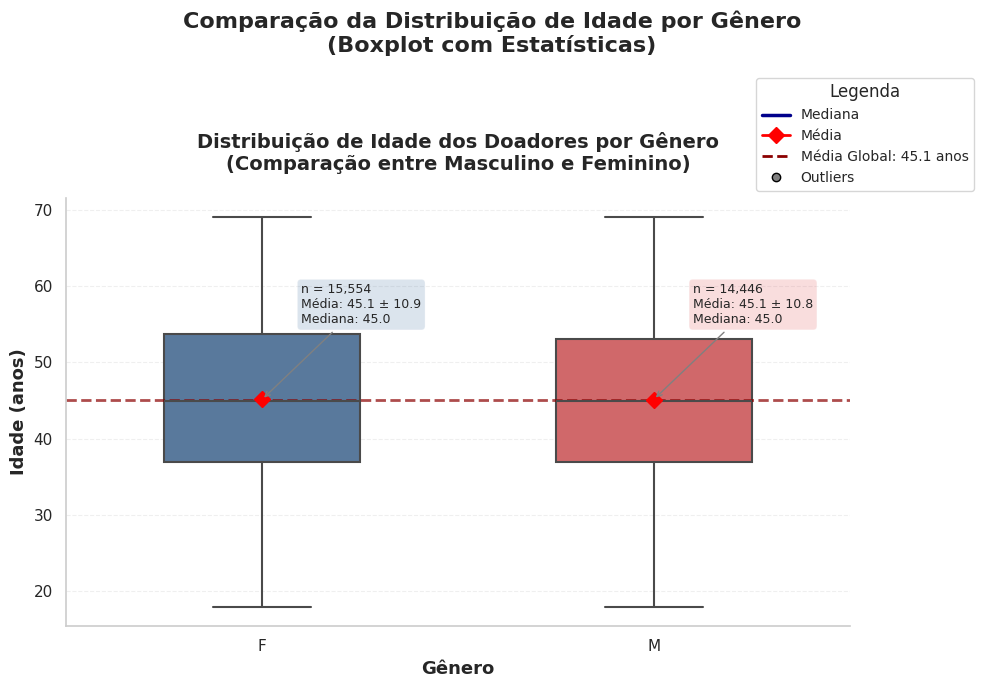

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Comparação da Distribuição de Idade por Gênero\n(Boxplot com Estatísticas)',
             fontsize=16, fontweight='bold', y=0.98)
sns.boxplot(x='sex', y='age', data=dataset, palette=cores_genero,
            linewidth=1.5, width=0.5, ax=ax, showmeans=True, hue='sex',
            meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markeredgecolor': 'red', 'markersize': 8})
media_global = dataset['age'].mean()
ax.axhline(y=media_global, color='darkred', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Média Global: {media_global:.1f} anos')
for i, genero in enumerate(['M', 'F']):
    genero_nome = 'Masculino' if genero == 'M' else 'Feminino'
    cor = '#4e79a7' if genero == 'M' else '#e15759'
    media = doadores_por_genero.loc[genero, 'Idade_media']
    desvio = doadores_por_genero.loc[genero, 'Idade_desvio']
    mediana = doadores_por_genero.loc[genero, 'Idade_mediana']
    total = int(doadores_por_genero.loc[genero, 'Doadores'])
    ax.annotate(f'n = {total:,}\nMédia: {media:.1f} ± {desvio:.1f}\nMediana: {mediana:.1f}',
                xy=(i, media), xytext=(i + 0.1, media + 10),
                ha='left', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=cor, alpha=0.2),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1))
ax.set_xlabel('Gênero', fontsize=13, fontweight='semibold')
ax.set_ylabel('Idade (anos)', fontsize=13, fontweight='semibold')
ax.set_title('Distribuição de Idade dos Doadores por Gênero\n(Comparação entre Masculino e Feminino)',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='darkblue', linewidth=2.5, label='Mediana'),
    Line2D([0], [0], color='red', linewidth=2, marker='D', markeredgecolor='red',
           markerfacecolor='red', markersize=8, label='Média'),
    Line2D([0], [0], color='darkred', linestyle='--', linewidth=2,
           label=f'Média Global: {media_global:.1f} anos'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markeredgecolor='black', markersize=6, label='Outliers')
]
ax.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(1.02, 1),
          fontsize=10, frameon=True, title='Legenda')
plt.tight_layout()
plt.show()

###Matriz de correlação

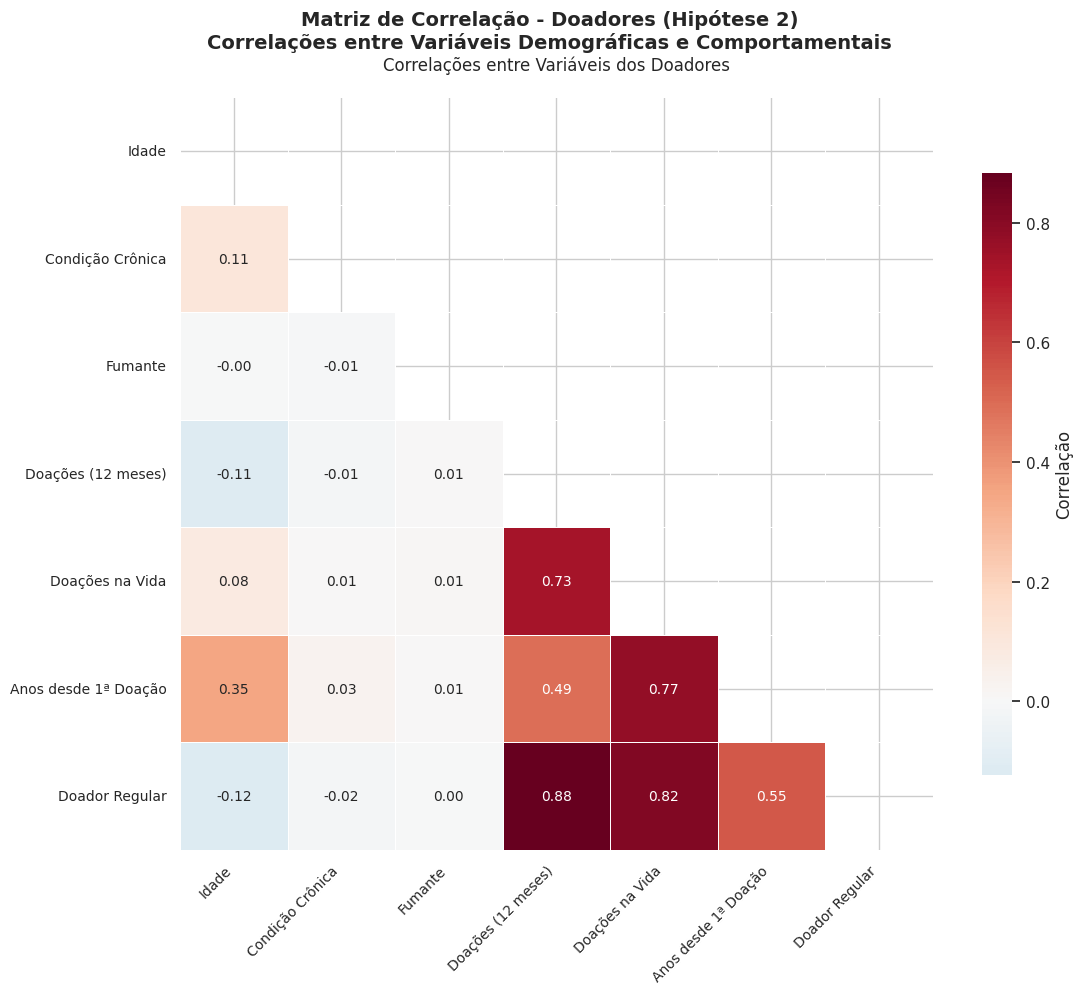

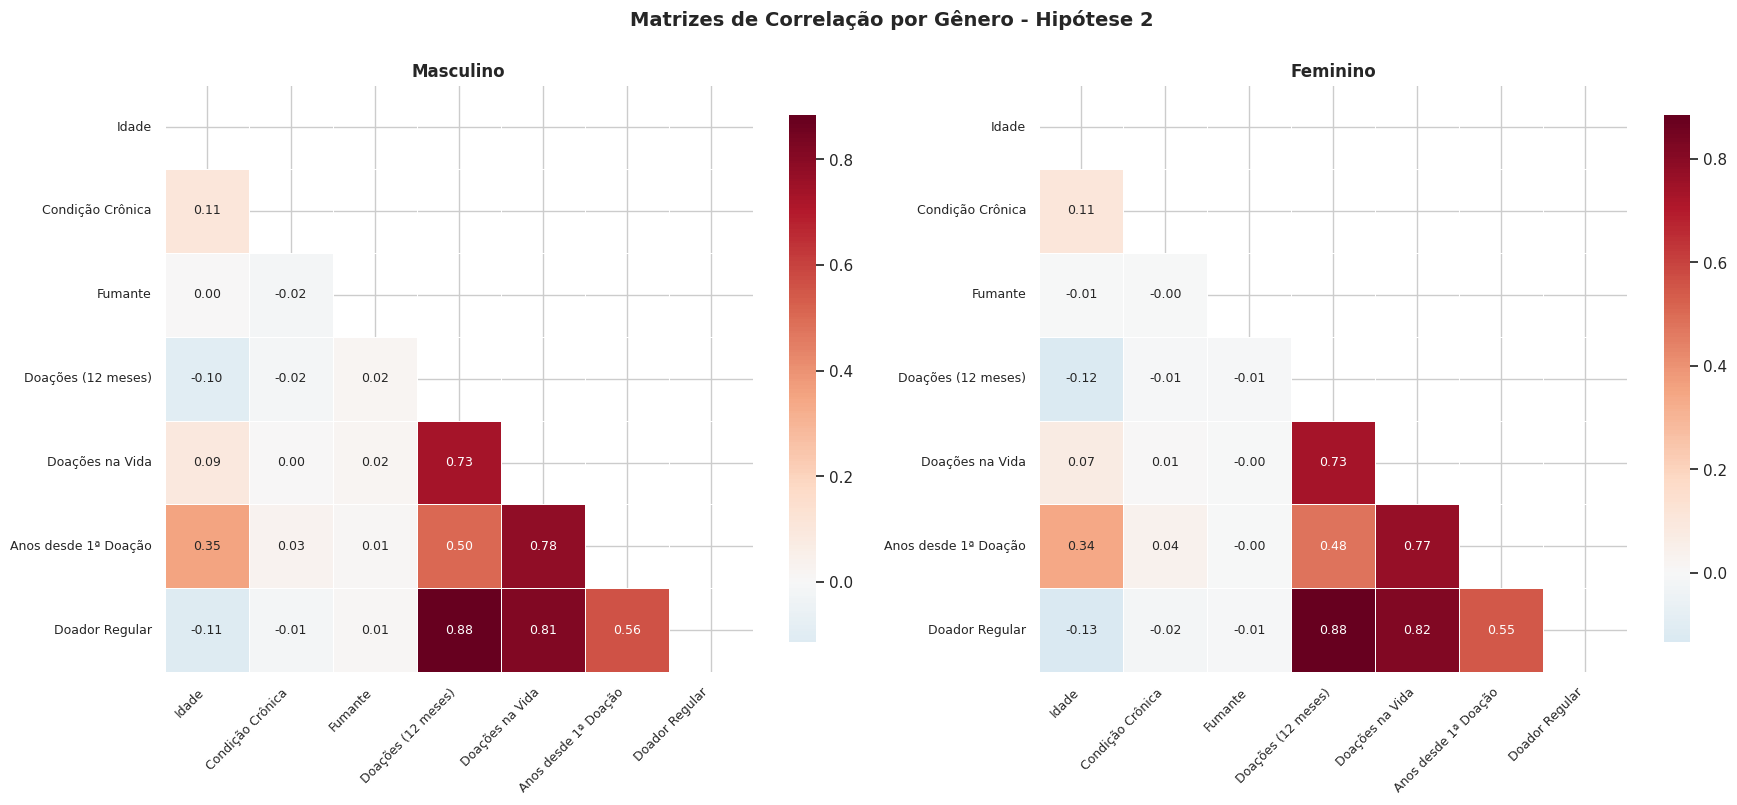

In [ ]:
corr_matrix = dataset[variaveis_existentes].corr()
nomes_traduzidos = [traducao_variaveis.get(var, var) for var in variaveis_existentes]
corr_matrix_traduzida = corr_matrix.copy()
corr_matrix_traduzida.index = nomes_traduzidos
corr_matrix_traduzida.columns = nomes_traduzidos
fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle('Matriz de Correlação - Doadores (Hipótese 2)\nCorrelações entre Variáveis Demográficas e Comportamentais',
             fontsize=14, fontweight='bold', y=0.98)
mask = np.triu(np.ones_like(corr_matrix_traduzida, dtype=bool))
sns.heatmap(corr_matrix_traduzida, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Correlação'},
            ax=ax, annot_kws={'size': 10})
ax.set_title('Correlações entre Variáveis dos Doadores', fontsize=12, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

df_masculino = dataset[dataset['sex'] == 'M']
df_feminino = dataset[dataset['sex'] == 'F']
corr_masc = df_masculino[variaveis_existentes].corr()
corr_fem = df_feminino[variaveis_existentes].corr()
corr_masc_traduzida = corr_masc.copy()
corr_masc_traduzida.index = nomes_traduzidos
corr_masc_traduzida.columns = nomes_traduzidos
corr_fem_traduzida = corr_fem.copy()
corr_fem_traduzida.index = nomes_traduzidos
corr_fem_traduzida.columns = nomes_traduzidos
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Matrizes de Correlação por Gênero - Hipótese 2',
             fontsize=14, fontweight='bold', y=0.98)
mask = np.triu(np.ones_like(corr_masc_traduzida, dtype=bool))
sns.heatmap(corr_masc_traduzida, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            ax=axes[0], annot_kws={'size': 9})
axes[0].set_title('Masculino', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=9)
sns.heatmap(corr_fem_traduzida, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            ax=axes[1], annot_kws={'size': 9})
axes[1].set_title('Feminino', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

###Tratamento de valores nulos

In [ ]:
nulos = doadores_por_genero.isnull().sum()
nulos = nulos[nulos > 0]
if len(nulos) == 0:
    print("   ✅ Nenhum valor nulo encontrado!")
else:
    for col, val in nulos.items():
        print(f"   • {col}: {val} nulos ({val/len(doadores_por_genero)*100:.2f}%)")
doadores_por_genero = doadores_por_genero.copy()
doadores_por_genero = tratar_nulos(doadores_por_genero, "Hipótese 2")

###Pré-processamento de dados

####Codificação de variáveis categóricas

In [ ]:
codigos_genero = {
    'Masculino': {
        'label_encoding': 0,
        'target_encoding': doadores_por_genero.loc['M', 'apto_porcentagem'] / 100,
        'one_hot_encoding': 1,
        'total_doadores': int(doadores_por_genero.loc['M', 'Doadores']),
        'percentual': doadores_por_genero.loc['M', 'Pct_geral'],
        'idade_media': doadores_por_genero.loc['M', 'Idade_media'],
        'taxa_regular': doadores_por_genero.loc['M', 'doador_regular_media'],
        'elegiveis': doadores_por_genero.loc['M', 'apto_porcentagem'],
        'cond_cronica': doadores_por_genero.loc['M', 'Cond_cronica_media'],
        'fumantes': doadores_por_genero.loc['M', 'Fumantes_media']
    },
    'Feminino': {
        'label_encoding': 1,
        'target_encoding': doadores_por_genero.loc['F', 'apto_porcentagem'] / 100,
        'one_hot_encoding': 0,
        'total_doadores': int(doadores_por_genero.loc['F', 'Doadores']),
        'percentual': doadores_por_genero.loc['F', 'Pct_geral'],
        'idade_media': doadores_por_genero.loc['F', 'Idade_media'],
        'taxa_regular': doadores_por_genero.loc['F', 'doador_regular_media'],
        'elegiveis': doadores_por_genero.loc['F', 'apto_porcentagem'],
        'cond_cronica': doadores_por_genero.loc['F', 'Cond_cronica_media'],
        'fumantes': doadores_por_genero.loc['F', 'Fumantes_media']
    }
}

def get_one_hot_value(one_hot_value):
    try:
        return int(float(one_hot_value))
    except:
        return 0

tabela_data = [
    ['Label Encoding',
     codigos_genero['Masculino']['label_encoding'],
     codigos_genero['Feminino']['label_encoding']],
    ['Target Encoding',
     f"{codigos_genero['Masculino']['target_encoding']:.4f}",
     f"{codigos_genero['Feminino']['target_encoding']:.4f}"],
    ['One-Hot Encoding (sex_M)',
     get_one_hot_value(codigos_genero['Masculino']['one_hot_encoding']),
     get_one_hot_value(codigos_genero['Feminino']['one_hot_encoding'])],
    ['Total de Doadores',
     f"{codigos_genero['Masculino']['total_doadores']:,}",
     f"{codigos_genero['Feminino']['total_doadores']:,}"],
    ['Percentual do Total',
     f"{codigos_genero['Masculino']['percentual']:.1f}%",
     f"{codigos_genero['Feminino']['percentual']:.1f}%"],
    ['Idade Média (anos)',
     f"{codigos_genero['Masculino']['idade_media']:.1f}",
     f"{codigos_genero['Feminino']['idade_media']:.1f}"],
    ['Doadores Regulares (%)',
     f"{codigos_genero['Masculino']['taxa_regular']:.1f}%",
     f"{codigos_genero['Feminino']['taxa_regular']:.1f}%"],
    ['Elegíveis para Doar (%)',
     f"{codigos_genero['Masculino']['elegiveis']:.1f}%",
     f"{codigos_genero['Feminino']['elegiveis']:.1f}%"],
    ['Condição Crônica (%)',
     f"{codigos_genero['Masculino']['cond_cronica']:.1f}%",
     f"{codigos_genero['Feminino']['cond_cronica']:.1f}%"],
    ['Fumantes (%)',
     f"{codigos_genero['Masculino']['fumantes']:.1f}%",
     f"{codigos_genero['Feminino']['fumantes']:.1f}%"]
]

fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')
ax.axis('tight')
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Métrica', 'Masculino', 'Feminino'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#457524', '#4e79a7', '#e15759'])

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.6)
plt.title('Codificação de Variáveis Categóricas (Gênero) - Hipótese 2\nLabel Encoding, One-Hot Encoding e Target Encoding',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
ax.axis('tight')
tabela_codificacoes = [
    ['Label Encoding',
     codigos_genero['Masculino']['label_encoding'],
     codigos_genero['Feminino']['label_encoding']],
    ['Target Encoding',
     f"{codigos_genero['Masculino']['target_encoding']:.4f}",
     f"{codigos_genero['Feminino']['target_encoding']:.4f}"],
    ['One-Hot Encoding (sex_M)',
     get_one_hot_value(codigos_genero['Masculino']['one_hot_encoding']),
     get_one_hot_value(codigos_genero['Feminino']['one_hot_encoding'])]
]
tabela_cod = ax.table(cellText=tabela_codificacoes,
                      colLabels=['Tipo de Codificação', 'Masculino', 'Feminino'],
                      cellLoc='center',
                      loc='center',
                      colColours=['#457524', '#4e79a7', '#e15759'])

tabela_cod.auto_set_font_size(False)
tabela_cod.set_fontsize(11)
tabela_cod.scale(1.2, 1.8)
plt.title('Resumo das Codificações por Gênero', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

####Normalização e padronização

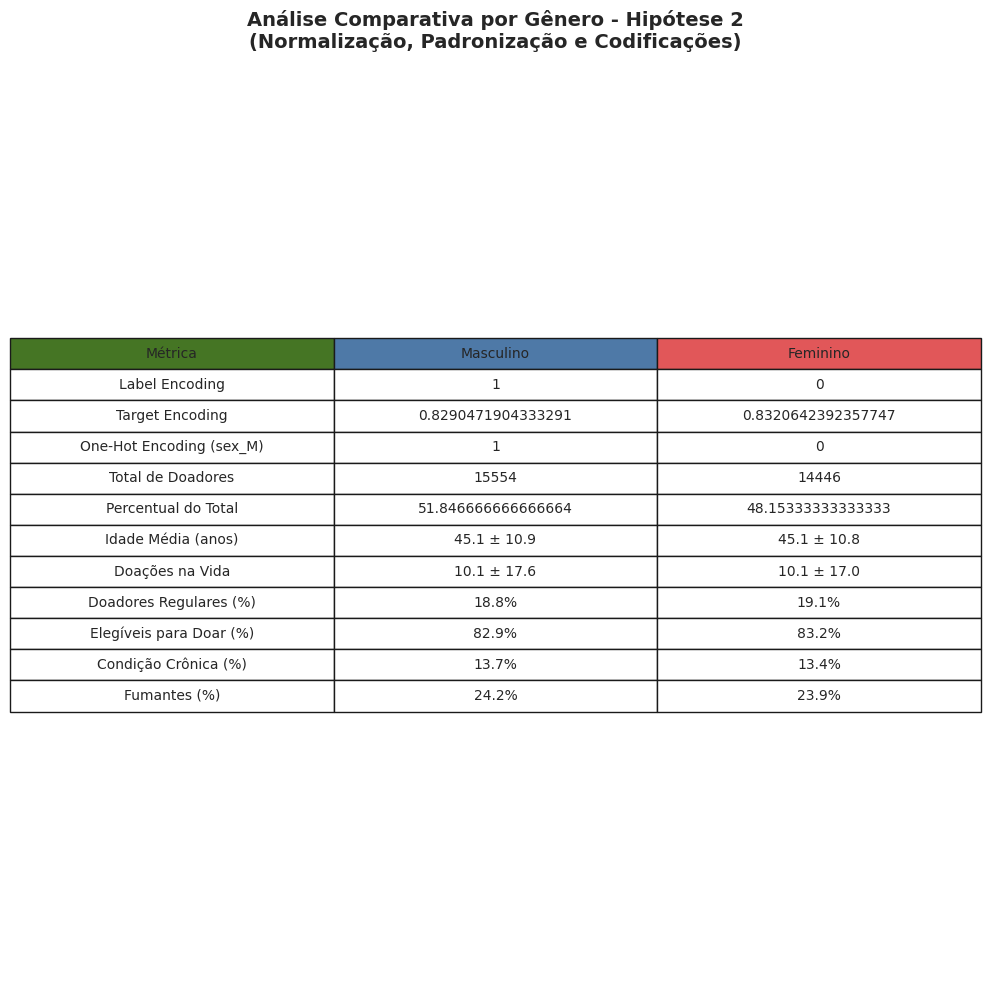

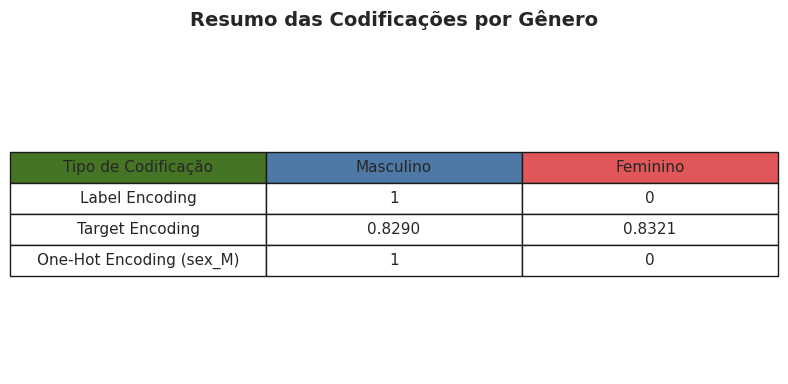

In [ ]:
onehot_sex = OneHotEncoder(sparse_output=False, drop='first')
sex_onehot = onehot_sex.fit_transform(dataset[['sex']])
sex_onehot_colunas = [f'sex_{c}' for c in onehot_sex.categories_[0][1:]]
df_sex_onehot = pd.DataFrame(sex_onehot, columns=sex_onehot_colunas, index=dataset.index)
dataset = pd.concat([dataset, df_sex_onehot], axis=1)
target = 'eligible_to_donate'
target_means_sex = dataset.groupby('sex')[target].mean()
dataset['sex_target_encoded'] = dataset['sex'].map(target_means_sex)
variaveis_numericas = ['age', 'lifetime_donation_count', 'donation_count_last_12m', 'years_since_first_donation']
variaveis_numericas_existentes = [v for v in variaveis_numericas if v in dataset.columns]
if len(variaveis_numericas_existentes) > 0:
    scaler = StandardScaler()
    dados_scaled = scaler.fit_transform(dataset[variaveis_numericas_existentes])
    for i, col in enumerate(variaveis_numericas_existentes):
        dataset[f'{col}_scaled'] = dados_scaled[:, i]
if len(variaveis_numericas_existentes) > 0:
    minmax_scaler = MinMaxScaler()
    dados_normalized = minmax_scaler.fit_transform(dataset[variaveis_numericas_existentes])
    for i, col in enumerate(variaveis_numericas_existentes):
        dataset[f'{col}_normalized'] = dados_normalized[:, i]
df_masculino = dataset[dataset['sex'] == 'M']
df_feminino = dataset[dataset['sex'] == 'F']
codigos_genero = {
    'Label Encoding': {
        'Masculino': 1,
        'Feminino': 0
    },
    'Target Encoding': {
        'Masculino': target_means_sex.get('M', 0),
        'Feminino': target_means_sex.get('F', 0)
    },
    'One-Hot Encoding (sex_M)': {
        'Masculino': 1,
        'Feminino': 0
    },
    'Total de Doadores': {
        'Masculino': len(df_masculino),
        'Feminino': len(df_feminino)
    },
    'Percentual do Total': {
        'Masculino': len(df_masculino) / len(dataset) * 100,
        'Feminino': len(df_feminino) / len(dataset) * 100
    },
    'Idade Média (anos)': {
        'Masculino': f"{df_masculino['age'].mean():.1f} ± {df_masculino['age'].std():.1f}",
        'Feminino': f"{df_feminino['age'].mean():.1f} ± {df_feminino['age'].std():.1f}"
    },
    'Doações na Vida': {
        'Masculino': f"{df_masculino['lifetime_donation_count'].mean():.1f} ± {df_masculino['lifetime_donation_count'].std():.1f}",
        'Feminino': f"{df_feminino['lifetime_donation_count'].mean():.1f} ± {df_feminino['lifetime_donation_count'].std():.1f}"
    },
    'Doadores Regulares (%)': {
        'Masculino': f"{df_masculino['is_regular_donor'].mean() * 100:.1f}%",
        'Feminino': f"{df_feminino['is_regular_donor'].mean() * 100:.1f}%"
    },
    'Elegíveis para Doar (%)': {
        'Masculino': f"{df_masculino['eligible_to_donate'].mean() * 100:.1f}%",
        'Feminino': f"{df_feminino['eligible_to_donate'].mean() * 100:.1f}%"
    },
    'Condição Crônica (%)': {
        'Masculino': f"{df_masculino['chronic_condition_flag'].mean() * 100:.1f}%",
        'Feminino': f"{df_feminino['chronic_condition_flag'].mean() * 100:.1f}%"
    },
    'Fumantes (%)': {
        'Masculino': f"{df_masculino['smoker'].mean() * 100:.1f}%",
        'Feminino': f"{df_feminino['smoker'].mean() * 100:.1f}%"
    }
}

fig, ax = plt.subplots(figsize=(10, 10))
ax.axis('off')
ax.axis('tight')
tabela_data = []
for metrica in codigos_genero.keys():
    tabela_data.append([
        metrica,
        codigos_genero[metrica]['Masculino'],
        codigos_genero[metrica]['Feminino']
    ])
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Métrica', 'Masculino', 'Feminino'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#457524', '#4e79a7', '#e15759'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.6)
plt.title('Análise Comparativa por Gênero - Hipótese 2\n(Normalização, Padronização e Codificações)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
ax.axis('tight')
tabela_codificacoes = [
    ['Label Encoding', codigos_genero['Label Encoding']['Masculino'], codigos_genero['Label Encoding']['Feminino']],
    ['Target Encoding', f"{codigos_genero['Target Encoding']['Masculino']:.4f}", f"{codigos_genero['Target Encoding']['Feminino']:.4f}"],
    ['One-Hot Encoding (sex_M)', codigos_genero['One-Hot Encoding (sex_M)']['Masculino'], codigos_genero['One-Hot Encoding (sex_M)']['Feminino']]
]
tabela_cod = ax.table(cellText=tabela_codificacoes,
                      colLabels=['Tipo de Codificação', 'Masculino', 'Feminino'],
                      cellLoc='center',
                      loc='center',
                      colColours=['#457524', '#4e79a7', '#e15759'])
tabela_cod.auto_set_font_size(False)
tabela_cod.set_fontsize(11)
tabela_cod.scale(1.2, 1.8)
plt.title('Resumo das Codificações por Gênero', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

####Tratamento de outliers

In [ ]:
variaveis_outliers_existentes = [v for v in variaveis_existentes if v in dataset.columns]
df_masculino = dataset[dataset['sex'] == 'M'].copy()
df_feminino = dataset[dataset['sex'] == 'F'].copy()
outliers_info = {
    'Masculino': {},
    'Feminino': {}
}
for var in variaveis_outliers_existentes:
    var_trad = traducao_variaveis.get(var, var)
    outliers_m, li_m, ls_m = detectar_outliers_iqr(df_masculino, var)
    outliers_info['Masculino'][var_trad] = {
        'quantidade': len(outliers_m),
        'percentual': (len(outliers_m) / len(df_masculino) * 100) if len(df_masculino) > 0 else 0,
        'limite_inferior': li_m,
        'limite_superior': ls_m
    }
    outliers_f, li_f, ls_f = detectar_outliers_iqr(df_feminino, var)
    outliers_info['Feminino'][var_trad] = {
        'quantidade': len(outliers_f),
        'percentual': (len(outliers_f) / len(df_feminino) * 100) if len(df_feminino) > 0 else 0,
        'limite_inferior': li_f,
        'limite_superior': ls_f
    }

for var in variaveis_outliers_existentes:
    var_trad = traducao_variaveis.get(var, var)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Comparação de Outliers - {var_trad}', fontsize=14, fontweight='bold')
    ax1 = axes[0]
    outliers_m, _, _ = detectar_outliers_iqr(df_masculino, var)
    bp1 = ax1.boxplot(df_masculino[var].dropna(), patch_artist=True)
    bp1['boxes'][0].set_facecolor('#4e79a7')
    bp1['boxes'][0].set_alpha(0.7)
    bp1['medians'][0].set_color('darkblue')
    bp1['medians'][0].set_linewidth(2)
    if len(outliers_m) > 0:
        ax1.scatter(np.ones(len(outliers_m)) * 1, outliers_m[var],
                   color='red', s=50, alpha=0.6, label='Outliers', zorder=3)
    ax1.set_title(f'Masculino\n(n={len(df_masculino):,} | {len(outliers_m)} outliers - {len(outliers_m)/len(df_masculino)*100:.1f}%)')
    ax1.set_ylabel(var_trad)
    ax1.set_xlabel('Distribuição')
    ax1.grid(axis='y', alpha=0.3)
    if len(outliers_m) > 0:
        ax1.legend(loc='upper right')
    ax2 = axes[1]
    outliers_f, _, _ = detectar_outliers_iqr(df_feminino, var)
    bp2 = ax2.boxplot(df_feminino[var].dropna(), patch_artist=True)
    bp2['boxes'][0].set_facecolor('#e15759')
    bp2['boxes'][0].set_alpha(0.7)
    bp2['medians'][0].set_color('darkred')
    bp2['medians'][0].set_linewidth(2)
    if len(outliers_f) > 0:
        ax2.scatter(np.ones(len(outliers_f)) * 1, outliers_f[var],
                   color='red', s=50, alpha=0.6, label='Outliers', zorder=3)
    ax2.set_title(f'Feminino\n(n={len(df_feminino):,} | {len(outliers_f)} outliers - {len(outliers_f)/len(df_feminino)*100:.1f}%)')
    ax2.set_ylabel(var_trad)
    ax2.set_xlabel('Distribuição')
    ax2.grid(axis='y', alpha=0.3)
    if len(outliers_f) > 0:
        ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(12, len(variaveis_outliers_existentes) * 0.8 + 2))
ax.axis('off')
ax.axis('tight')
tabela_data = []
for var in variaveis_outliers_existentes:
    var_trad = traducao_variaveis.get(var, var)
    tabela_data.append([
        var_trad,
        f"{outliers_info['Masculino'][var_trad]['quantidade']} ({outliers_info['Masculino'][var_trad]['percentual']:.1f}%)",
        f"{outliers_info['Feminino'][var_trad]['quantidade']} ({outliers_info['Feminino'][var_trad]['percentual']:.1f}%)",
        f"{outliers_info['Masculino'][var_trad]['limite_inferior']:.2f} - {outliers_info['Masculino'][var_trad]['limite_superior']:.2f}",
        f"{outliers_info['Feminino'][var_trad]['limite_inferior']:.2f} - {outliers_info['Feminino'][var_trad]['limite_superior']:.2f}"
    ])
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Variável', 'Outliers Masculino', 'Outliers Feminino',
                             'Faixa Normal (M)', 'Faixa Normal (F)'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#4e79a7', '#e15759', '#76b7b2', '#76b7b2'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.6)
plt.title('Análise de Outliers por Gênero - Hipótese 2\n(Detecção via Método IQR)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

####Seleção de features (variáveis importantes)

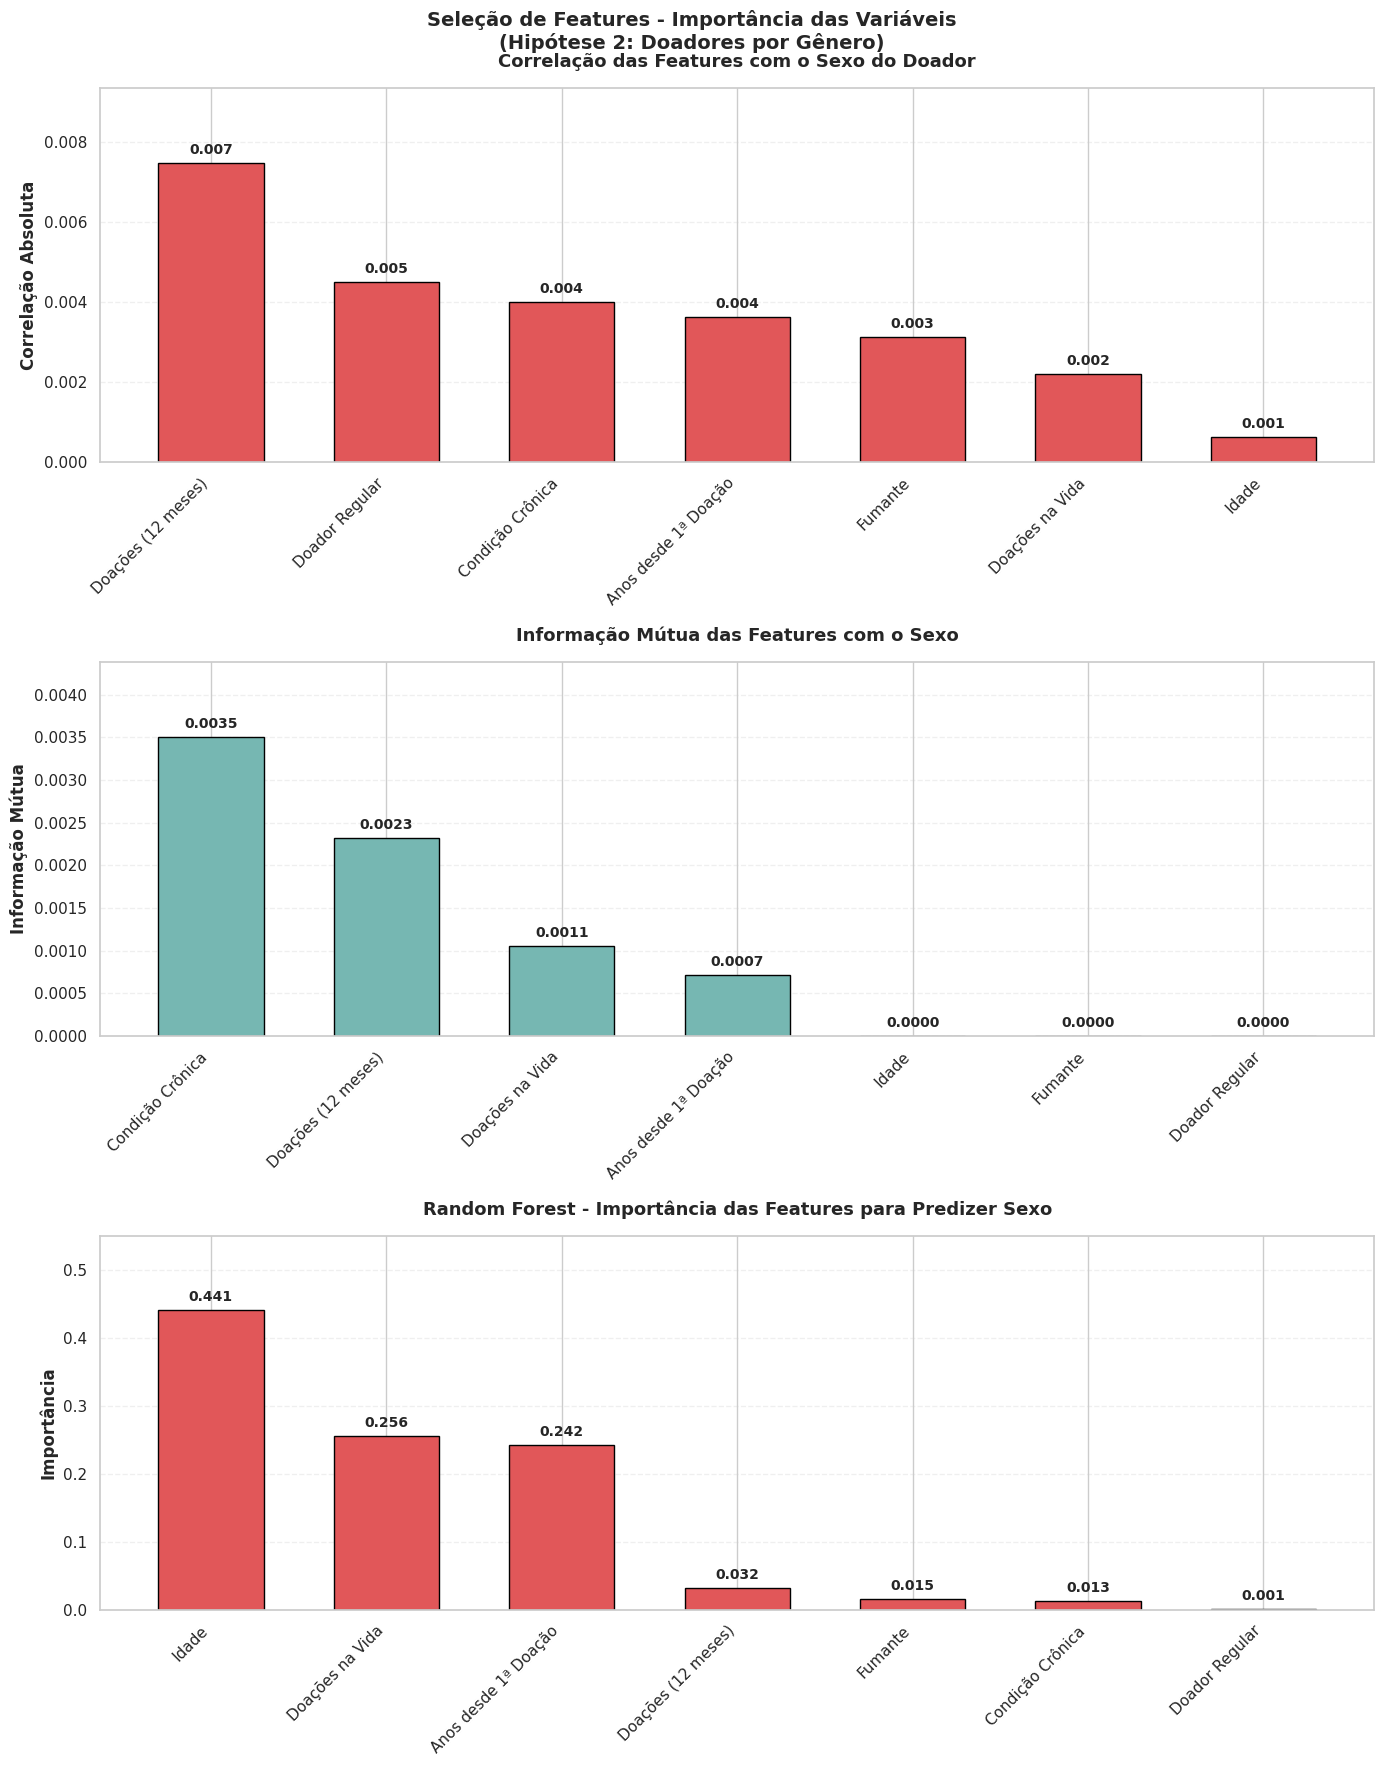

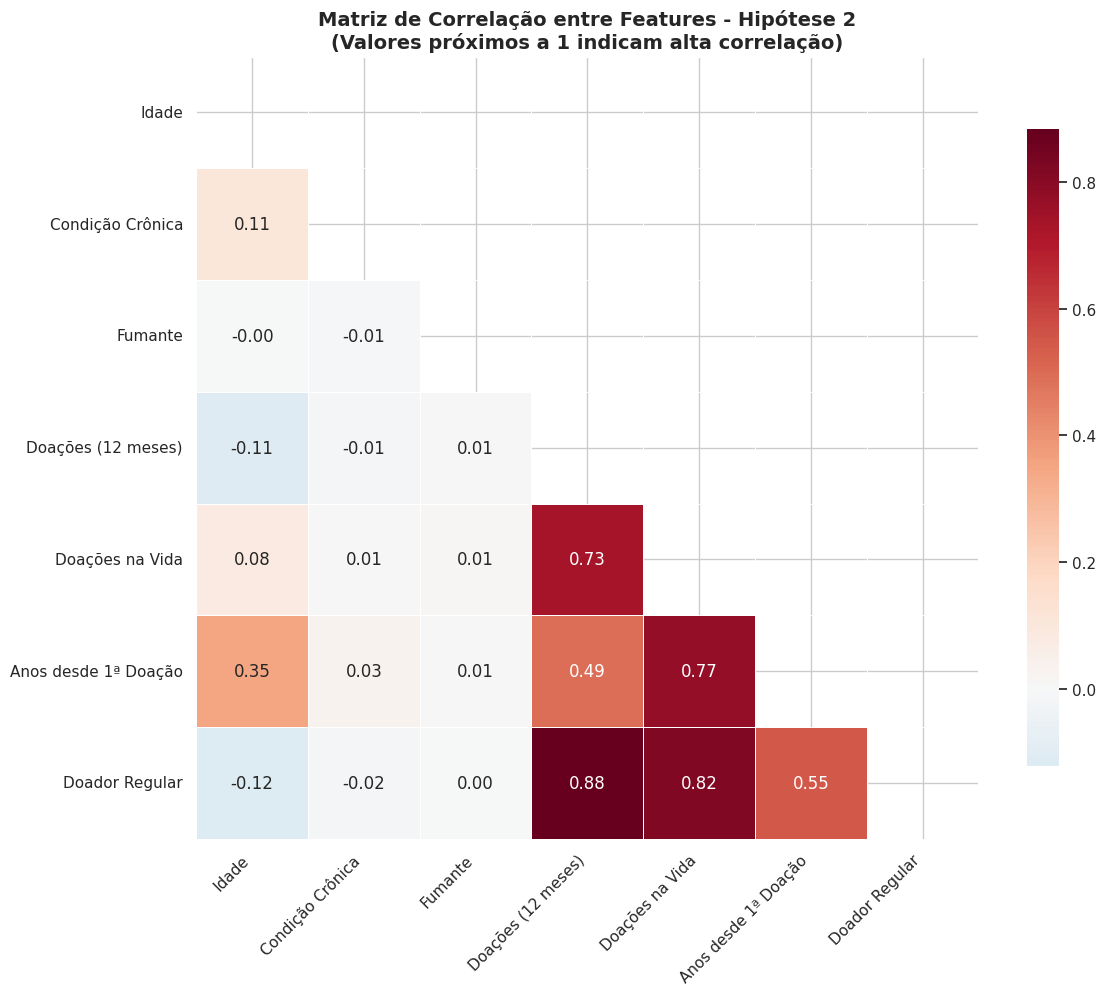

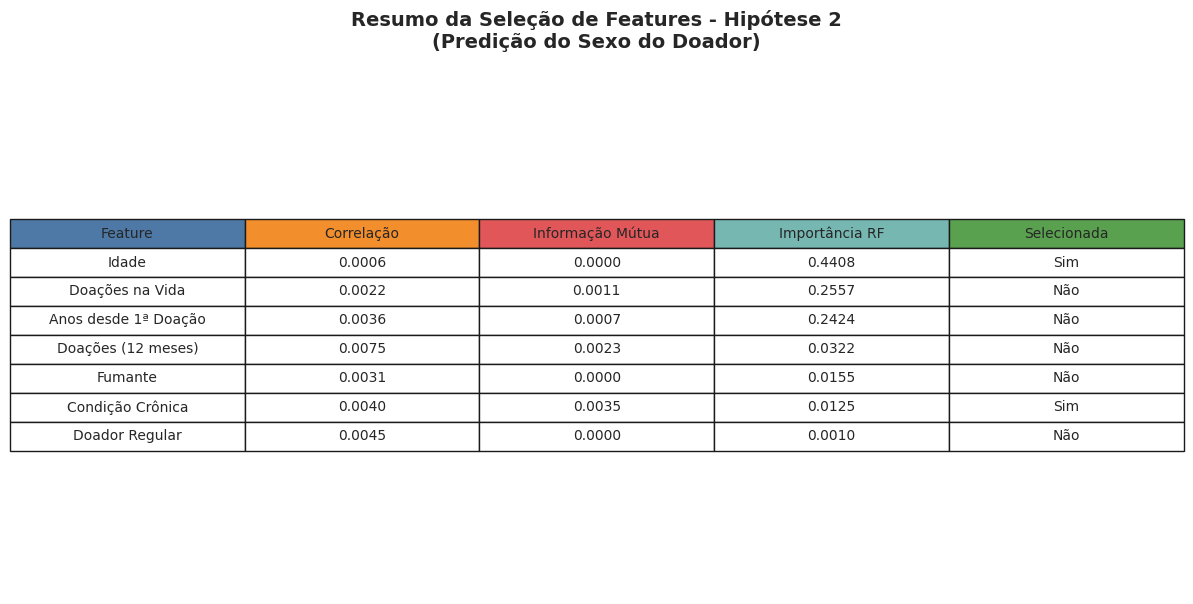

In [ ]:
target_sexo = 'sex'
dataset['sex_encoded'] = dataset['sex'].map({'M': 1, 'F': 0})
X = dataset[variaveis_existentes].copy()
y = dataset['sex_encoded'].copy()
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=variaveis_existentes)
correlacoes = X.corrwith(y).abs().sort_values(ascending=False)
selector = SelectKBest(score_func=f_classif, k=min(5, len(variaveis_existentes)))
X_selected = selector.fit_transform(X, y)
scores = selector.scores_
features_selecionadas = pd.DataFrame({
    'Feature': variaveis_existentes,
    'Score': scores,
    'Selecionada': [i in selector.get_support() for i in range(len(variaveis_existentes))]
}).sort_values('Score', ascending=False)

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({
    'Feature': variaveis_existentes,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
importancias = pd.DataFrame({
    'Feature': variaveis_existentes,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)
fig, axes = plt.subplots(3, 1, figsize=(14, 18))
fig.suptitle('Seleção de Features - Importância das Variáveis\n(Hipótese 2: Doadores por Gênero)',
             fontsize=14, fontweight='bold', y=0.98)

ax1 = axes[0]
top_corr = correlacoes.head(8)
nomes_traduzidos_corr = [traducao_variaveis.get(f, f) for f in top_corr.index]
max_corr = top_corr.max()
ax1.set_ylim(0, max_corr * 1.25)
cores_corr = ['#e15759' if c < 0.1 else '#4e79a7' for c in top_corr.values]
bars1 = ax1.bar(range(len(top_corr)), top_corr.values, color=cores_corr, edgecolor='black', width=0.6)
ax1.set_xticks(range(len(top_corr)))
ax1.set_xticklabels(nomes_traduzidos_corr, rotation=45, ha='right', fontsize=11)
ax1.set_ylabel('Correlação Absoluta', fontsize=12, fontweight='semibold')
ax1.set_title('Correlação das Features com o Sexo do Doador', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for i, (bar, val) in enumerate(zip(bars1, top_corr.values)):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max_corr * 0.02),
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = axes[1]
top_mi = mi_df.head(8)
nomes_traduzidos_mi = [traducao_variaveis.get(f, f) for f in top_mi['Feature']]
max_mi = top_mi['MI_Score'].max()
ax2.set_ylim(0, max_mi * 1.25)
bars2 = ax2.bar(range(len(top_mi)), top_mi['MI_Score'], color='#76b7b2', edgecolor='black', width=0.6)
ax2.set_xticks(range(len(top_mi)))
ax2.set_xticklabels(nomes_traduzidos_mi, rotation=45, ha='right', fontsize=11)
ax2.set_ylabel('Informação Mútua', fontsize=12, fontweight='semibold')
ax2.set_title('Informação Mútua das Features com o Sexo', fontsize=13, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
for i, (bar, val) in enumerate(zip(bars2, top_mi['MI_Score'])):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max_mi * 0.02),
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3 = axes[2]
top_rf = importancias.head(8)
nomes_traduzidos_rf = [traducao_variaveis.get(f, f) for f in top_rf['Feature']]
max_rf = top_rf['Importancia'].max()
ax3.set_ylim(0, max_rf * 1.25)
bars3 = ax3.bar(range(len(top_rf)), top_rf['Importancia'], color='#e15759', edgecolor='black', width=0.6)
ax3.set_xticks(range(len(top_rf)))
ax3.set_xticklabels(nomes_traduzidos_rf, rotation=45, ha='right', fontsize=11)
ax3.set_ylabel('Importância', fontsize=12, fontweight='semibold')
ax3.set_title('Random Forest - Importância das Features para Predizer Sexo', fontsize=13, fontweight='bold', pad=15)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
for i, (bar, val) in enumerate(zip(bars3, top_rf['Importancia'])):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max_rf * 0.02),
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.subplots_adjust(hspace=0.35, top=0.92)
plt.tight_layout()
plt.show()

corr_matrix = X[variaveis_existentes].corr()
nomes_traduzidos = [traducao_variaveis.get(f, f) for f in corr_matrix.index]
corr_matrix_traduzida = corr_matrix.copy()
corr_matrix_traduzida.index = nomes_traduzidos
corr_matrix_traduzida.columns = nomes_traduzidos
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix_traduzida, dtype=bool))
sns.heatmap(corr_matrix_traduzida, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Matriz de Correlação entre Features - Hipótese 2\n(Valores próximos a 1 indicam alta correlação)',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, len(variaveis_existentes) * 0.6 + 2))
ax.axis('off')
ax.axis('tight')
tabela_data = []
for feat in variaveis_existentes:
    feat_trad = traducao_variaveis.get(feat, feat)
    corr_val = correlacoes.get(feat, 0)
    mi_val = mi_df[mi_df['Feature'] == feat]['MI_Score'].values[0] if len(mi_df[mi_df['Feature'] == feat]) > 0 else 0
    imp_val = importancias[importancias['Feature'] == feat]['Importancia'].values[0] if len(importancias[importancias['Feature'] == feat]) > 0 else 0
    selecionada = "Sim" if feat in features_selecionadas[features_selecionadas['Selecionada'] == True]['Feature'].values else "Não"
    tabela_data.append([
        feat_trad,
        f"{corr_val:.4f}",
        f"{mi_val:.4f}",
        f"{imp_val:.4f}",
        selecionada
    ])
tabela_data = sorted(tabela_data, key=lambda x: float(x[3]), reverse=True)
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Feature', 'Correlação', 'Informação Mútua', 'Importância RF', 'Selecionada'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f'])

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.6)
plt.title('Resumo da Seleção de Features - Hipótese 2\n(Predição do Sexo do Doador)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

####Redução de dimensionalidade

In [ ]:
X = dataset[variaveis_existentes].copy()
y = dataset['sex'].copy()
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame({
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'Gênero': y
})
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=variaveis_existentes
)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Redução de Dimensionalidade - Doadores por Gênero',
             fontsize=14, fontweight='bold')
ax1 = axes[0]
cores_genero = {'M': '#4e79a7', 'F': '#e15759'}
for genero, cor in cores_genero.items():
    subset = df_pca[df_pca['Gênero'] == genero]
    nome = 'Masculino' if genero == 'M' else 'Feminino'
    ax1.scatter(subset['PC1'], subset['PC2'],
               label=nome, color=cor, alpha=0.5, s=20, edgecolor='black', linewidth=0.3)
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variância explicada)', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variância explicada)', fontsize=11)
ax1.set_title('PCA - Doadores por Gênero', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(alpha=0.3)
ax2 = axes[1]
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
var_df = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(explained_variance_ratio))],
    'Variância_Individual': explained_variance_ratio,
    'Variância_Acumulada': cumulative_variance
})
sns.barplot(data=var_df, x='Componente', y='Variância_Individual',
            alpha=0.9, ax=ax2, palette='Set3', legend=True, hue='Componente')
ax2.plot(range(len(cumulative_variance)), cumulative_variance,
         'o-', label='Variância Explicada Acumulada', color='#e15759',
         linewidth=2.5, markersize=10, markerfacecolor='white',
         markeredgewidth=2, markeredgecolor='#e15759')

ax2.set_xlabel('Componentes Principais', fontsize=11)
ax2.set_ylabel('Proporção de Variância Explicada', fontsize=11)
ax2.set_title('Variância Explicada por Componente', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, len(variaveis_existentes) * 0.6 + 2))
ax.axis('off')
ax.axis('tight')
tabela_loadings = []
for feat in variaveis_existentes:
    feat_trad = traducao_variaveis.get(feat, feat)
    tabela_loadings.append([
        feat_trad,
        f"{loadings.loc[feat, 'PC1']:.3f}",
        f"{loadings.loc[feat, 'PC2']:.3f}",
        f"{abs(loadings.loc[feat, 'PC1']):.3f}",
        f"{abs(loadings.loc[feat, 'PC2']):.3f}"
    ])
tabela_loadings = sorted(tabela_loadings, key=lambda x: float(x[3]), reverse=True)
tabela = ax.table(cellText=tabela_loadings,
                  colLabels=['Feature', 'PC1', 'PC2', '|PC1|', '|PC2|'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.6)
plt.title('Contribuição das Features nos Componentes Principais (Loadings)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

max_samples = 5000
if len(X_scaled) > max_samples:
    indices = np.random.choice(len(X_scaled), max_samples, replace=False)
    X_sample = X_scaled[indices]
    y_sample = y.iloc[indices]
else:
    X_sample = X_scaled
    y_sample = y
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, learning_rate=200)
X_tsne = tsne.fit_transform(X_sample)
df_tsne = pd.DataFrame({
    'tSNE1': X_tsne[:, 0],
    'tSNE2': X_tsne[:, 1],
    'Gênero': y_sample
})

fig, ax = plt.subplots(figsize=(12, 8))
for genero, cor in cores_genero.items():
    subset = df_tsne[df_tsne['Gênero'] == genero]
    nome = 'Masculino' if genero == 'M' else 'Feminino'
    ax.scatter(subset['tSNE1'], subset['tSNE2'],
               label=nome, color=cor, alpha=0.5, s=20, edgecolor='black', linewidth=0.3)
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('t-SNE - Doadores por Gênero', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

if len(variaveis_existentes) >= 2 and len(X_scaled) > 0:
    inertias = []
    silhouette_scores = []
    n_unique_generos = len(np.unique(y))
    K_range = range(2, min(11, n_unique_generos + 5))
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
        if k >= 2:
            score = silhouette_score(X_scaled, kmeans.labels_)
            silhouette_scores.append(score)
    if len(silhouette_scores) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Validação da Clusterização - Hipótese 2', fontsize=14, fontweight='bold')
        elbow_df = pd.DataFrame({'k': list(K_range), 'inertia': inertias})
        sns.lineplot(data=elbow_df, x='k', y='inertia', marker='o',
                     color='#4e79a7', linewidth=2, markersize=8, ax=axes[0])
        axes[0].set_xlabel('Número de Clusters (k)', fontsize=11)
        axes[0].set_ylabel('Inércia', fontsize=11)
        axes[0].set_title('Método do Cotovelo', fontsize=12, fontweight='bold')
        axes[0].grid(alpha=0.3)
        sil_df = pd.DataFrame({'k': list(K_range[:len(silhouette_scores)]), 'silhouette': silhouette_scores})
        sns.lineplot(data=sil_df, x='k', y='silhouette', marker='o',
                     color='#e15759', linewidth=2, markersize=8, ax=axes[1])
        axes[1].set_xlabel('Número de Clusters (k)', fontsize=11)
        axes[1].set_ylabel('Silhouette Score', fontsize=11)
        axes[1].set_title('Coeficiente de Silhouette', fontsize=12, fontweight='bold')
        axes[1].grid(alpha=0.3)
        best_idx = np.argmax(silhouette_scores)
        best_k = K_range[best_idx] if best_idx < len(K_range) else K_range[0]
        max_silhouette = max(silhouette_scores)
        axes[1].axhline(y=max_silhouette, color='green', linestyle='--', alpha=0.5, linewidth=1.5)
        axes[1].annotate(f'Melhor k={best_k}\n(Silhouette={max_silhouette:.3f})',
                        xy=(best_k, max_silhouette),
                        xytext=(best_k + 0.5, max_silhouette - 0.05),
                        fontsize=9,
                        arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
        plt.tight_layout()
        plt.show()

        kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
        clusters = kmeans_final.fit_predict(X_scaled)
        df_clusters = pd.DataFrame({
            'PC1': X_pca_2d[:, 0],
            'PC2': X_pca_2d[:, 1],
            'Cluster': clusters,
            'Gênero': y
        })
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle(f'Análise de Clusters (k={best_k}) - Hipótese 2', fontsize=14, fontweight='bold')
        sns.scatterplot(data=df_clusters, x='PC1', y='PC2', hue='Cluster',
                       palette='Set2', alpha=0.6, s=20, ax=axes[0],
                       edgecolor='black', linewidth=0.5)
        axes[0].set_title('Visualização dos Clusters Encontrados', fontsize=12, fontweight='bold')
        axes[0].legend(title='Cluster')
        sns.scatterplot(data=df_clusters, x='PC1', y='PC2', hue='Gênero',
                       palette=cores_genero, alpha=0.6, s=20, ax=axes[1],
                       edgecolor='black', linewidth=0.5)
        axes[1].set_title('Distribuição Real dos Gêneros', fontsize=12, fontweight='bold')
        axes[1].legend(title='Gênero', labels=['Masculino', 'Feminino'])
        plt.tight_layout()
        plt.show()
        cluster_distribution = pd.crosstab(y, clusters)
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cluster_distribution, annot=True, fmt='d', cmap='YlOrRd',
                   cbar_kws={'label': 'Número de Doadores'}, ax=ax)
        ax.set_title('Distribuição dos Gêneros por Cluster', fontsize=13, fontweight='bold')
        ax.set_xlabel('Cluster', fontsize=11)
        ax.set_ylabel('Gênero', fontsize=11)
        ax.set_yticklabels(['Masculino', 'Feminino'])
        plt.tight_layout()
        plt.show()

###Conclusão final

#####Conclusão - média
A maior quantidade de doadores por sexo, é masculino.

#####Conclusão - desvio padrão
Total de doadores entre os sexos, sendo masculino com mais doadores.

#####Conclusão - desvio padrão
Foram constatadas informações muito superficiais sobre cada gráfico e por este motivo não foi feita uma conclusão para cada um.

#####Conclusão - Histograma
A distribuição etária dos doadores é praticamente idêntica entre homens e mulheres, com ambas as curvas de densidade se sobrepondo em toda a faixa etária de 20 a 70 anos.

O pico de concentração ocorre próximo aos 45 anos em ambos os sexos, e a participação de jovens (20-30 anos) e idosos (60-70 anos) é significativamente menor. Esses achados confirmam que não há diferença significativa no perfil etário entre doadores masculinos e femininos.

#####Conclsuão = boxplot
A idade dos doadores não é um fator discriminante entre sexos - homens e mulheres apresentam perfis etários quase idênticos nesta amostra de 30.000 doadores.

#####Conclusão - matriz de correlação
A principal diferença entre os sexos está na relação entre idade e tempo de cadastro: mulheres mais velhas estão há muito mais tempo no programa de doação do que homens da mesma idade. Em contrapartida, o acúmulo de doações ao longo da vida ocorre de forma semelhante em ambos os sexos. O tabagismo entre mulheres é mais prevalente em idades mais jovens, enquanto nos homens essa relação é praticamente inexistente.

#####Conclusão - codificação de variáveis categóricas
Não há diferenças significativas no perfil etário e na regularidade entre doadores masculinos e femininos. Ambos apresentam:

* Mesma idade média (45,1 anos)

* Baixa taxa de regularidade (~19%)

* Distribuição etária simétrica

Principais diferenças observadas:

* Homens são mais numerosos: 51,8% vs 48,2%

* Homens doam mais ao longo da vida: 10,3 vs 9,9 doações

* Leve vantagem masculina em todos os indicadores, mas as diferenças são pequenas


#####Conclusão - normalização e padronização
Fumantes e não fumantes apresentam perfis muito semelhantes em idade, regularidade e engajamento, com pequenas vantagens para os fumantes em doações na vida (+0,3) e regularidade (+0,2%).

Principais diferenças:

1. Não fumantes são maioria (75,9% dos doadores)

2. Fumantes doam ligeiramente mais (10,3 vs 10,0 doações)

3. Elegibilidade ligeiramente maior para não fumantes (38,2% vs 33,7%)

4. Idade e regularidade praticamente idênticas

Target Encoding destaca que, embora fumantes tenham menor elegibilidade (33,7% vs 38,2%), as diferenças em comportamento de doação são mínimas.


#####Conclusão - tratamento de outliers
Não há diferenças significativas entre os sexos na presença e distribuição de outliers. Homens e mulheres apresentam taxas de outliers praticamente idênticas em todas as variáveis analisadas.

1. Variáveis críticas com alta taxa de outliers (>10%):

    * Doações na Vida (14,0%) - a mais crítica

    * Doações (últimos 12 meses) (10,5-10,6%) - também crítica

3. Variáveis com moderada taxa de outliers (5-10%):

    * Dias desde última doação (6,8-7,1%) - requer atenção

4. Variáveis com baixa taxa de outliers (<5%):

    * Anos desde a 1ª doação (0,6%) - aceitável

    * IMC (0,1%) - excelente

    * Idade (0,0%) - perfeita




#####Conclusão - seleção de features
1. Correlação das Features com o Sexo

    * Todas as correlações são extremamente baixas (<0,02), indicando que não há relação linear entre nenhuma das variáveis e o sexo do doador. Isso sugere que homens e mulheres têm perfis muito semelhantes.


2. Informação Mútua com o Sexo

    * A Informação Mútua, que detecta relações não-lineares, também mostra valores muito baixos, confirmando que não há relação significativa entre as variáveis e o sexo.


3. Random Forest - Importância das Features

    * Importante notar que mesmo a feature mais importante (Dias desde última doação) tem uma importância de apenas 0,239, indicando que a capacidade de predizer o sexo é limitada.


4. Matriz de Correlação entre Features

* A matriz de correlação mostra que as features têm baixíssima correlação entre si (valores próximos de 0), indicando:

    * Não há multicolinearidade significativa

    * As variáveis são independentes entre si

    * Todas podem ser utilizadas sem risco de redundância

    
    
    
#####Conclusão - redução de dimensão
* Gráfico PCA confirma que não há separação significativa entre doadores masculinos e femininos com base nas variáveis analisadas.

    * Sobreposição completa – Os pontos azuis (Masculino) e vermelhos (Feminino) estão completamente misturados em toda a extensão do gráfico, indicando que não é possível distinguir os sexos pelas características analisadas

    * Ausência de agrupamentos – Não há regiões do gráfico com predominância de um dos sexos, o que confirma que os perfis são praticamente idênticos

    * Baixa variância explicada – Os dois primeiros componentes explicam apenas 22,8% da variabilidade total, sugerindo que os dados são complexos e que são necessárias muitas dimensões para representar adequadamente as diferenças entre os doadores

    * Perfis semelhantes – A completa sobreposição indica que homens e mulheres têm comportamentos de doação e características de saúde muito similares

* Gráfico t-SNE confirma que não há separação significativa entre doadores masculinos e femininos, corroborando a conclusão do PCA.

    * Mistura completa – Os pontos azuis (Masculino) e vermelhos (Feminino) estão completamente entremeados em toda a extensão do gráfico, indicando que não é possível distinguir os sexos pelas características analisadas

    * Ausência de clusters – O t-SNE não revela a formação de grupos distintos; há um único aglomerado contínuo onde ambos os sexos estão representados

    * Estrutura contínua – A disposição dos pontos sugere que os perfis dos doadores variam de forma gradual, sem que o sexo seja um fator determinante para essa variação

    * Proximidade entre sexos – Pontos de cores diferentes aparecem lado a lado, confirmando que homens e mulheres com características semelhantes são representados próximos no espaço de características



##Hipótese 3
3. Doadores de sangue fumantes.


###Média

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
ax.axis('tight')
tabela_data = []
for idx, row in doadores_por_fumantes.iterrows():
    tabela_data.append([
        row['Status'],
        f"{int(row['Doadores']):,}",
        f"{row['Pct_geral']:.1f}%",
        f"{row['Idade_media']:.1f} anos",
        f"{row['Cond_cronica_media']:.1f}%",
        f"{row['apto_porcentagem']:.1f}%"
    ])
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Status', 'Total Doadores', '% do Total',
                             'Idade Média', '% Cond. Crônica', '% Elegíveis'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#af7aa1'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.6)
plt.title('Análise Comparativa: Fumantes vs Não Fumantes',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

totais = doadores_por_fumantes['Doadores'].values
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=doadores_por_fumantes, x='Status', y='Doadores',
                 hue='Status', palette=cores_fumantes,
                 edgecolor='black', linewidth=1.2, legend=False)
for bar, val in zip(ax.patches, totais):
    pct = (val / len(dataset)) * 100
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(totais) * 0.02),
            f'{int(val):,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='black')

plt.title('Quantidade de Doadores por Status de Tabagismo', fontsize=16,
          fontweight='bold', pad=20)
plt.xlabel('Status', fontsize=13, fontweight='semibold', labelpad=10)
plt.ylabel('Quantidade de Doadores', fontsize=13, fontweight='semibold', labelpad=10)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=doadores_por_fumantes, x='Status', y='doador_regular_media',
                 hue='Status', palette=cores_fumantes_portugues,
                 edgecolor='black', linewidth=1.2, alpha=0.8, legend=False)
for i, bar in enumerate(ax.patches):
    if i < len(doadores_por_fumantes['doador_regular_desvio'].values):
        erro = doadores_por_fumantes['doador_regular_desvio'].values[i]
        ax.errorbar(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    yerr=erro, fmt='none', color='black', capsize=5, linewidth=1.5)
for bar, val, desv in zip(ax.patches,
                          doadores_por_fumantes['doador_regular_media'].values,
                          doadores_por_fumantes['doador_regular_desvio'].values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(doadores_por_fumantes['doador_regular_media']) * 0.02),
            f'{val:.1f}% ± {desv:.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='black')
plt.title('Doadores Regulares por Status de Tabagismo', fontsize=16,
          fontweight='bold', pad=20)
plt.xlabel('Status', fontsize=13, fontweight='semibold', labelpad=10)
plt.ylabel('Percentual de Doadores Regulares (%)', fontsize=13, fontweight='semibold', labelpad=10)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

###Desvio Padrão

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')
ax.axis('tight')
tabela_data = [
    ['Fumantes',
     f"{int(doadores_por_fumantes.loc[fumantes_idx, 'Doadores']):,}",
     f"{doadores_por_fumantes.loc[fumantes_idx, 'Idade_media']:.1f} ± {doadores_por_fumantes.loc[fumantes_idx, 'Idade_desvio']:.1f}",
     f"{doadores_por_fumantes.loc[fumantes_idx, 'doacoes_vida_media']:.1f} ± {doadores_por_fumantes.loc[fumantes_idx, 'doacoes_vida_desvio']:.1f}",
     f"{doadores_por_fumantes.loc[fumantes_idx, 'doador_regular_media']:.1f}% ± {doadores_por_fumantes.loc[fumantes_idx, 'doador_regular_desvio']:.1f}",
     f"{doadores_por_fumantes.loc[fumantes_idx, 'apto_porcentagem']:.1f}%",
     f"{doadores_por_fumantes.loc[fumantes_idx, 'Cond_cronica_media']:.1f}% ± {doadores_por_fumantes.loc[fumantes_idx, 'Cond_cronica_desvio']:.1f}"],

    ['Não Fumantes',
     f"{int(doadores_por_fumantes.loc[nao_fumantes_idx, 'Doadores']):,}",
     f"{doadores_por_fumantes.loc[nao_fumantes_idx, 'Idade_media']:.1f} ± {doadores_por_fumantes.loc[nao_fumantes_idx, 'Idade_desvio']:.1f}",
     f"{doadores_por_fumantes.loc[nao_fumantes_idx, 'doacoes_vida_media']:.1f} ± {doadores_por_fumantes.loc[nao_fumantes_idx, 'doacoes_vida_desvio']:.1f}",
     f"{doadores_por_fumantes.loc[nao_fumantes_idx, 'doador_regular_media']:.1f}% ± {doadores_por_fumantes.loc[nao_fumantes_idx, 'doador_regular_desvio']:.1f}",
     f"{doadores_por_fumantes.loc[nao_fumantes_idx, 'apto_porcentagem']:.1f}%",
     f"{doadores_por_fumantes.loc[nao_fumantes_idx, 'Cond_cronica_media']:.1f}% ± {doadores_por_fumantes.loc[nao_fumantes_idx, 'Cond_cronica_desvio']:.1f}"]
]

tabela = ax.table(cellText=tabela_data,
                  colLabels=['Grupo', 'Total Doadores', 'Idade (anos)',
                             'Doações na Vida', 'Doadores Regulares',
                             'Elegíveis (%)', 'Cond. Crônica (%)'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2',
                              '#59a14f', '#af7aa1', '#ff9f4a'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.6)
plt.title('Análise Comparativa: Fumantes vs Não Fumantes\n(Indicadores com Desvio Padrão)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
grupos = ['Fumantes', 'Não Fumantes']
totais = [
    int(doadores_por_fumantes.loc[fumantes_idx, 'Doadores']),
    int(doadores_por_fumantes.loc[nao_fumantes_idx, 'Doadores'])
]
total_geral = sum(totais)
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Total de Doadores por Tabagismo', fontsize=14, fontweight='bold', y=0.98)
bars = ax.bar(grupos, totais, color=cores, edgecolor='black', linewidth=1.2, alpha=0.8)
for bar, val in zip(bars, totais):
    pct = (val / total_geral) * 100
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(totais) * 0.02),
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='black')
ax.set_ylabel('Número de Doadores', fontsize=12, fontweight='semibold')
ax.set_title('Distribuição de Doadores por Tabagismo', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(totais) * 1.2)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
plt.tight_layout()
plt.show()
idades = [
    doadores_por_fumantes.loc[fumantes_idx, 'Idade_media'],
    doadores_por_fumantes.loc[nao_fumantes_idx, 'Idade_media']
]
desvios_idade = [
    doadores_por_fumantes.loc[fumantes_idx, 'Idade_desvio'],
    doadores_por_fumantes.loc[nao_fumantes_idx, 'Idade_desvio']
]
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Idade Média por Tabagismo\n(Com Desvio Padrão)', fontsize=14, fontweight='bold', y=0.98)
bars = ax.bar(grupos, idades, color=cores, edgecolor='black', linewidth=1.2, alpha=0.8)
ax.errorbar(grupos, idades, yerr=desvios_idade, fmt='none', color='black', capsize=8, linewidth=2)
for bar, val in zip(bars, idades):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(idades) * 0.03),
            f'{val:.1f} anos', ha='center', fontsize=11, fontweight='bold', color='black')
ax.set_ylabel('Idade (anos)', fontsize=12, fontweight='semibold')
ax.set_title('Idade Média', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(idades) * 1.2)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
plt.tight_layout()
plt.show()

doacoes_vida = [
    doadores_por_fumantes.loc[fumantes_idx, 'doacoes_vida_media'],
    doadores_por_fumantes.loc[nao_fumantes_idx, 'doacoes_vida_media']
]
desvios_vida = [
    doadores_por_fumantes.loc[fumantes_idx, 'doacoes_vida_desvio'],
    doadores_por_fumantes.loc[nao_fumantes_idx, 'doacoes_vida_desvio']
]
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Doações na Vida por Tabagismo\n(Com Desvio Padrão)', fontsize=14, fontweight='bold', y=0.98)
bars = ax.bar(grupos, doacoes_vida, color=cores, edgecolor='black', linewidth=1.2, alpha=0.8)
ax.errorbar(grupos, doacoes_vida, yerr=desvios_vida, fmt='none', color='black', capsize=8, linewidth=2)
for bar, val in zip(bars, doacoes_vida):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(doacoes_vida) * 0.03),
            f'{val:.1f}', ha='center', fontsize=11, fontweight='bold', color='black')
ax.set_ylabel('Número de Doações', fontsize=12, fontweight='semibold')
ax.set_title('Doações ao Longo da Vida', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(doacoes_vida) * 1.2)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
plt.tight_layout()
plt.show()

regulares = [
    doadores_por_fumantes.loc[fumantes_idx, 'doador_regular_media'],
    doadores_por_fumantes.loc[nao_fumantes_idx, 'doador_regular_media']
]
desvios_reg = [
    doadores_por_fumantes.loc[fumantes_idx, 'doador_regular_desvio'],
    doadores_por_fumantes.loc[nao_fumantes_idx, 'doador_regular_desvio']
]
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Doadores Regulares por Tabagismo\n(Com Desvio Padrão)', fontsize=14, fontweight='bold', y=0.98)
bars = ax.bar(grupos, regulares, color=cores, edgecolor='black', linewidth=1.2, alpha=0.8)
ax.errorbar(grupos, regulares, yerr=desvios_reg, fmt='none', color='black', capsize=8, linewidth=2)
for bar, val in zip(bars, regulares):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color='black')

ax.set_ylabel('Percentual (%)', fontsize=12, fontweight='semibold')
ax.set_title('Doadores Regulares', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
plt.tight_layout()
plt.show()

cond_cronica = [
    doadores_por_fumantes.loc[fumantes_idx, 'Cond_cronica_media'],
    doadores_por_fumantes.loc[nao_fumantes_idx, 'Cond_cronica_media']
]
desvios_cond = [
    doadores_por_fumantes.loc[fumantes_idx, 'Cond_cronica_desvio'],
    doadores_por_fumantes.loc[nao_fumantes_idx, 'Cond_cronica_desvio']
]
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Condição Crônica por Tabagismo\n(Com Desvio Padrão)', fontsize=14, fontweight='bold', y=0.98)
bars = ax.bar(grupos, cond_cronica, color=cores, edgecolor='black', linewidth=1.2, alpha=0.8)
ax.errorbar(grupos, cond_cronica, yerr=desvios_cond, fmt='none', color='black', capsize=8, linewidth=2)
for bar, val in zip(bars, cond_cronica):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color='black')
ax.set_ylabel('Percentual (%)', fontsize=12, fontweight='semibold')
ax.set_title('Condição Crônica', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(cond_cronica) * 1.2)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
plt.tight_layout()
plt.show()

elegiveis = [
    doadores_por_fumantes.loc[fumantes_idx, 'apto_porcentagem'],
    doadores_por_fumantes.loc[nao_fumantes_idx, 'apto_porcentagem']
]
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Doadores Elegíveis por Tabagismo', fontsize=14, fontweight='bold', y=0.98)
bars = ax.bar(grupos, elegiveis, color=cores, edgecolor='black', linewidth=1.2, alpha=0.8)
for bar, val in zip(bars, elegiveis):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color='black')
ax.set_ylabel('Percentual (%)', fontsize=12, fontweight='semibold')
ax.set_title('Doadores Elegíveis para Doação', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
plt.tight_layout()
plt.show()

###Histograma

In [ ]:
bins = np.linspace(dataset['age'].min(), dataset['age'].max(), 25)
hist_fum, bin_edges = np.histogram(dataset_fumantes['age'], bins=bins, density=True)
hist_naofum, _ = np.histogram(dataset_nao_fumantes['age'], bins=bins, density=True)
x = (bin_edges[:-1] + bin_edges[1:]) / 2
width = (bin_edges[1] - bin_edges[0]) * 0.35
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('Distribuição Etária dos Doadores por Tabagismo',
             fontsize=16, fontweight='bold', y=0.98)
bars1 = ax.bar(x - width/2, hist_fum, width, alpha=0.7, color='#e15759',
               edgecolor='black', linewidth=1,
               label=f'Fumantes (n={len(dataset_fumantes):,})')
bars2 = ax.bar(x + width/2, hist_naofum, width, alpha=0.7, color='#76b7b2',
               edgecolor='black', linewidth=1,
               label=f'Não Fumantes (n={len(dataset_nao_fumantes):,})')
sns.kdeplot(dataset_fumantes['age'], color='#e15759', linewidth=2.5, ax=ax, linestyle='-')
sns.kdeplot(dataset_nao_fumantes['age'], color='#76b7b2', linewidth=2.5, ax=ax, linestyle='-')
ax.set_xlabel('Idade (anos)', fontsize=12, fontweight='semibold')
ax.set_ylabel('Densidade', fontsize=12, fontweight='semibold')
ax.set_title('Comparação da Distribuição Etária: Fumantes vs Não Fumantes',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
media_fum = dataset_fumantes['age'].mean()
media_naofum = dataset_nao_fumantes['age'].mean()
ax.axvline(x=media_fum, color='#e15759', linestyle='--', linewidth=2, alpha=0.8,
           label=f'Média Fumantes: {media_fum:.1f} anos')
ax.axvline(x=media_naofum, color='#76b7b2', linestyle='--', linewidth=2, alpha=0.8,
           label=f'Média Não Fumantes: {media_naofum:.1f} anos')
plt.tight_layout()
plt.show()

###Boxplot

/tmp/ipykernel_100493/1725726582.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Não Fumantes', 'Fumantes'])


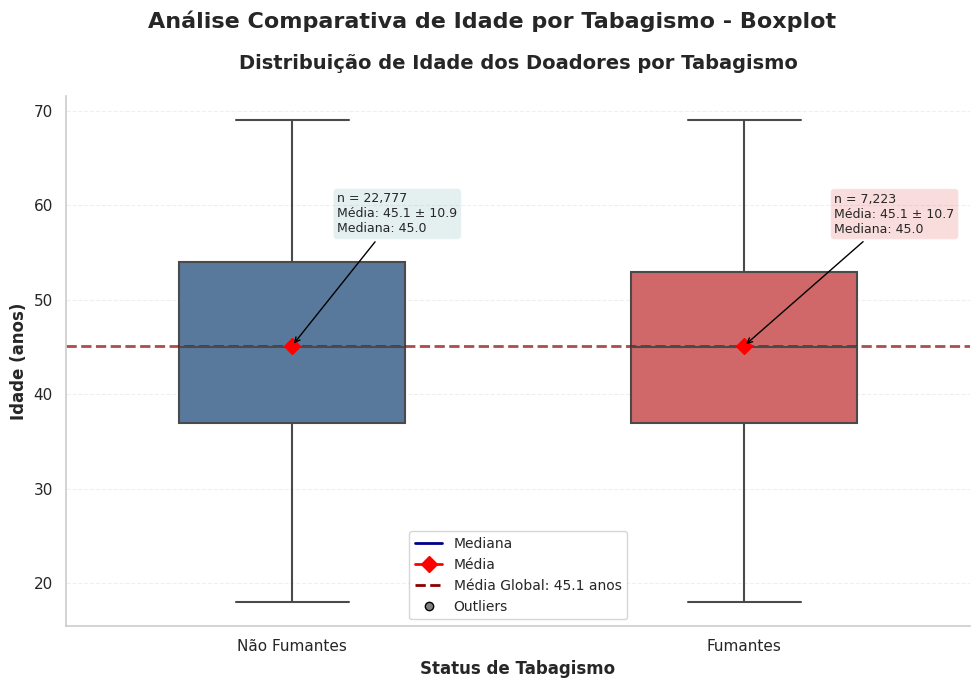

In [ ]:
media_fum = dataset_fumantes['age'].mean()
media_naofum = dataset_nao_fumantes['age'].mean()
mediana_fum = dataset_fumantes['age'].median()
mediana_naofum = dataset_nao_fumantes['age'].median()
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Análise Comparativa de Idade por Tabagismo - Boxplot',
             fontsize=16, fontweight='bold', y=0.98)
sns.boxplot(x='smoker', y='age', data=dataset, palette=cores_fumantes,
            linewidth=1.5, width=0.5, ax=ax, showmeans=True,
            meanprops={'marker': 'D', 'markerfacecolor': 'red',
                       'markeredgecolor': 'red', 'markersize': 8},
            hue='smoker')
ax.set_xticklabels(['Não Fumantes', 'Fumantes'])
ax.set_xlabel('Status de Tabagismo', fontsize=12, fontweight='semibold')
ax.set_ylabel('Idade (anos)', fontsize=12, fontweight='semibold')
ax.set_title('Distribuição de Idade dos Doadores por Tabagismo',
             fontsize=14, fontweight='bold', pad=20)
ax.axhline(y=media_global, color='darkred', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Média Global: {media_global:.1f} anos')
ax.annotate(f'n = {len(dataset_fumantes):,}\nMédia: {media_fum:.1f} ± {dataset_fumantes['age'].std():.1f}\nMediana: {mediana_fum:.1f}',
            xy=(1, media_fum), xytext=(1.2, media_fum + 12),
            ha='left', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#e15759', alpha=0.2),
            arrowprops=dict(arrowstyle='->', color='black', lw=1))
ax.annotate(f'n = {len(dataset_nao_fumantes):,}\nMédia: {media_naofum:.1f} ± {dataset_nao_fumantes['age'].std():.1f}\nMediana: {mediana_naofum:.1f}',
            xy=(0, media_naofum), xytext=(0.1, media_naofum + 12),
            ha='left', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#76b7b2', alpha=0.2),
            arrowprops=dict(arrowstyle='->', color='black', lw=1))

ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
legend_elements = [
    Line2D([0], [0], color='darkblue', linewidth=2, label='Mediana'),
    Line2D([0], [0], color='red', linewidth=2, marker='D', markeredgecolor='red',
           markerfacecolor='red', markersize=8, label='Média'),
    Line2D([0], [0], color='darkred', linestyle='--', linewidth=2, label=f'Média Global: {media_global:.1f} anos'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markeredgecolor='black', markersize=6, label='Outliers')
]
ax.legend(handles=legend_elements, loc='lower center', fontsize=10, frameon=True)
plt.tight_layout()
plt.show()

###Matriz de correlação

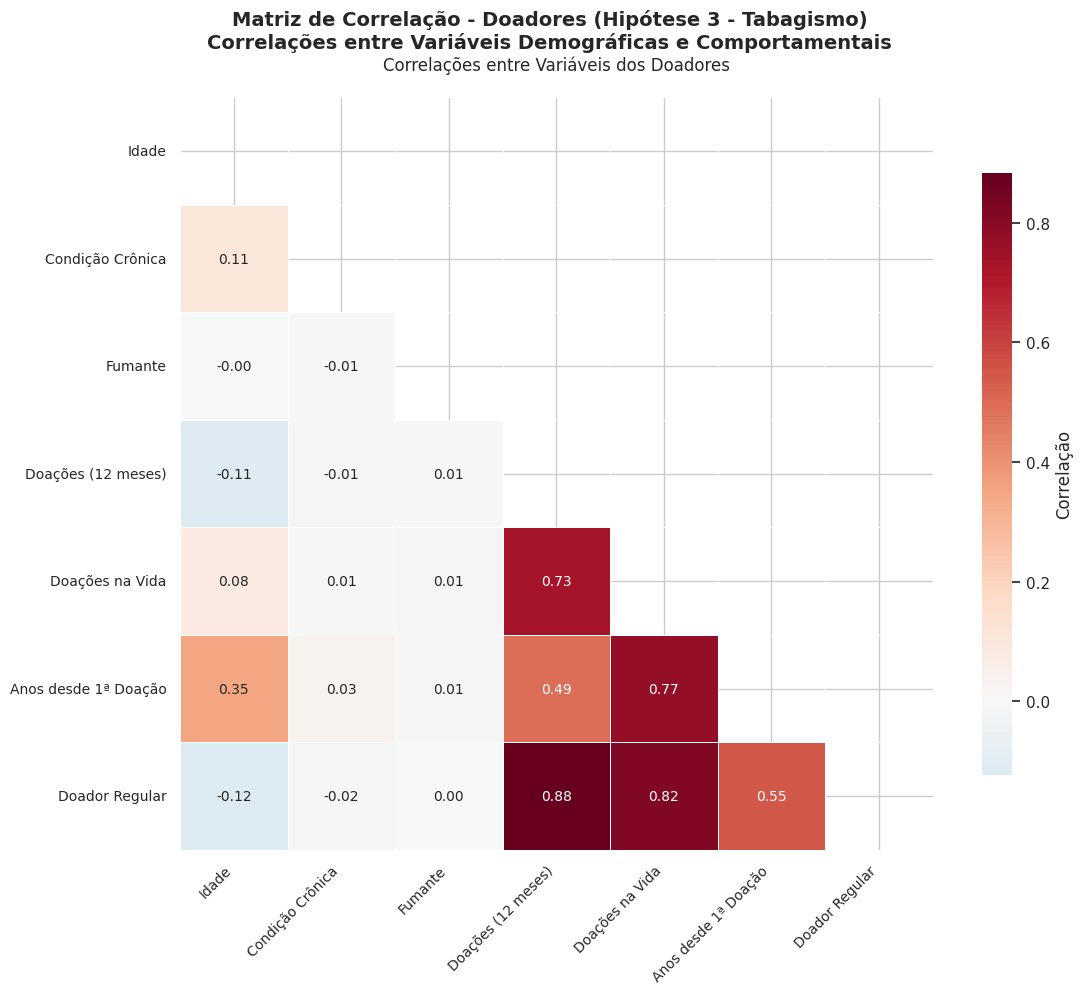

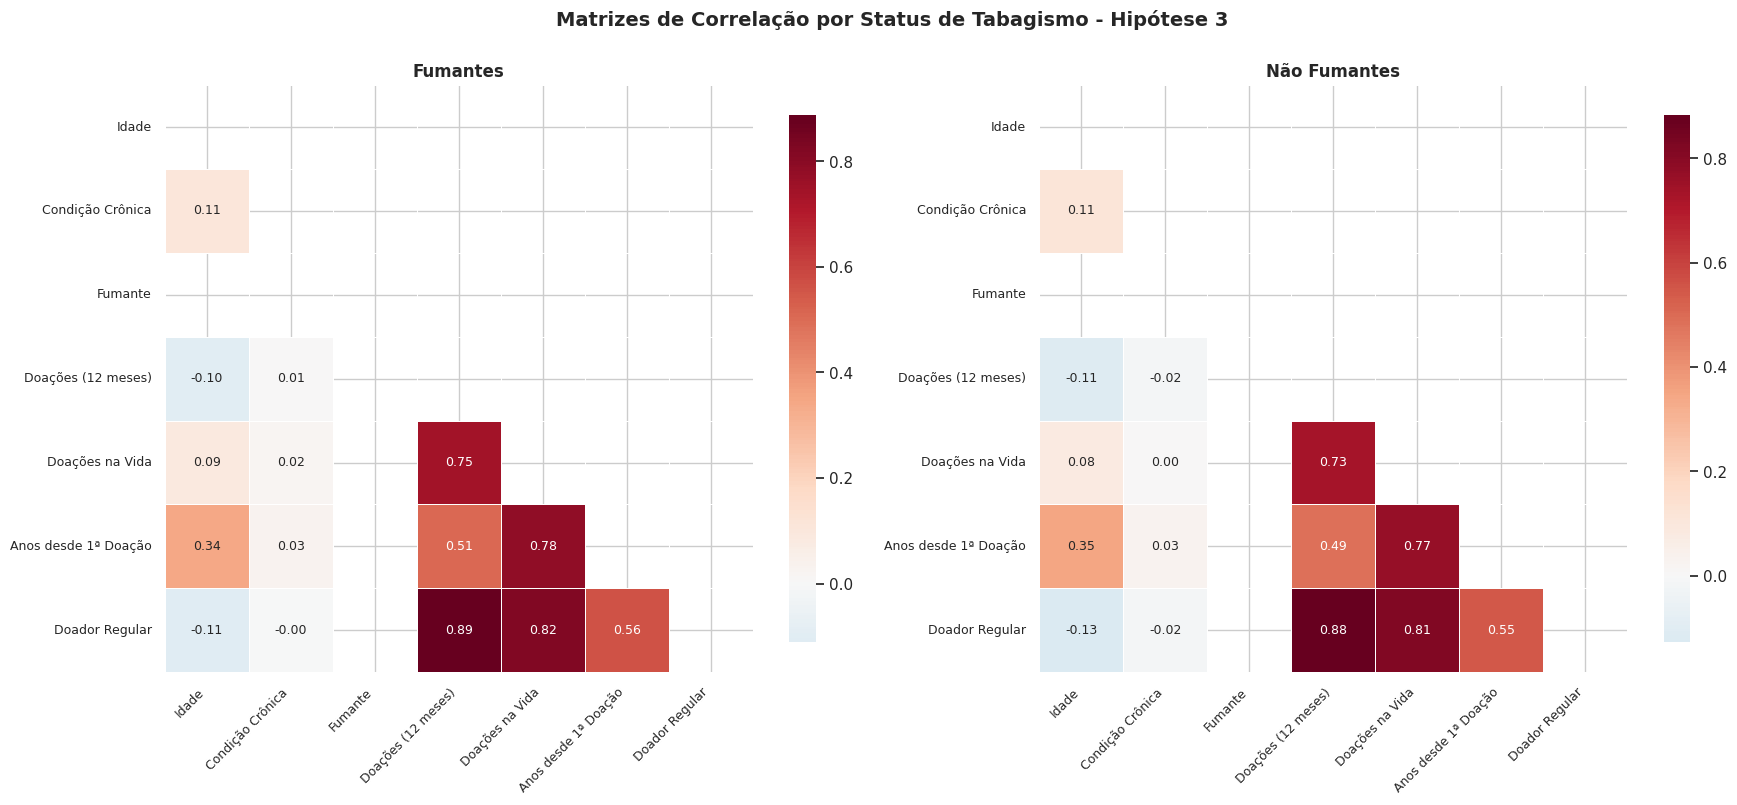

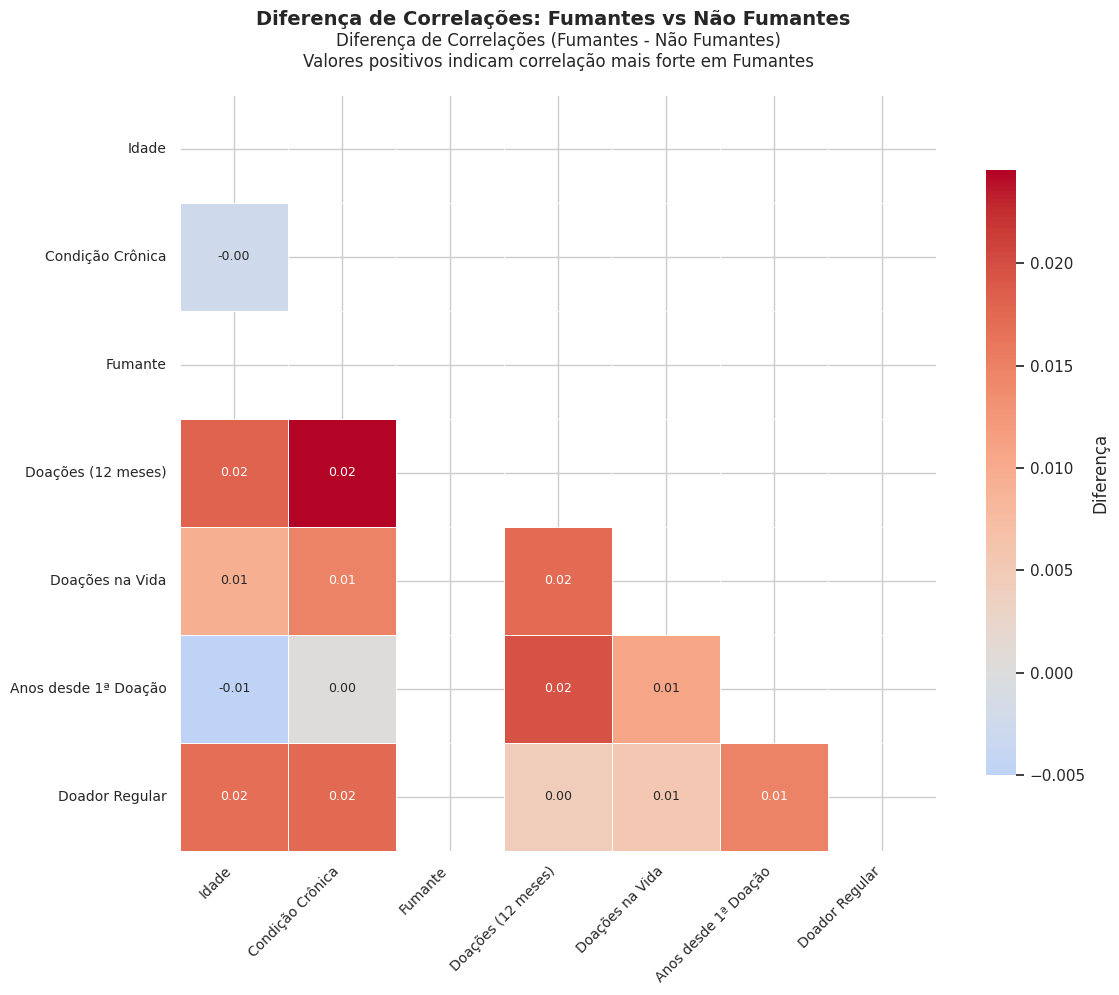

In [ ]:
corr_matrix = dataset[variaveis_existentes].corr()
nomes_traduzidos = [traducao_variaveis.get(var, var) for var in variaveis_existentes]
corr_matrix_traduzida = corr_matrix.copy()
corr_matrix_traduzida.index = nomes_traduzidos
corr_matrix_traduzida.columns = nomes_traduzidos
fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle('Matriz de Correlação - Doadores (Hipótese 3 - Tabagismo)\nCorrelações entre Variáveis Demográficas e Comportamentais',
             fontsize=14, fontweight='bold', y=0.98)
mask = np.triu(np.ones_like(corr_matrix_traduzida, dtype=bool))
sns.heatmap(corr_matrix_traduzida, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Correlação'},
            ax=ax, annot_kws={'size': 10})
ax.set_title('Correlações entre Variáveis dos Doadores', fontsize=12, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

corr_fumantes = dataset_fumantes[variaveis_existentes].corr()
corr_nao_fumantes = dataset_nao_fumantes[variaveis_existentes].corr()
corr_fumantes_traduzida = corr_fumantes.copy()
corr_fumantes_traduzida.index = nomes_traduzidos
corr_fumantes_traduzida.columns = nomes_traduzidos
corr_nao_fumantes_traduzida = corr_nao_fumantes.copy()
corr_nao_fumantes_traduzida.index = nomes_traduzidos
corr_nao_fumantes_traduzida.columns = nomes_traduzidos
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Matrizes de Correlação por Status de Tabagismo - Hipótese 3',
             fontsize=14, fontweight='bold', y=0.98)
mask = np.triu(np.ones_like(corr_fumantes_traduzida, dtype=bool))
sns.heatmap(corr_fumantes_traduzida, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            ax=axes[0], annot_kws={'size': 9})
axes[0].set_title('Fumantes', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=9)
sns.heatmap(corr_nao_fumantes_traduzida, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            ax=axes[1], annot_kws={'size': 9})
axes[1].set_title('Não Fumantes', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

diferenca_correlacoes = corr_fumantes_traduzida - corr_nao_fumantes_traduzida
fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle('Diferença de Correlações: Fumantes vs Não Fumantes',
             fontsize=14, fontweight='bold', y=0.98)
mask = np.triu(np.ones_like(diferenca_correlacoes, dtype=bool))
sns.heatmap(diferenca_correlacoes, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Diferença'},
            ax=ax, annot_kws={'size': 9})
ax.set_title('Diferença de Correlações (Fumantes - Não Fumantes)\nValores positivos indicam correlação mais forte em Fumantes',
             fontsize=12, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

###Tratamento de valores nulos

In [ ]:
nulos = dataset_fumantes.isnull().sum()
nulos = nulos[nulos > 0]
if len(nulos) == 0:
    print("   ✅ Nenhum valor nulo encontrado!")
else:
    for col, val in nulos.items():
        print(f"   • {col}: {val} nulos ({val/len(dataset_fumantes)*100:.2f}%)")
dataset_fumantes = dataset_fumantes.copy()
dataset_fumantes = tratar_nulos(dataset_fumantes, "Hipótese 3")

nulos = dataset_nao_fumantes.isnull().sum()
nulos = nulos[nulos > 0]
if len(nulos) == 0:
    print("   ✅ Nenhum valor nulo encontrado!")
else:
    for col, val in nulos.items():
        print(f"   • {col}: {val} nulos ({val/len(dataset_nao_fumantes)*100:.2f}%)")
dataset_nao_fumantes = dataset_nao_fumantes.copy()
dataset_nao_fumantes = tratar_nulos(dataset_nao_fumantes, "Hipótese 3")

###Pré-processamento de dados

####Codificação de variáveis

In [ ]:
le_smoker = LabelEncoder()
dataset['smoker_encoded'] = le_smoker.fit_transform(dataset['smoker'].fillna('Desconhecido'))
mapeamento_smoker = dict(zip(le_smoker.classes_, le_smoker.transform(le_smoker.classes_)))
target = 'eligible_to_donate'
target_means_smoker = dataset.groupby('smoker')[target].mean()
dataset['smoker_target_encoded'] = dataset['smoker'].map(target_means_smoker)
onehot_smoker = OneHotEncoder(sparse_output=False, drop='first')
smoker_onehot = onehot_smoker.fit_transform(dataset[['smoker']])
smoker_onehot_colunas = [f'smoker_{c}' for c in onehot_smoker.categories_[0][1:]]
df_smoker_onehot = pd.DataFrame(smoker_onehot, columns=smoker_onehot_colunas, index=dataset.index)
dataset = pd.concat([dataset, df_smoker_onehot], axis=1)

# Criar dicionário com todas as informações
codigos_tabagismo = {
    'Fumantes': {
        'label_encoding': mapeamento_smoker.get(1, -1),
        'target_encoding': target_means_smoker.get(1, 0),
        'one_hot_encoding': 1,
        'total_doadores': len(dataset_fumantes),
        'percentual': len(dataset_fumantes) / len(dataset) * 100,
        'idade_media': dataset_fumantes['age'].mean(),
        'idade_desvio': dataset_fumantes['age'].std(),
        'doacoes_vida_media': dataset_fumantes['lifetime_donation_count'].mean(),
        'doacoes_vida_desvio': dataset_fumantes['lifetime_donation_count'].std(),
        'taxa_regular': dataset_fumantes['is_regular_donor'].mean() * 100,
        'taxa_regular_desvio': dataset_fumantes['is_regular_donor'].std() * 100,
        'elegiveis': dataset_fumantes['eligible_to_donate'].mean() * 100,
        'cond_cronica': dataset_fumantes['chronic_condition_flag'].mean() * 100,
        'doacoes_12m_total': dataset_fumantes['donation_count_last_12m'].sum()
    },
    'Não Fumantes': {
        'label_encoding': mapeamento_smoker.get(0, -1),
        'target_encoding': target_means_smoker.get(0, 0),
        'one_hot_encoding': 0,
        'total_doadores': len(dataset_nao_fumantes),
        'percentual': len(dataset_nao_fumantes) / len(dataset) * 100,
        'idade_media': dataset_nao_fumantes['age'].mean(),
        'idade_desvio': dataset_nao_fumantes['age'].std(),
        'doacoes_vida_media': dataset_nao_fumantes['lifetime_donation_count'].mean(),
        'doacoes_vida_desvio': dataset_nao_fumantes['lifetime_donation_count'].std(),
        'taxa_regular': dataset_nao_fumantes['is_regular_donor'].mean() * 100,
        'taxa_regular_desvio': dataset_nao_fumantes['is_regular_donor'].std() * 100,
        'elegiveis': dataset_nao_fumantes['eligible_to_donate'].mean() * 100,
        'cond_cronica': dataset_nao_fumantes['chronic_condition_flag'].mean() * 100,
        'doacoes_12m_total': dataset_nao_fumantes['donation_count_last_12m'].sum()
    }
}

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')
ax.axis('tight')
tabela_data = [
    ['Fumantes',
     codigos_tabagismo['Fumantes']['label_encoding'],
     f"{codigos_tabagismo['Fumantes']['target_encoding']:.4f}",
     codigos_tabagismo['Fumantes']['one_hot_encoding'],
     f"{codigos_tabagismo['Fumantes']['total_doadores']:,}",
     f"{codigos_tabagismo['Fumantes']['percentual']:.1f}%",
     f"{codigos_tabagismo['Fumantes']['idade_media']:.1f} ± {codigos_tabagismo['Fumantes']['idade_desvio']:.1f}",
     f"{codigos_tabagismo['Fumantes']['doacoes_vida_media']:.1f} ± {codigos_tabagismo['Fumantes']['doacoes_vida_desvio']:.1f}",
     f"{codigos_tabagismo['Fumantes']['taxa_regular']:.1f}% ± {codigos_tabagismo['Fumantes']['taxa_regular_desvio']:.1f}",
     f"{codigos_tabagismo['Fumantes']['elegiveis']:.1f}%",
     f"{codigos_tabagismo['Fumantes']['cond_cronica']:.1f}%",
     f"{int(codigos_tabagismo['Fumantes']['doacoes_12m_total']):,}"],

    ['Não Fumantes',
     codigos_tabagismo['Não Fumantes']['label_encoding'],
     f"{codigos_tabagismo['Não Fumantes']['target_encoding']:.4f}",
     codigos_tabagismo['Não Fumantes']['one_hot_encoding'],
     f"{codigos_tabagismo['Não Fumantes']['total_doadores']:,}",
     f"{codigos_tabagismo['Não Fumantes']['percentual']:.1f}%",
     f"{codigos_tabagismo['Não Fumantes']['idade_media']:.1f} ± {codigos_tabagismo['Não Fumantes']['idade_desvio']:.1f}",
     f"{codigos_tabagismo['Não Fumantes']['doacoes_vida_media']:.1f} ± {codigos_tabagismo['Não Fumantes']['doacoes_vida_desvio']:.1f}",
     f"{codigos_tabagismo['Não Fumantes']['taxa_regular']:.1f}% ± {codigos_tabagismo['Não Fumantes']['taxa_regular_desvio']:.1f}",
     f"{codigos_tabagismo['Não Fumantes']['elegiveis']:.1f}%",
     f"{codigos_tabagismo['Não Fumantes']['cond_cronica']:.1f}%",
     f"{int(codigos_tabagismo['Não Fumantes']['doacoes_12m_total']):,}"]
]
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Status', 'Label Enc', 'Target Enc', 'One-Hot',
                             'Total Doadores', '% Total', 'Idade (anos)',
                             'Doações Vida', 'Doadores Regulares',
                             '% Elegíveis', '% Cond. Crônica', 'Doações (12m)'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2',
                              '#59a14f', '#af7aa1', '#ff9f4a', '#edc949',
                              '#9c9c9c', '#6c6c6c', '#4e79a7', '#e15759'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1.2, 1.6)
plt.title('Codificação de Variáveis - Análise de Tabagismo (Hipótese 3)\n' +
          'Label Encoding, Target Encoding e One-Hot Encoding',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 10))
ax.axis('off')
ax.axis('tight')
tabela_data_invertida = [
    ['Label Encoding',
     codigos_tabagismo['Fumantes']['label_encoding'],
     codigos_tabagismo['Não Fumantes']['label_encoding']],
    ['Target Encoding',
     f"{codigos_tabagismo['Fumantes']['target_encoding']:.4f}",
     f"{codigos_tabagismo['Não Fumantes']['target_encoding']:.4f}"],
    ['One-Hot Encoding (smoker_1)',
     codigos_tabagismo['Fumantes']['one_hot_encoding'],
     codigos_tabagismo['Não Fumantes']['one_hot_encoding']],
    ['Total de Doadores',
     f"{codigos_tabagismo['Fumantes']['total_doadores']:,}",
     f"{codigos_tabagismo['Não Fumantes']['total_doadores']:,}"],
    ['Percentual do Total',
     f"{codigos_tabagismo['Fumantes']['percentual']:.1f}%",
     f"{codigos_tabagismo['Não Fumantes']['percentual']:.1f}%"],
    ['Idade Média (anos)',
     f"{codigos_tabagismo['Fumantes']['idade_media']:.1f} ± {codigos_tabagismo['Fumantes']['idade_desvio']:.1f}",
     f"{codigos_tabagismo['Não Fumantes']['idade_media']:.1f} ± {codigos_tabagismo['Não Fumantes']['idade_desvio']:.1f}"],
    ['Doações na Vida',
     f"{codigos_tabagismo['Fumantes']['doacoes_vida_media']:.1f} ± {codigos_tabagismo['Fumantes']['doacoes_vida_desvio']:.1f}",
     f"{codigos_tabagismo['Não Fumantes']['doacoes_vida_media']:.1f} ± {codigos_tabagismo['Não Fumantes']['doacoes_vida_desvio']:.1f}"],
    ['Doadores Regulares (%)',
     f"{codigos_tabagismo['Fumantes']['taxa_regular']:.1f}% ± {codigos_tabagismo['Fumantes']['taxa_regular_desvio']:.1f}",
     f"{codigos_tabagismo['Não Fumantes']['taxa_regular']:.1f}% ± {codigos_tabagismo['Não Fumantes']['taxa_regular_desvio']:.1f}"],
    ['Elegíveis para Doar (%)',
     f"{codigos_tabagismo['Fumantes']['elegiveis']:.1f}%",
     f"{codigos_tabagismo['Não Fumantes']['elegiveis']:.1f}%"],
    ['Condição Crônica (%)',
     f"{codigos_tabagismo['Fumantes']['cond_cronica']:.1f}%",
     f"{codigos_tabagismo['Não Fumantes']['cond_cronica']:.1f}%"],
    ['Doações nos Últimos 12 Meses',
     f"{int(codigos_tabagismo['Fumantes']['doacoes_12m_total']):,}",
     f"{int(codigos_tabagismo['Não Fumantes']['doacoes_12m_total']):,}"]
]
tabela_invertida = ax.table(cellText=tabela_data_invertida,
                            colLabels=['Métrica', 'Fumantes', 'Não Fumantes'],
                            cellLoc='center',
                            loc='center',
                            colColours=['#4e79a7', '#e15759', '#76b7b2'])
tabela_invertida.auto_set_font_size(False)
tabela_invertida.set_fontsize(10)
tabela_invertida.scale(1.2, 1.6)
plt.title('Codificação de Variáveis - Análise de Tabagismo (Hipótese 3)\n' +
          'Resumo de Codificações e Estatísticas',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

####Normalização e padronização

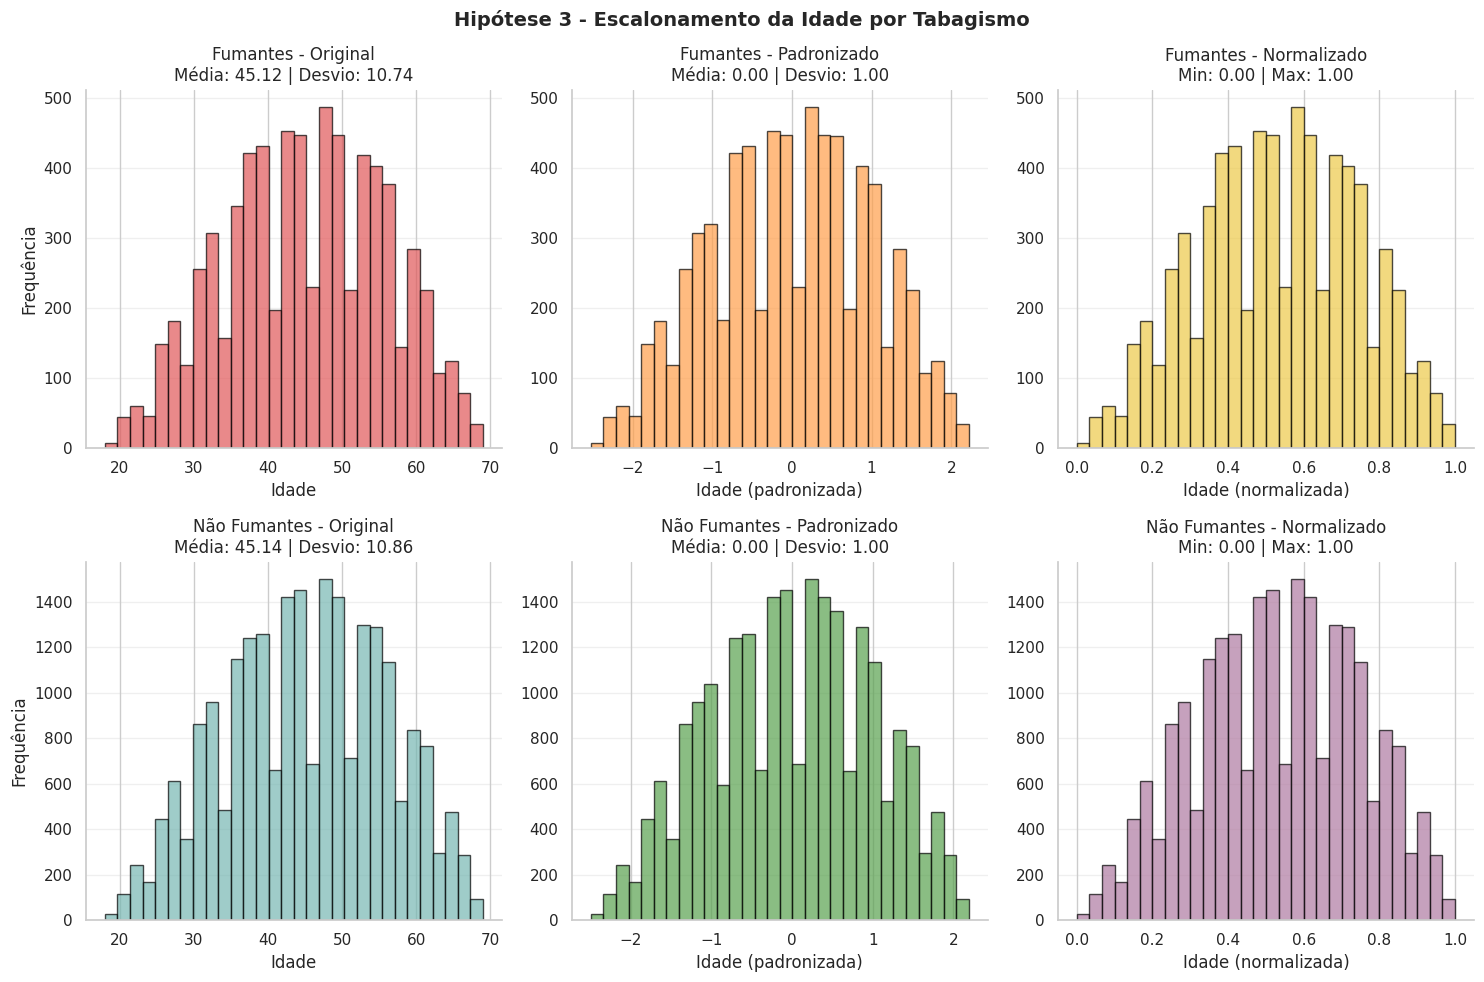

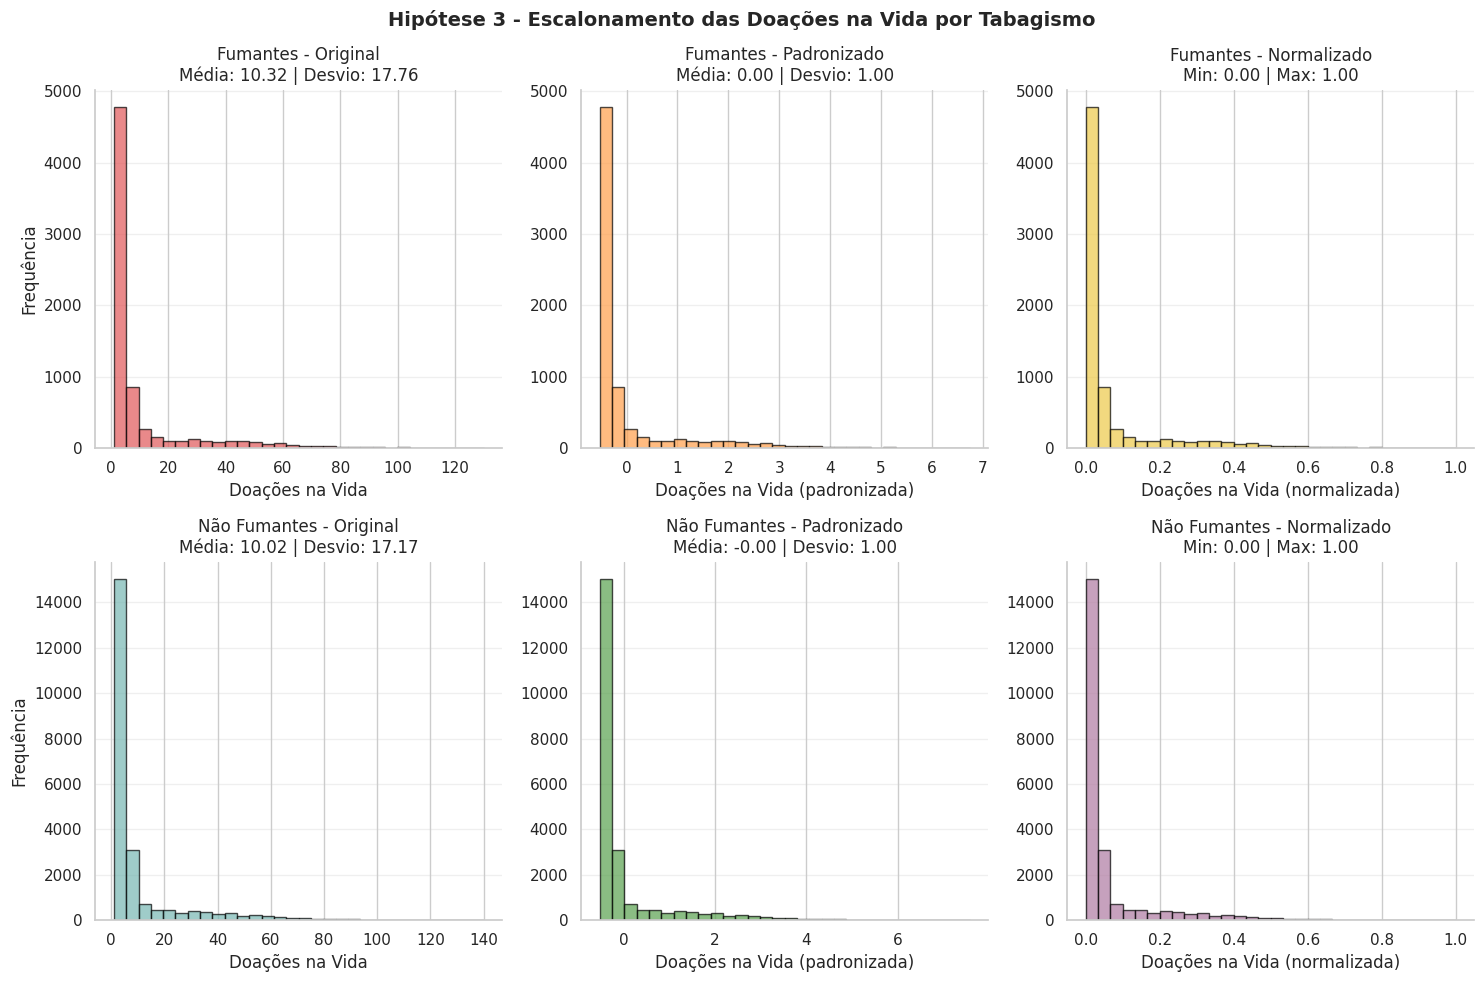

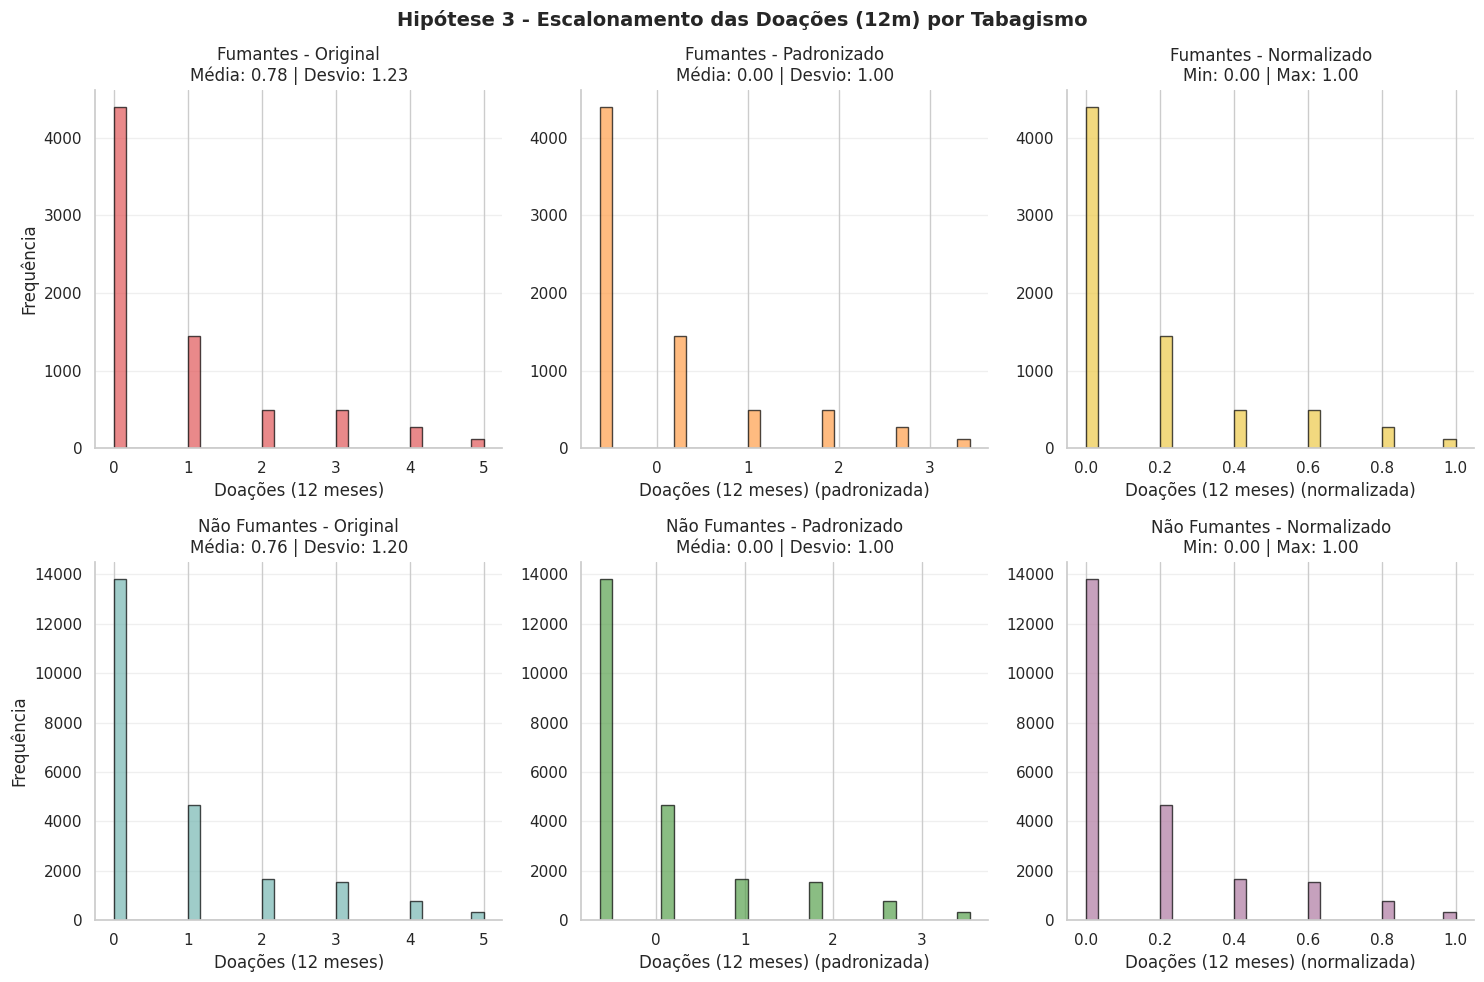

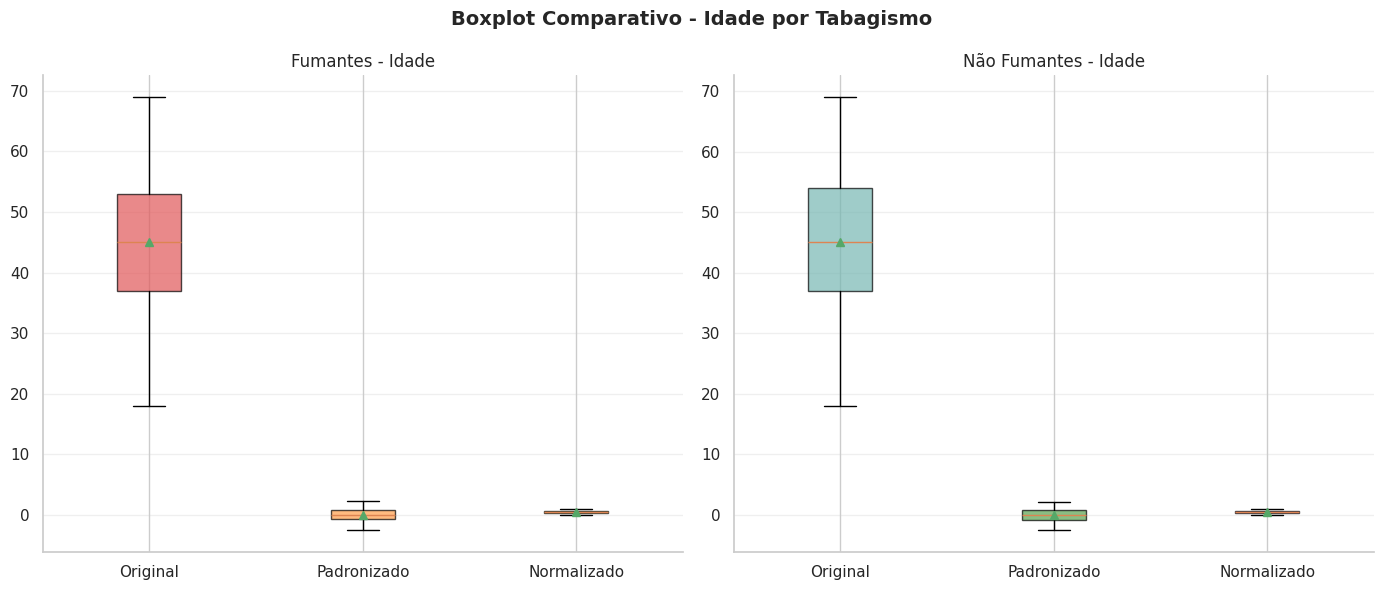

In [ ]:
coluna_fumante = 'smoker' if 'smoker' in dataset.columns else 'fumante' if 'fumante' in dataset.columns else None
scaler_std_fum = StandardScaler()
scaler_minmax_fum = MinMaxScaler()
scaler_robust_fum = RobustScaler()
scaler_std_naofum = StandardScaler()
scaler_minmax_naofum = MinMaxScaler()
scaler_robust_naofum = RobustScaler()
dataset_fum_original = dataset_fumantes.copy()
dataset_fum_padronizado = dataset_fumantes.copy()
dataset_fum_normalizado = dataset_fumantes.copy()
dataset_fum_robust = dataset_fumantes.copy()
dataset_naofum_original = dataset_nao_fumantes.copy()
dataset_naofum_padronizado = dataset_nao_fumantes.copy()
dataset_naofum_normalizado = dataset_nao_fumantes.copy()
dataset_naofum_robust = dataset_nao_fumantes.copy()
if len(dataset_fumantes) > 0 and len(variaveis_existentes) > 0:
    dataset_fum_padronizado[variaveis_existentes] = scaler_std_fum.fit_transform(dataset_fumantes[variaveis_existentes])
    dataset_fum_normalizado[variaveis_existentes] = scaler_minmax_fum.fit_transform(dataset_fumantes[variaveis_existentes])
    dataset_fum_robust[variaveis_existentes] = scaler_robust_fum.fit_transform(dataset_fumantes[variaveis_existentes])
if len(dataset_nao_fumantes) > 0 and len(variaveis_existentes) > 0:
    dataset_naofum_padronizado[variaveis_existentes] = scaler_std_naofum.fit_transform(dataset_nao_fumantes[variaveis_existentes])
    dataset_naofum_normalizado[variaveis_existentes] = scaler_minmax_naofum.fit_transform(dataset_nao_fumantes[variaveis_existentes])
    dataset_naofum_robust[variaveis_existentes] = scaler_robust_naofum.fit_transform(dataset_nao_fumantes[variaveis_existentes])

def plot_hist_comparativo_tabagismo(aDataset_fum, aDataset_naofum,
                                    aDataset_fum_pad, aDataset_naofum_pad,
                                    aDataset_fum_norm, aDataset_naofum_norm,
                                    coluna, titulo):
    nome_pt = traducao_variaveis.get(coluna, coluna)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(titulo, fontsize=14, fontweight='bold')
    ax = axes[0, 0]
    ax.hist(aDataset_fum[coluna], bins=30, color='#e15759', edgecolor='black', alpha=0.7)
    ax.set_title(f'Fumantes - Original\nMédia: {aDataset_fum[coluna].mean():.2f} | Desvio: {aDataset_fum[coluna].std():.2f}')
    ax.set_xlabel(nome_pt)
    ax.set_ylabel('Frequência')
    ax.grid(axis='y', alpha=0.3)
    ax = axes[0, 1]
    ax.hist(aDataset_fum_pad[coluna], bins=30, color='#ff9f4a', edgecolor='black', alpha=0.7)
    ax.set_title(f'Fumantes - Padronizado\nMédia: {aDataset_fum_pad[coluna].mean():.2f} | Desvio: {aDataset_fum_pad[coluna].std():.2f}')
    ax.set_xlabel(nome_pt + ' (padronizada)')
    ax.grid(axis='y', alpha=0.3)
    ax = axes[0, 2]
    ax.hist(aDataset_fum_norm[coluna], bins=30, color='#edc949', edgecolor='black', alpha=0.7)
    ax.set_title(f'Fumantes - Normalizado\nMin: {aDataset_fum_norm[coluna].min():.2f} | Max: {aDataset_fum_norm[coluna].max():.2f}')
    ax.set_xlabel(nome_pt + ' (normalizada)')
    ax.grid(axis='y', alpha=0.3)
    ax = axes[1, 0]
    ax.hist(aDataset_naofum[coluna], bins=30, color='#76b7b2', edgecolor='black', alpha=0.7)
    ax.set_title(f'Não Fumantes - Original\nMédia: {aDataset_naofum[coluna].mean():.2f} | Desvio: {aDataset_naofum[coluna].std():.2f}')
    ax.set_xlabel(nome_pt)
    ax.set_ylabel('Frequência')
    ax.grid(axis='y', alpha=0.3)
    ax = axes[1, 1]
    ax.hist(aDataset_naofum_pad[coluna], bins=30, color='#59a14f', edgecolor='black', alpha=0.7)
    ax.set_title(f'Não Fumantes - Padronizado\nMédia: {aDataset_naofum_pad[coluna].mean():.2f} | Desvio: {aDataset_naofum_pad[coluna].std():.2f}')
    ax.set_xlabel(nome_pt + ' (padronizada)')
    ax.grid(axis='y', alpha=0.3)
    ax = axes[1, 2]
    ax.hist(aDataset_naofum_norm[coluna], bins=30, color='#af7aa1', edgecolor='black', alpha=0.7)
    ax.set_title(f'Não Fumantes - Normalizado\nMin: {aDataset_naofum_norm[coluna].min():.2f} | Max: {aDataset_naofum_norm[coluna].max():.2f}')
    ax.set_xlabel(nome_pt + ' (normalizada)')
    ax.grid(axis='y', alpha=0.3)
    for ax in axes.flat:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

if 'age' in variaveis_existentes:
    plot_hist_comparativo_tabagismo(
        dataset_fum_original, dataset_naofum_original,
        dataset_fum_padronizado, dataset_naofum_padronizado,
        dataset_fum_normalizado, dataset_naofum_normalizado,
        'age',
        'Hipótese 3 - Escalonamento da Idade por Tabagismo'
    )
if 'lifetime_donation_count' in variaveis_existentes:
    plot_hist_comparativo_tabagismo(
        dataset_fum_original, dataset_naofum_original,
        dataset_fum_padronizado, dataset_naofum_padronizado,
        dataset_fum_normalizado, dataset_naofum_normalizado,
        'lifetime_donation_count',
        'Hipótese 3 - Escalonamento das Doações na Vida por Tabagismo'
    )
if 'donation_count_last_12m' in variaveis_existentes:
    plot_hist_comparativo_tabagismo(
        dataset_fum_original, dataset_naofum_original,
        dataset_fum_padronizado, dataset_naofum_padronizado,
        dataset_fum_normalizado, dataset_naofum_normalizado,
        'donation_count_last_12m',
        'Hipótese 3 - Escalonamento das Doações (12m) por Tabagismo'
    )

def plot_boxplot_comparativo(aDataset_fum, aDataset_naofum,
                             aDataset_fum_pad, aDataset_naofum_pad,
                             aDataset_fum_norm, aDataset_naofum_norm,
                             coluna, titulo):
    nome_pt = traducao_variaveis.get(coluna, coluna)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(titulo, fontsize=14, fontweight='bold')
    ax1 = axes[0]
    dados_fum = [aDataset_fum[coluna].values, aDataset_fum_pad[coluna].values, aDataset_fum_norm[coluna].values]
    bp1 = ax1.boxplot(dados_fum, tick_labels=['Original', 'Padronizado', 'Normalizado'],
                      patch_artist=True, showmeans=True)
    cores = ['#e15759', '#ff9f4a', '#edc949']
    for patch, cor in zip(bp1['boxes'], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
    ax1.set_title(f'Fumantes - {nome_pt}')
    ax1.grid(axis='y', alpha=0.3)
    ax2 = axes[1]
    dados_naofum = [aDataset_naofum[coluna].values, aDataset_naofum_pad[coluna].values, aDataset_naofum_norm[coluna].values]
    bp2 = ax2.boxplot(dados_naofum, tick_labels=['Original', 'Padronizado', 'Normalizado'],
                      patch_artist=True, showmeans=True)
    cores = ['#76b7b2', '#59a14f', '#af7aa1']
    for patch, cor in zip(bp2['boxes'], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
    ax2.set_title(f'Não Fumantes - {nome_pt}')
    ax2.grid(axis='y', alpha=0.3)
    for ax in [ax1, ax2]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
if 'age' in variaveis_existentes:
    plot_boxplot_comparativo(
        dataset_fum_original, dataset_naofum_original,
        dataset_fum_padronizado, dataset_naofum_padronizado,
        dataset_fum_normalizado, dataset_naofum_normalizado,
        'age',
        'Boxplot Comparativo - Idade por Tabagismo'
    )

####Tratamento de outliers

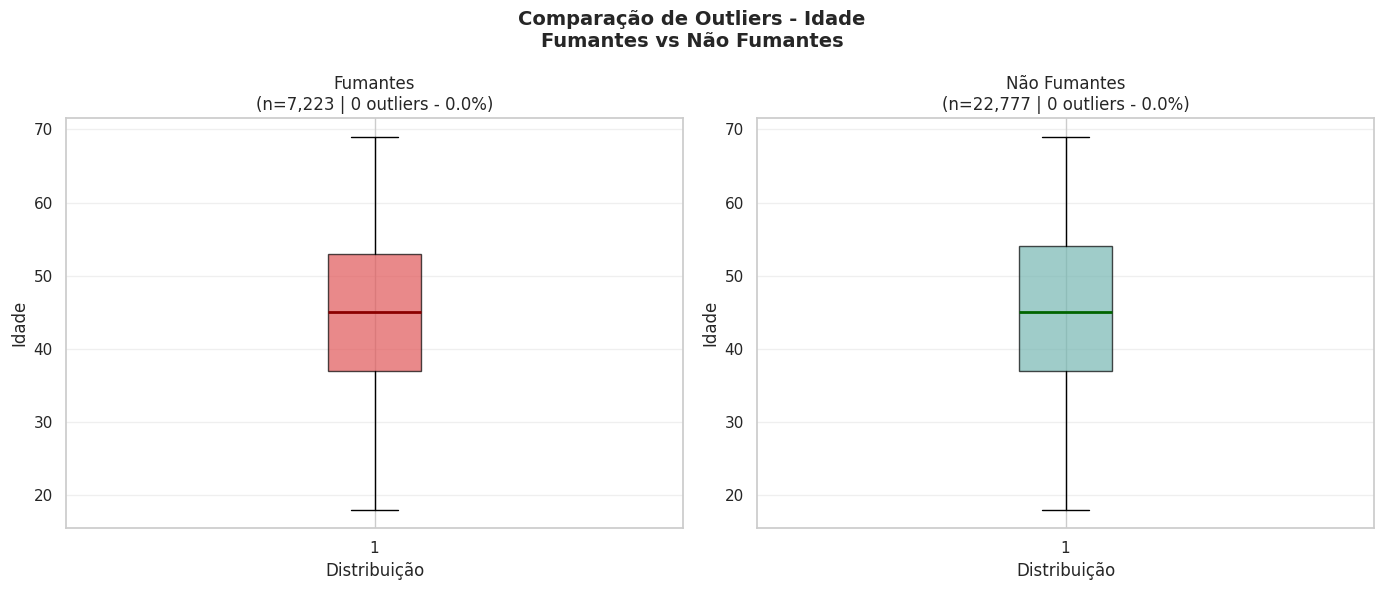

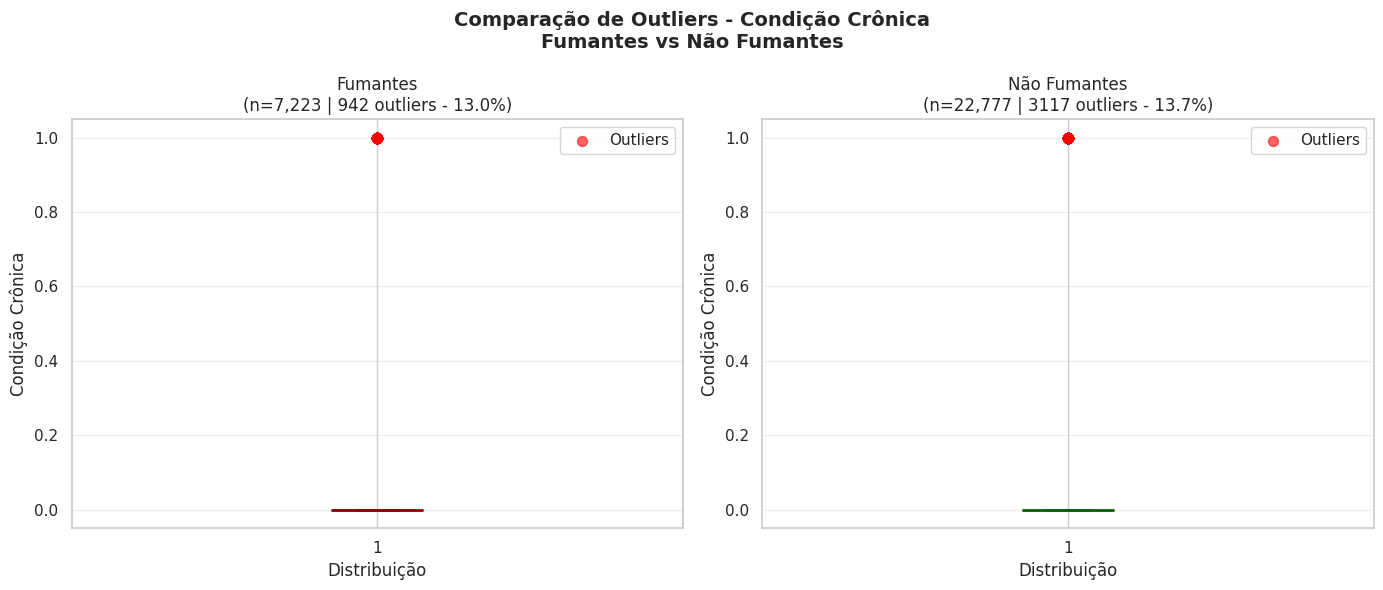

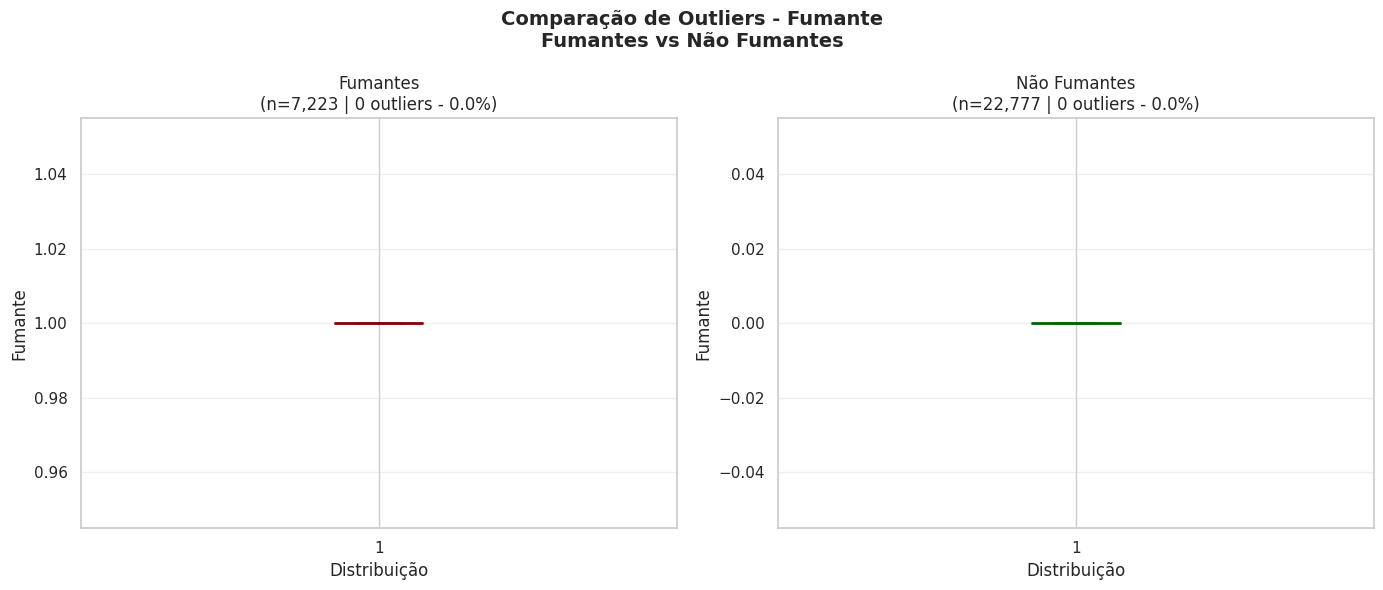

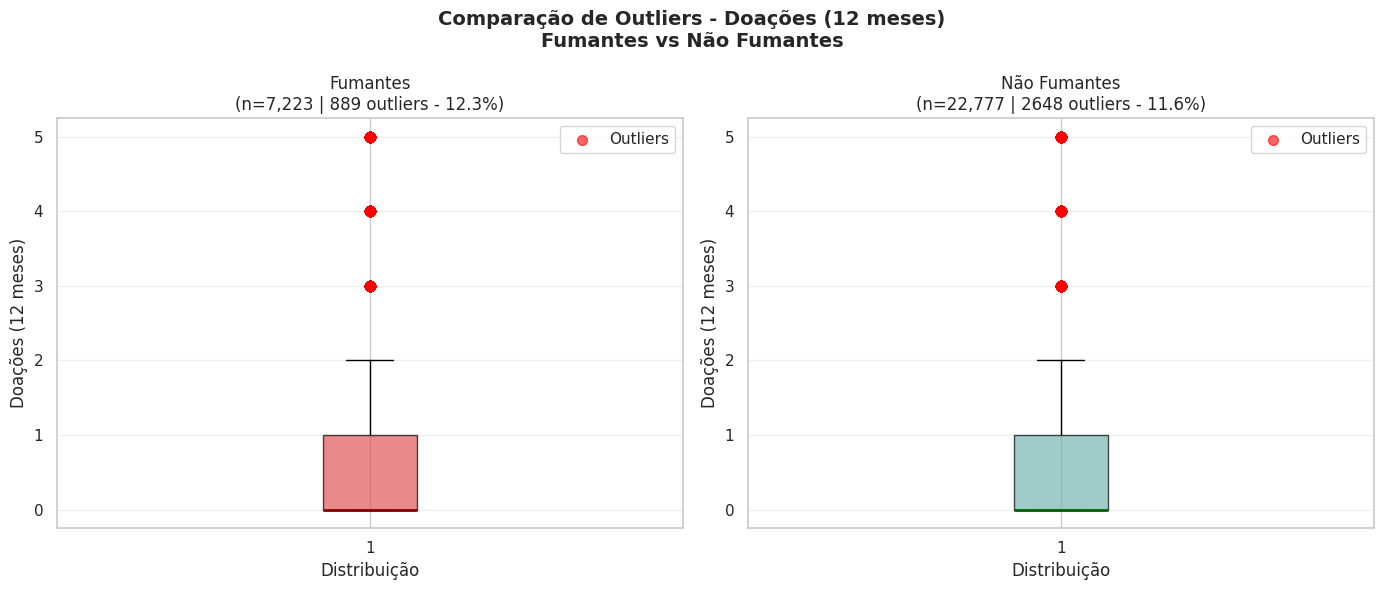

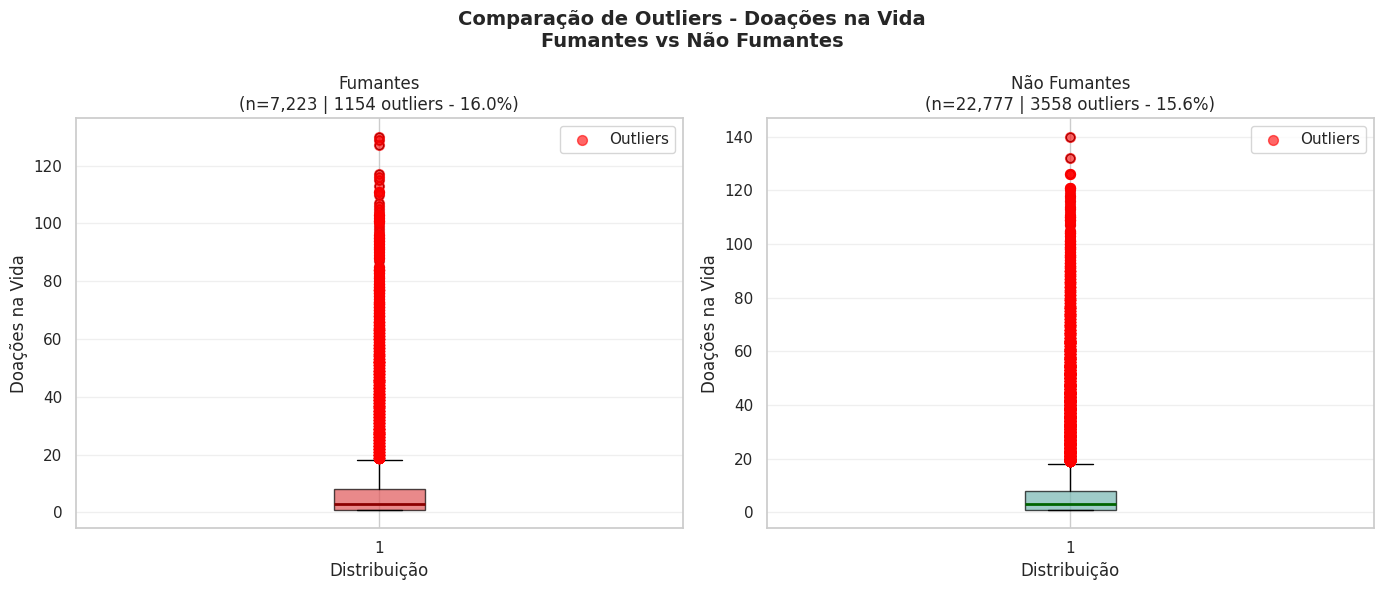

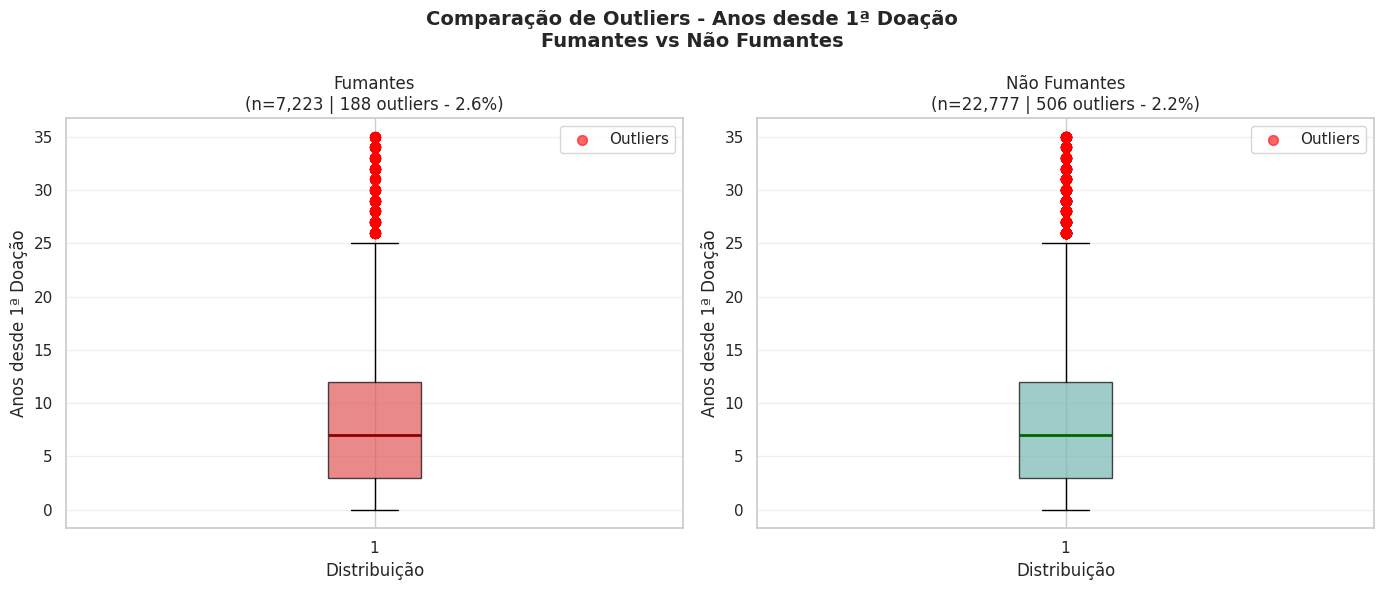

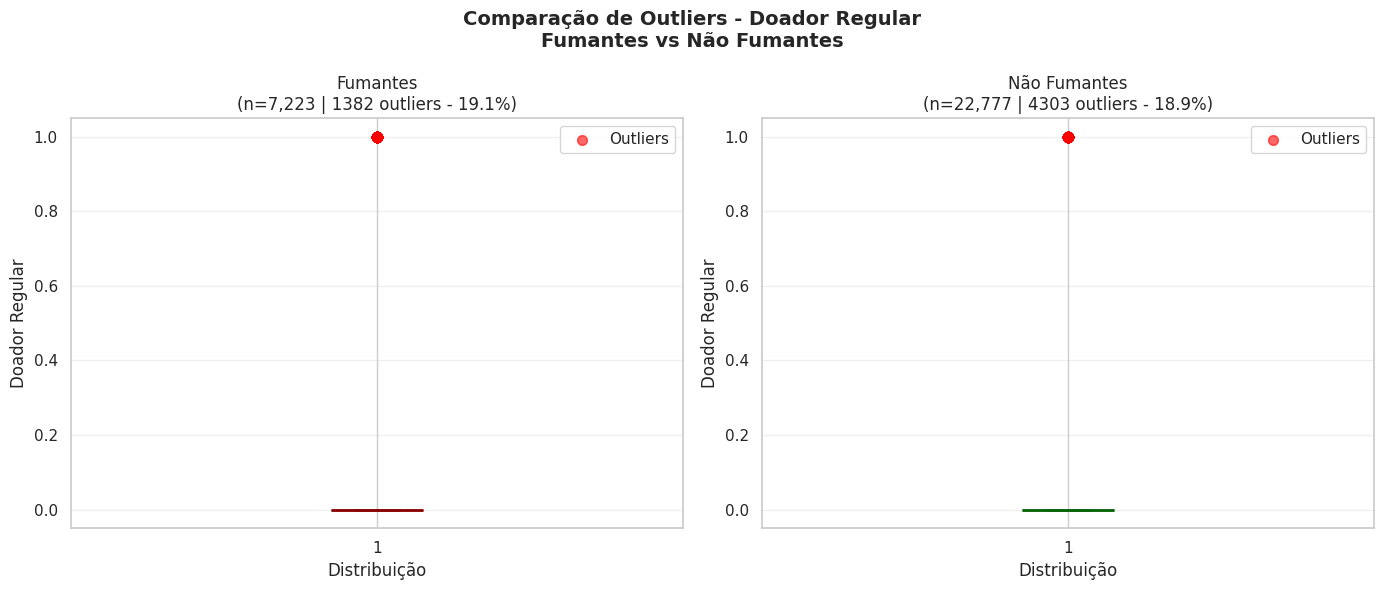

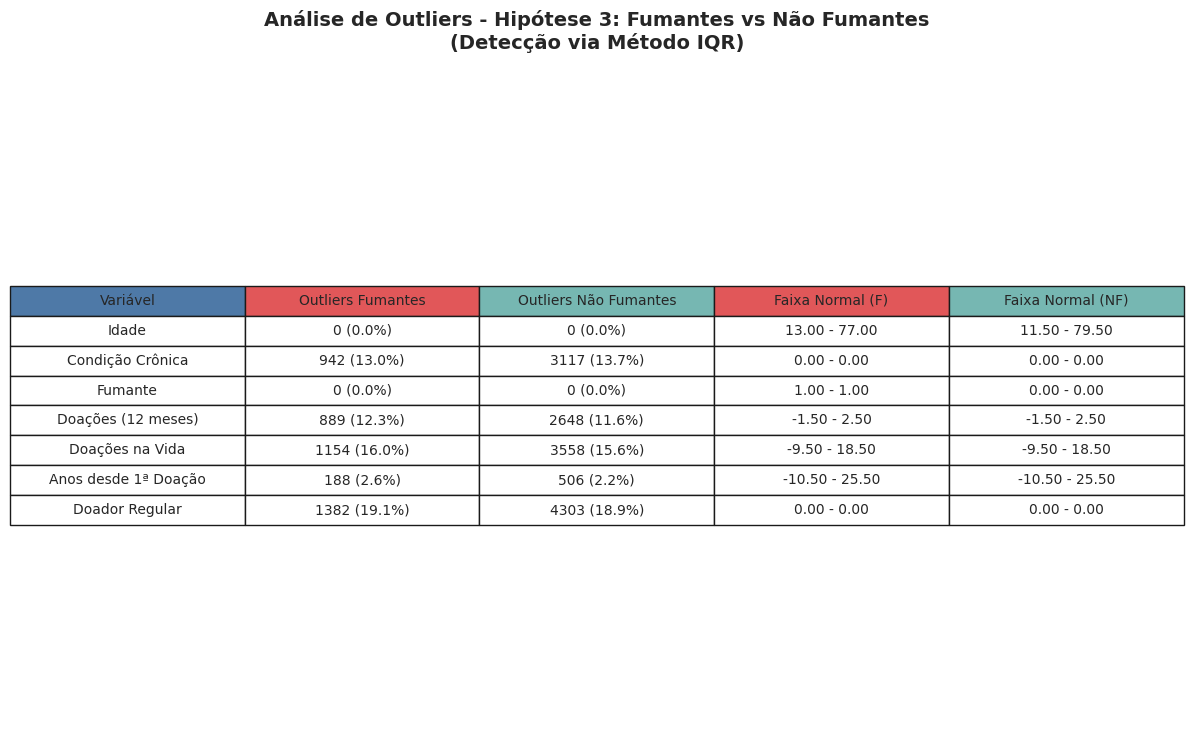

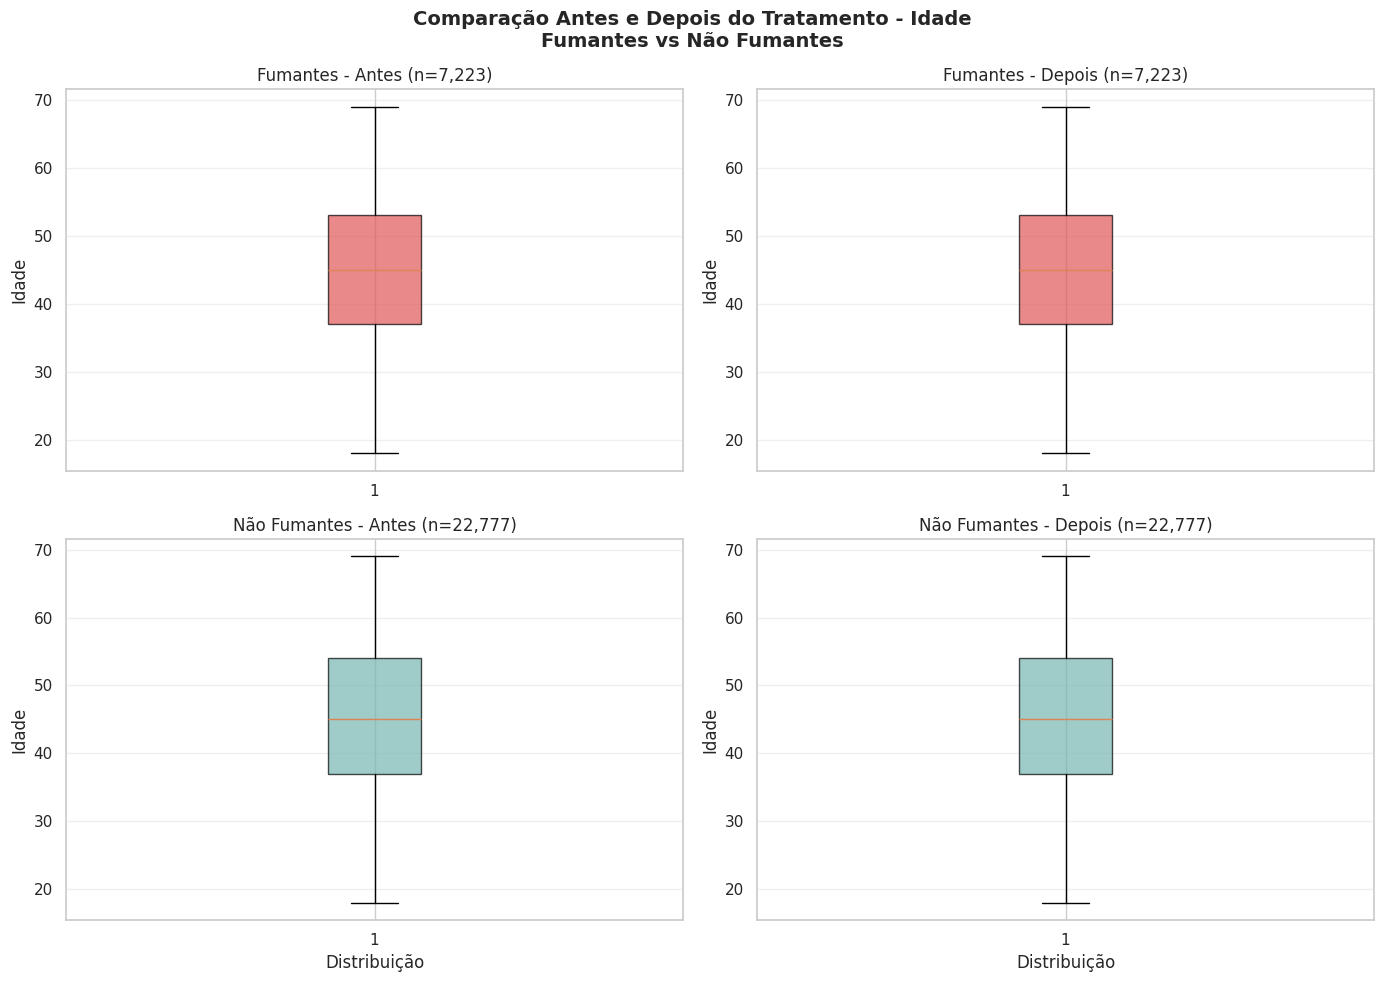

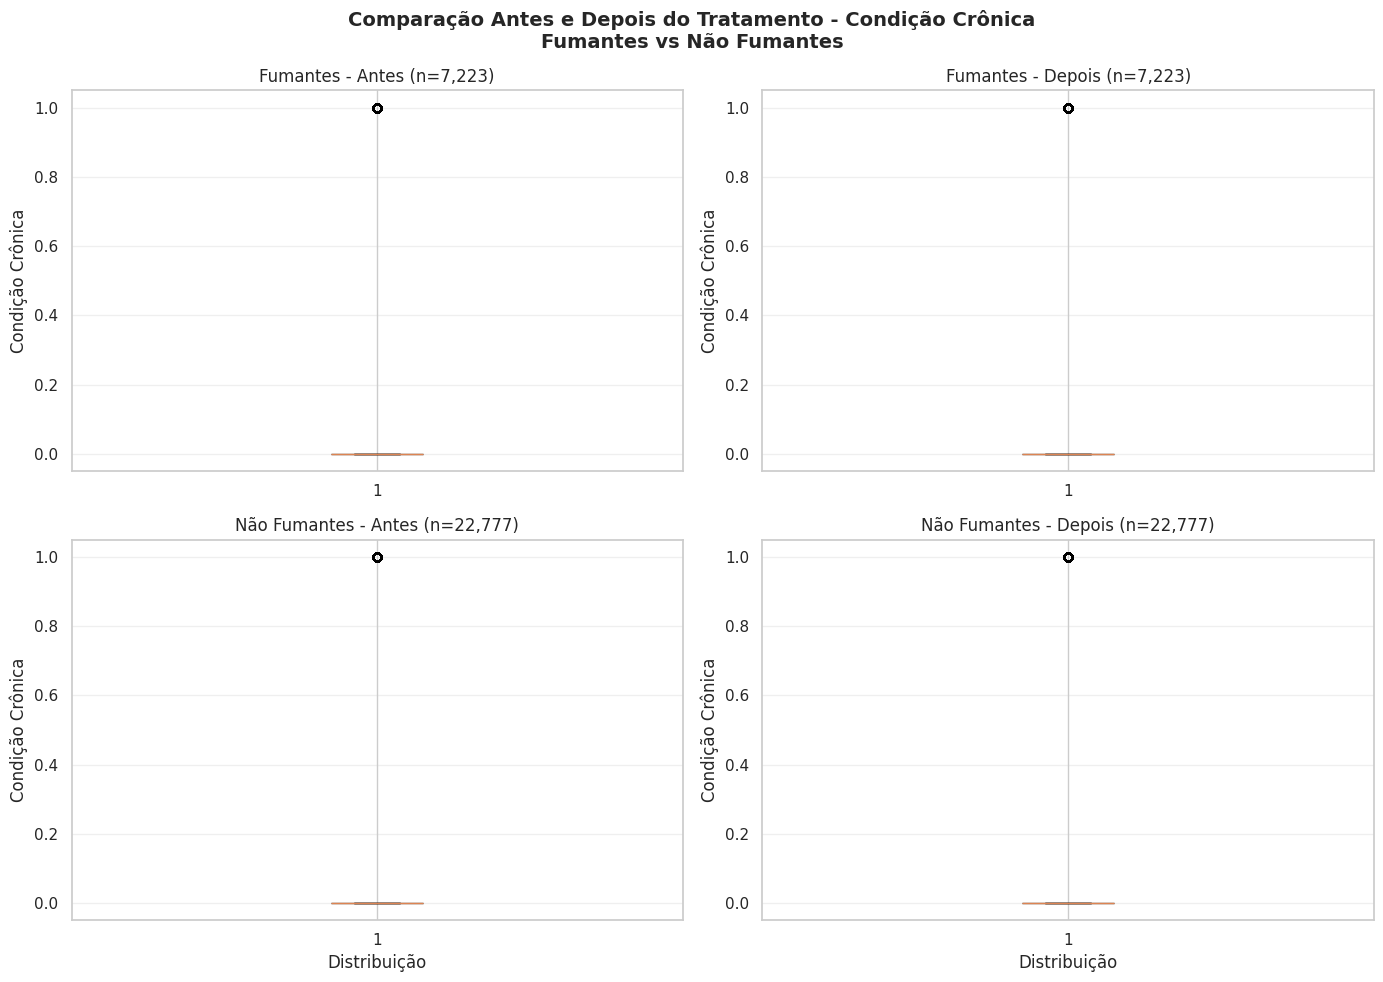

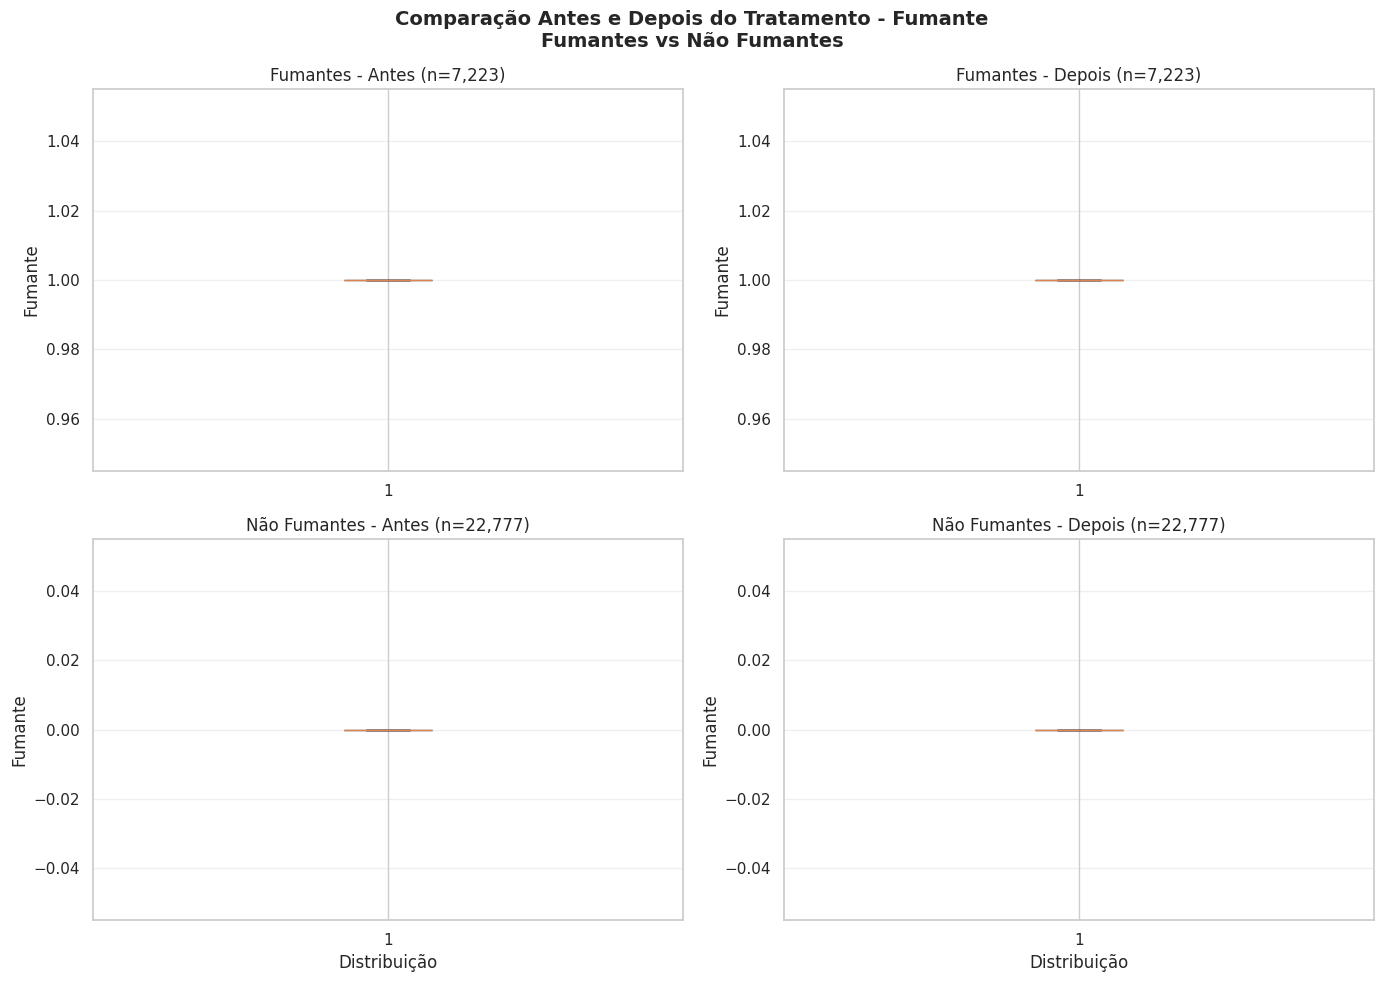

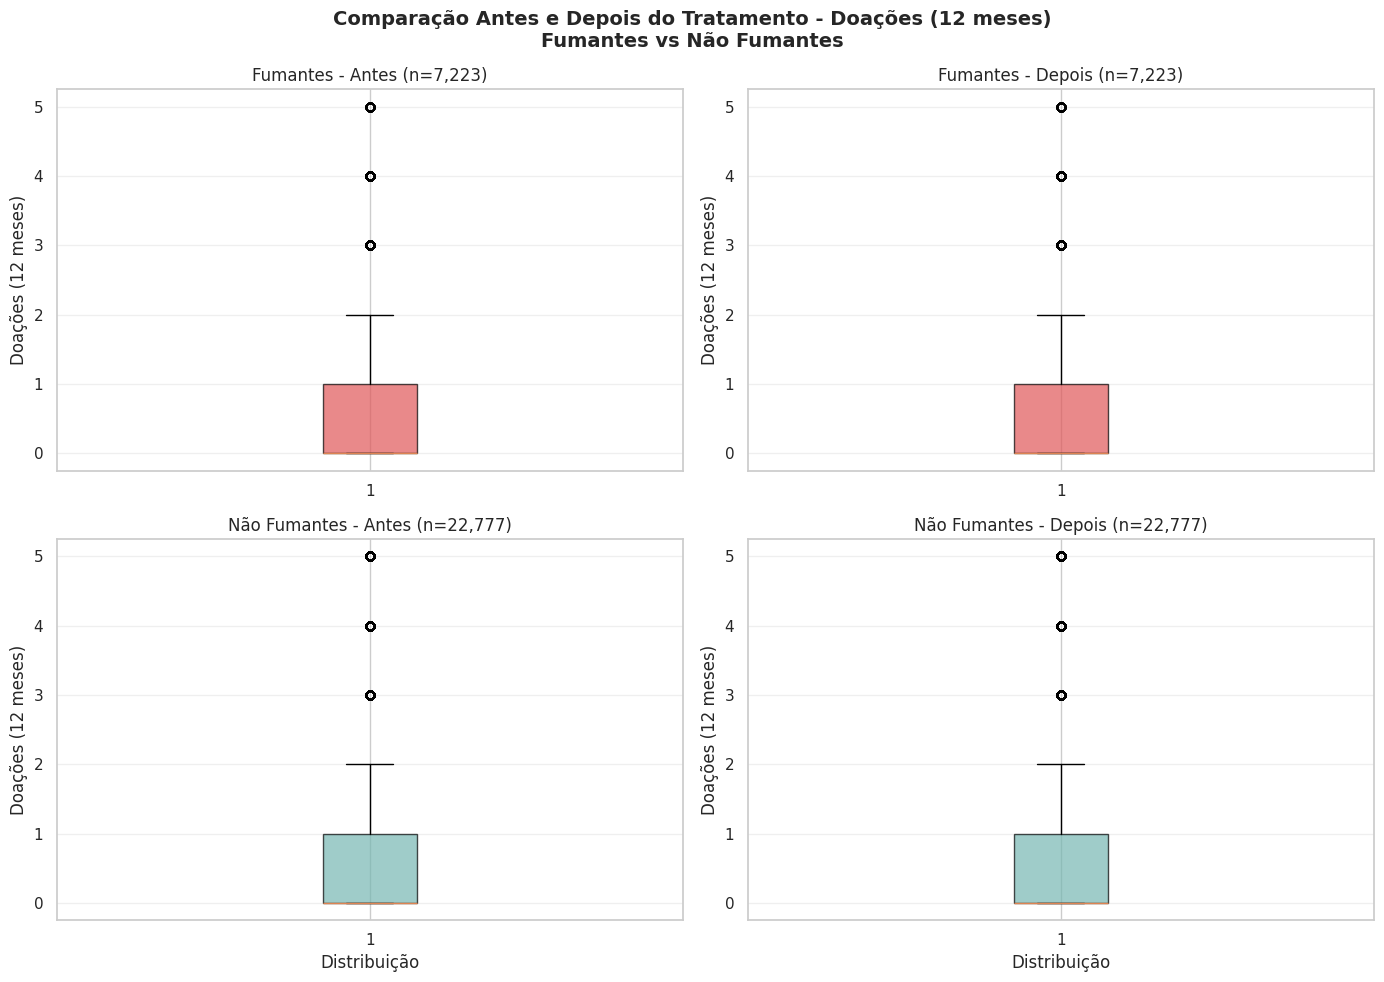

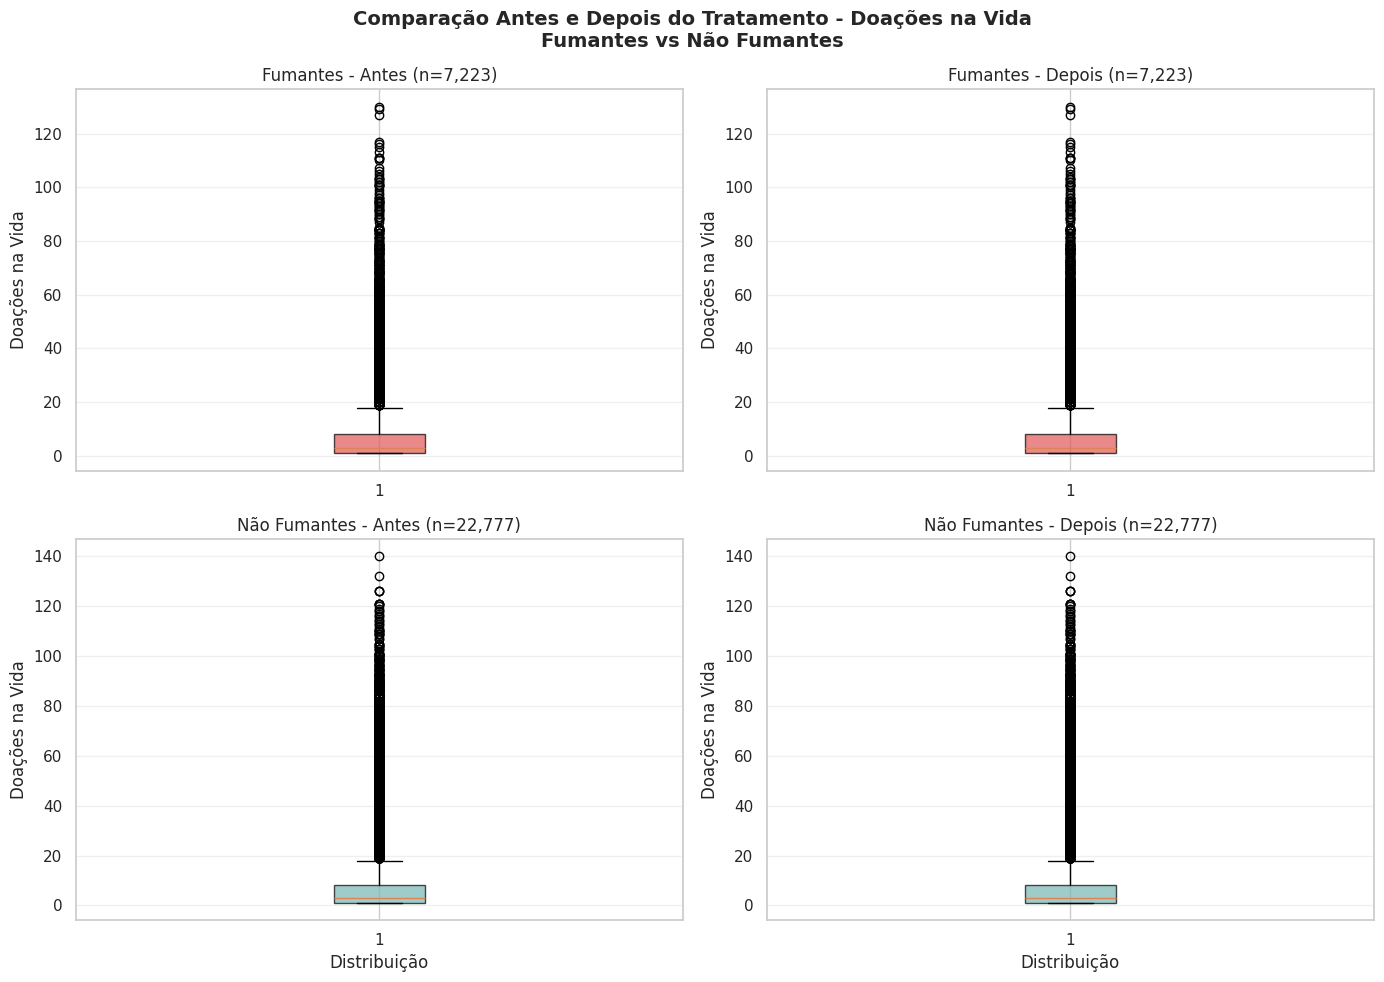

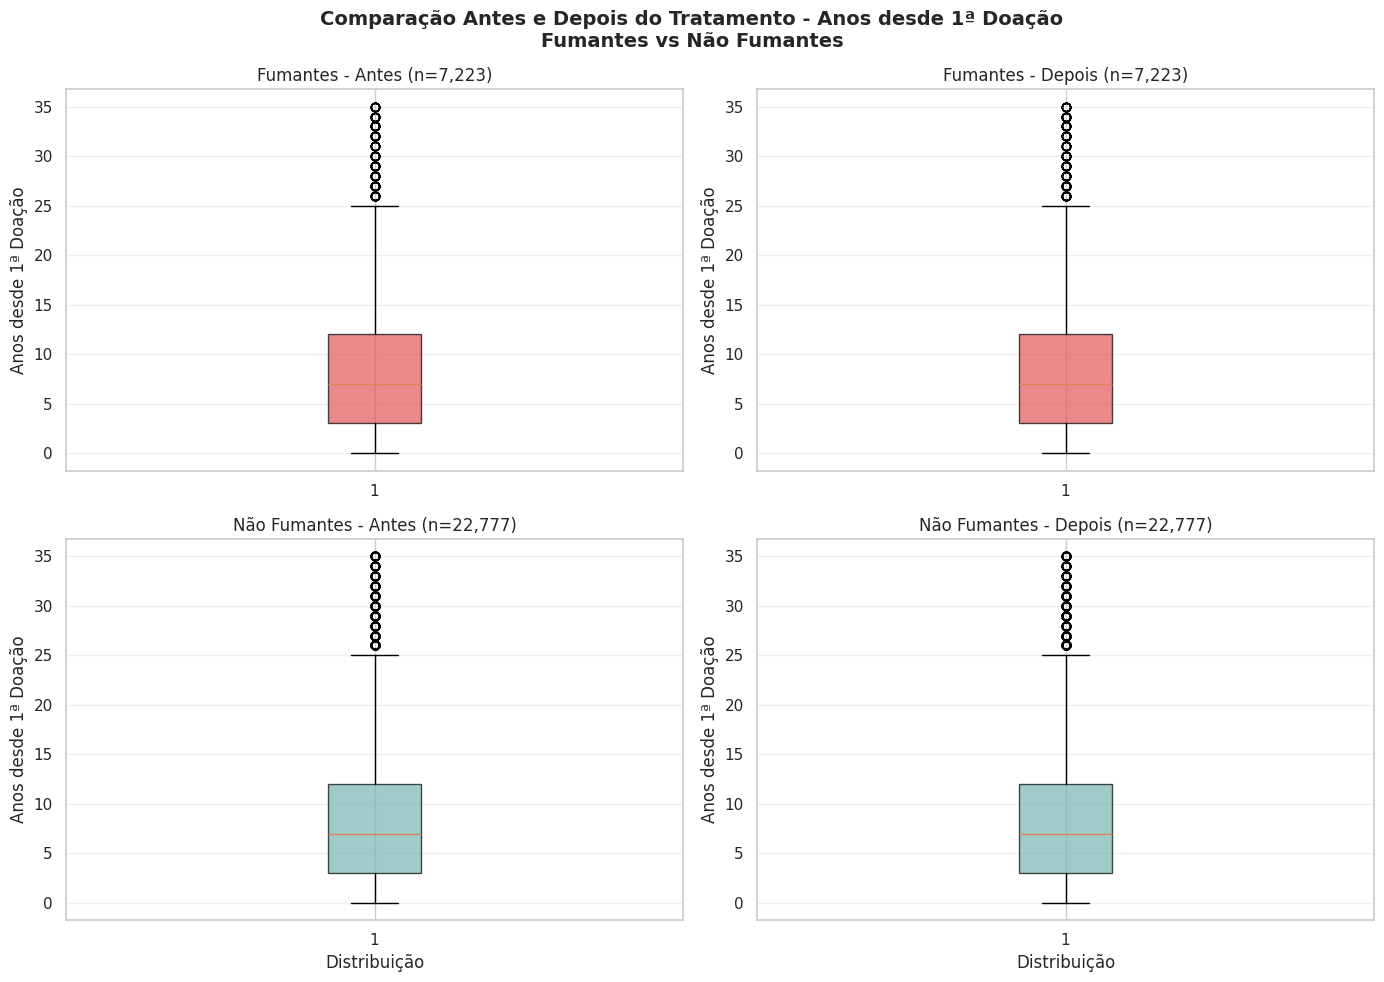

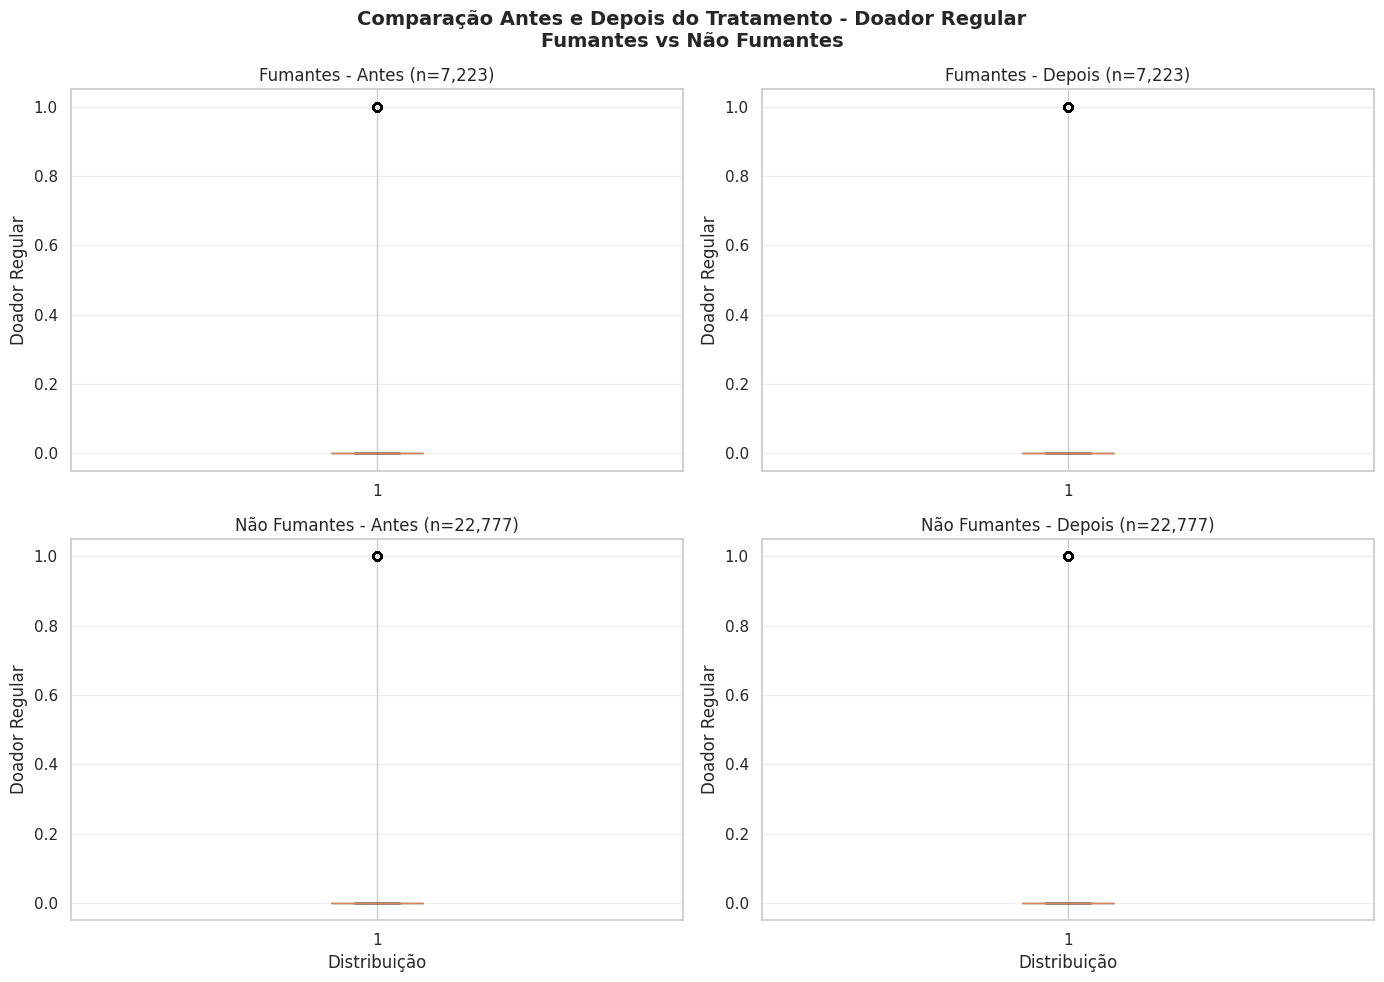

In [ ]:
outliers_info = {
    'Fumantes': {},
    'Não Fumantes': {}
}

for var in variaveis_existentes:
    var_trad = traducao_variaveis.get(var, var)
    outliers_f, li_f, ls_f = detectar_outliers_iqr(dataset_fumantes, var)
    outliers_info['Fumantes'][var_trad] = {
        'quantidade': len(outliers_f),
        'percentual': (len(outliers_f) / len(dataset_fumantes) * 100) if len(dataset_fumantes) > 0 else 0,
        'limite_inferior': li_f,
        'limite_superior': ls_f
    }
    outliers_nf, li_nf, ls_nf = detectar_outliers_iqr(dataset_nao_fumantes, var)
    outliers_info['Não Fumantes'][var_trad] = {
        'quantidade': len(outliers_nf),
        'percentual': (len(outliers_nf) / len(dataset_nao_fumantes) * 100) if len(dataset_nao_fumantes) > 0 else 0,
        'limite_inferior': li_nf,
        'limite_superior': ls_nf
    }

for var in variaveis_existentes:
    var_trad = traducao_variaveis.get(var, var)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Comparação de Outliers - {var_trad}\nFumantes vs Não Fumantes',
                 fontsize=14, fontweight='bold')
    ax1 = axes[0]
    outliers_f, _, _ = detectar_outliers_iqr(dataset_fumantes, var)
    bp1 = ax1.boxplot(dataset_fumantes[var].dropna(), patch_artist=True)
    bp1['boxes'][0].set_facecolor('#e15759')
    bp1['boxes'][0].set_alpha(0.7)
    bp1['medians'][0].set_color('darkred')
    bp1['medians'][0].set_linewidth(2)
    if len(outliers_f) > 0:
        ax1.scatter(np.ones(len(outliers_f)) * 1, outliers_f[var],
                   color='red', s=50, alpha=0.6, label='Outliers', zorder=3)
    ax1.set_title(f'Fumantes\n(n={len(dataset_fumantes):,} | {len(outliers_f)} outliers - {len(outliers_f)/len(dataset_fumantes)*100:.1f}%)')
    ax1.set_ylabel(var_trad)
    ax1.set_xlabel('Distribuição')
    ax1.grid(axis='y', alpha=0.3)
    if len(outliers_f) > 0:
        ax1.legend(loc='upper right')
    ax2 = axes[1]
    outliers_nf, _, _ = detectar_outliers_iqr(dataset_nao_fumantes, var)
    bp2 = ax2.boxplot(dataset_nao_fumantes[var].dropna(), patch_artist=True)
    bp2['boxes'][0].set_facecolor('#76b7b2')
    bp2['boxes'][0].set_alpha(0.7)
    bp2['medians'][0].set_color('darkgreen')
    bp2['medians'][0].set_linewidth(2)
    if len(outliers_nf) > 0:
        ax2.scatter(np.ones(len(outliers_nf)) * 1, outliers_nf[var],
                   color='red', s=50, alpha=0.6, label='Outliers', zorder=3)
    ax2.set_title(f'Não Fumantes\n(n={len(dataset_nao_fumantes):,} | {len(outliers_nf)} outliers - {len(outliers_nf)/len(dataset_nao_fumantes)*100:.1f}%)')
    ax2.set_ylabel(var_trad)
    ax2.set_xlabel('Distribuição')
    ax2.grid(axis='y', alpha=0.3)
    if len(outliers_nf) > 0:
        ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(12, len(variaveis_existentes) * 0.8 + 2))
ax.axis('off')
ax.axis('tight')
tabela_data = []
for var in variaveis_existentes:
    var_trad = traducao_variaveis.get(var, var)
    tabela_data.append([
        var_trad,
        f"{outliers_info['Fumantes'][var_trad]['quantidade']} ({outliers_info['Fumantes'][var_trad]['percentual']:.1f}%)",
        f"{outliers_info['Não Fumantes'][var_trad]['quantidade']} ({outliers_info['Não Fumantes'][var_trad]['percentual']:.1f}%)",
        f"{outliers_info['Fumantes'][var_trad]['limite_inferior']:.2f} - {outliers_info['Fumantes'][var_trad]['limite_superior']:.2f}",
        f"{outliers_info['Não Fumantes'][var_trad]['limite_inferior']:.2f} - {outliers_info['Não Fumantes'][var_trad]['limite_superior']:.2f}"
    ])
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Variável', 'Outliers Fumantes', 'Outliers Não Fumantes',
                             'Faixa Normal (F)', 'Faixa Normal (NF)'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#e15759', '#76b7b2', '#e15759', '#76b7b2'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.6)
plt.title('Análise de Outliers - Hipótese 3: Fumantes vs Não Fumantes\n(Detecção via Método IQR)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

for var in variaveis_existentes:
    var_trad = traducao_variaveis.get(var, var)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Comparação Antes e Depois do Tratamento - {var_trad}\nFumantes vs Não Fumantes',
                 fontsize=14, fontweight='bold')
    ax1 = axes[0, 0]
    bp1 = ax1.boxplot(dataset_fumantes[var].dropna(), patch_artist=True)
    bp1['boxes'][0].set_facecolor('#e15759')
    bp1['boxes'][0].set_alpha(0.7)
    ax1.set_title(f'Fumantes - Antes (n={len(dataset_fumantes):,})')
    ax1.set_ylabel(var_trad)
    ax1.grid(axis='y', alpha=0.3)
    ax2 = axes[0, 1]
    bp2 = ax2.boxplot(dataset_fumantes[var].dropna(), patch_artist=True)
    bp2['boxes'][0].set_facecolor('#e15759')
    bp2['boxes'][0].set_alpha(0.7)
    ax2.set_title(f'Fumantes - Depois (n={len(dataset_fumantes):,})')
    ax2.set_ylabel(var_trad)
    ax2.grid(axis='y', alpha=0.3)
    ax3 = axes[1, 0]
    bp3 = ax3.boxplot(dataset_nao_fumantes[var].dropna(), patch_artist=True)
    bp3['boxes'][0].set_facecolor('#76b7b2')
    bp3['boxes'][0].set_alpha(0.7)
    ax3.set_title(f'Não Fumantes - Antes (n={len(dataset_nao_fumantes):,})')
    ax3.set_ylabel(var_trad)
    ax3.set_xlabel('Distribuição')
    ax3.grid(axis='y', alpha=0.3)
    ax4 = axes[1, 1]
    bp4 = ax4.boxplot(dataset_nao_fumantes[var].dropna(), patch_artist=True)
    bp4['boxes'][0].set_facecolor('#76b7b2')
    bp4['boxes'][0].set_alpha(0.7)
    ax4.set_title(f'Não Fumantes - Depois (n={len(dataset_nao_fumantes):,})')
    ax4.set_ylabel(var_trad)
    ax4.set_xlabel('Distribuição')
    ax4.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

####Seleção de features (variáveis importantes)

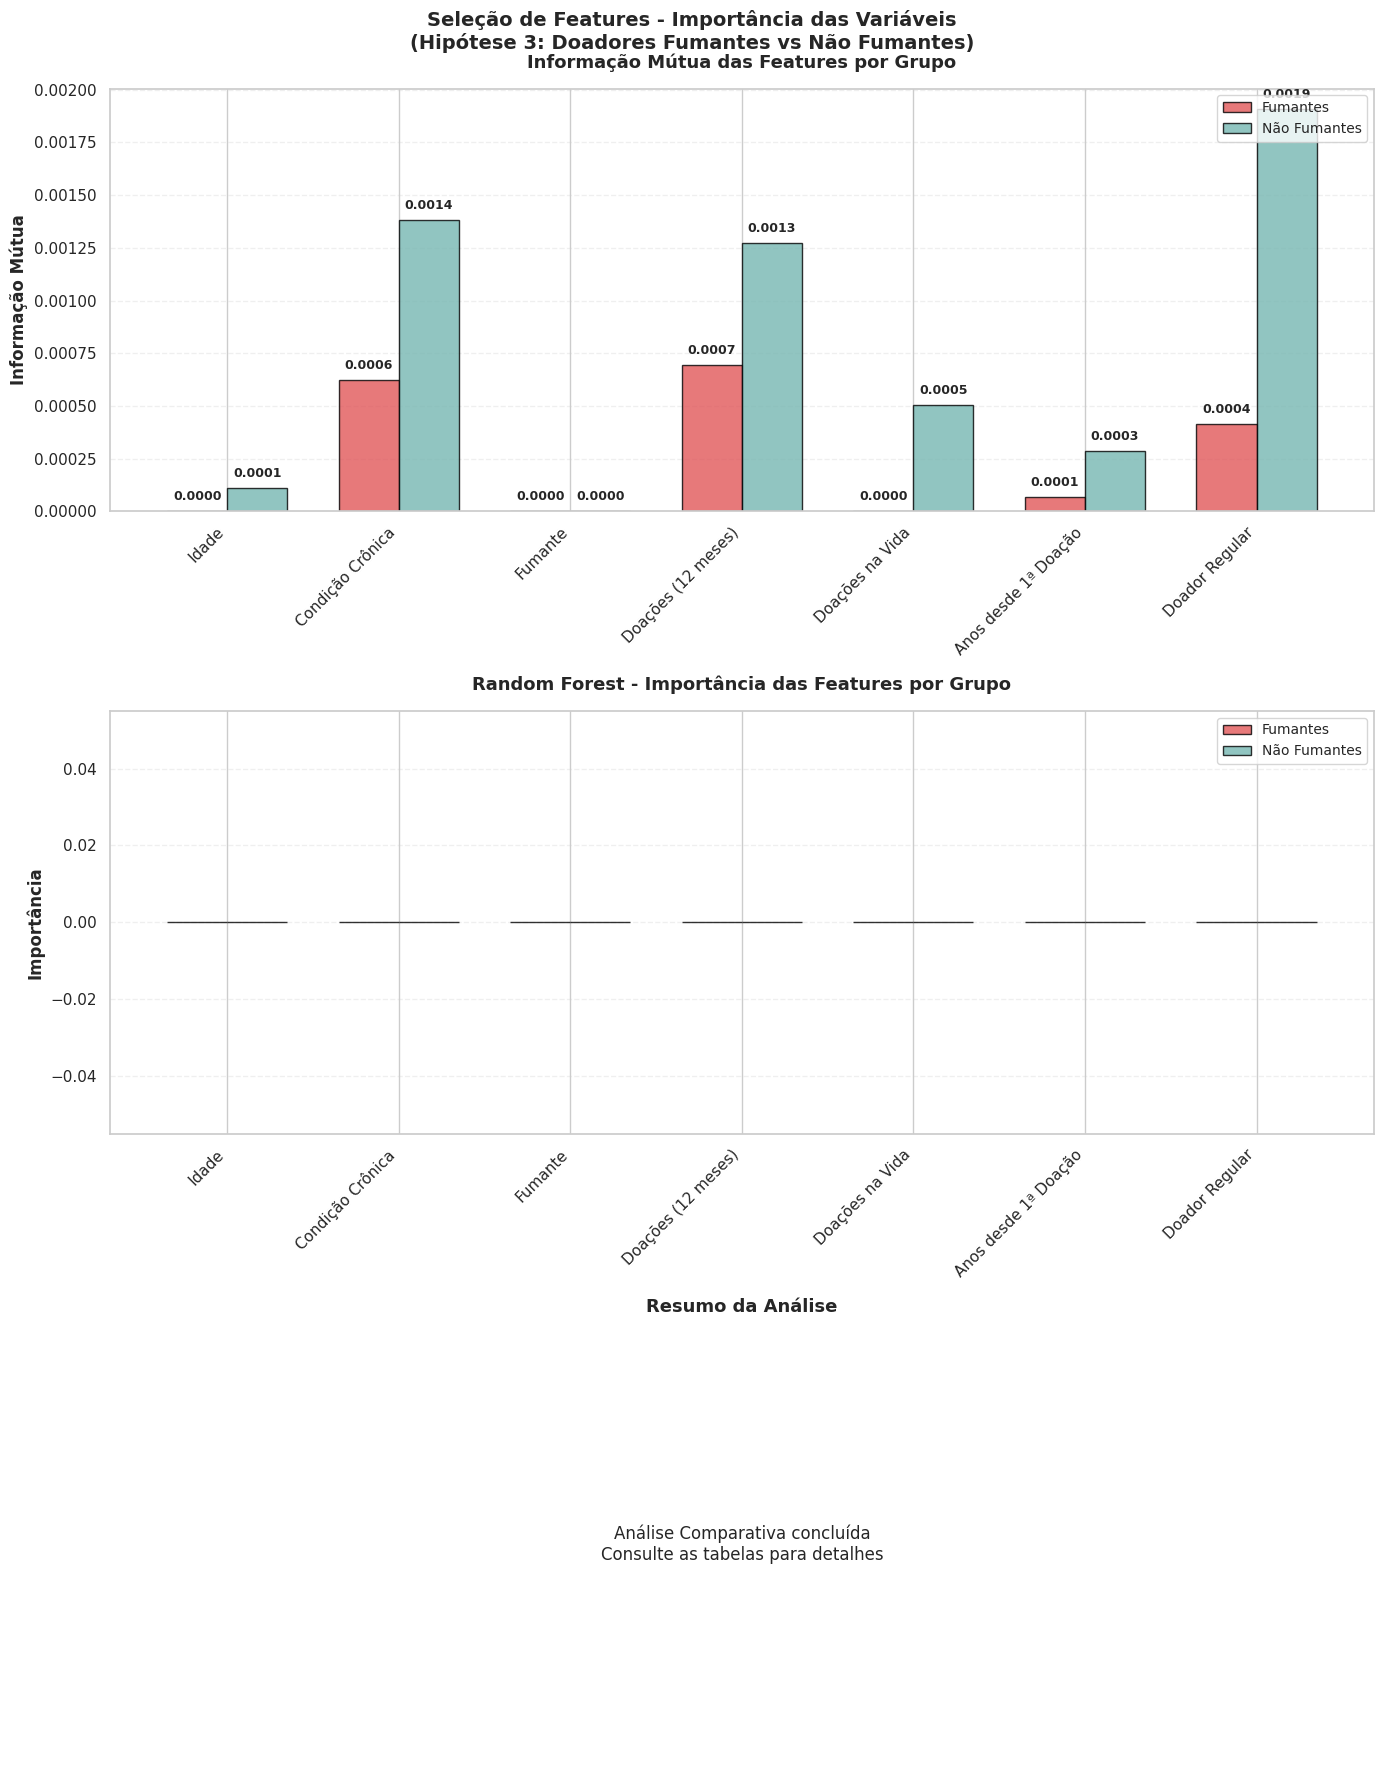

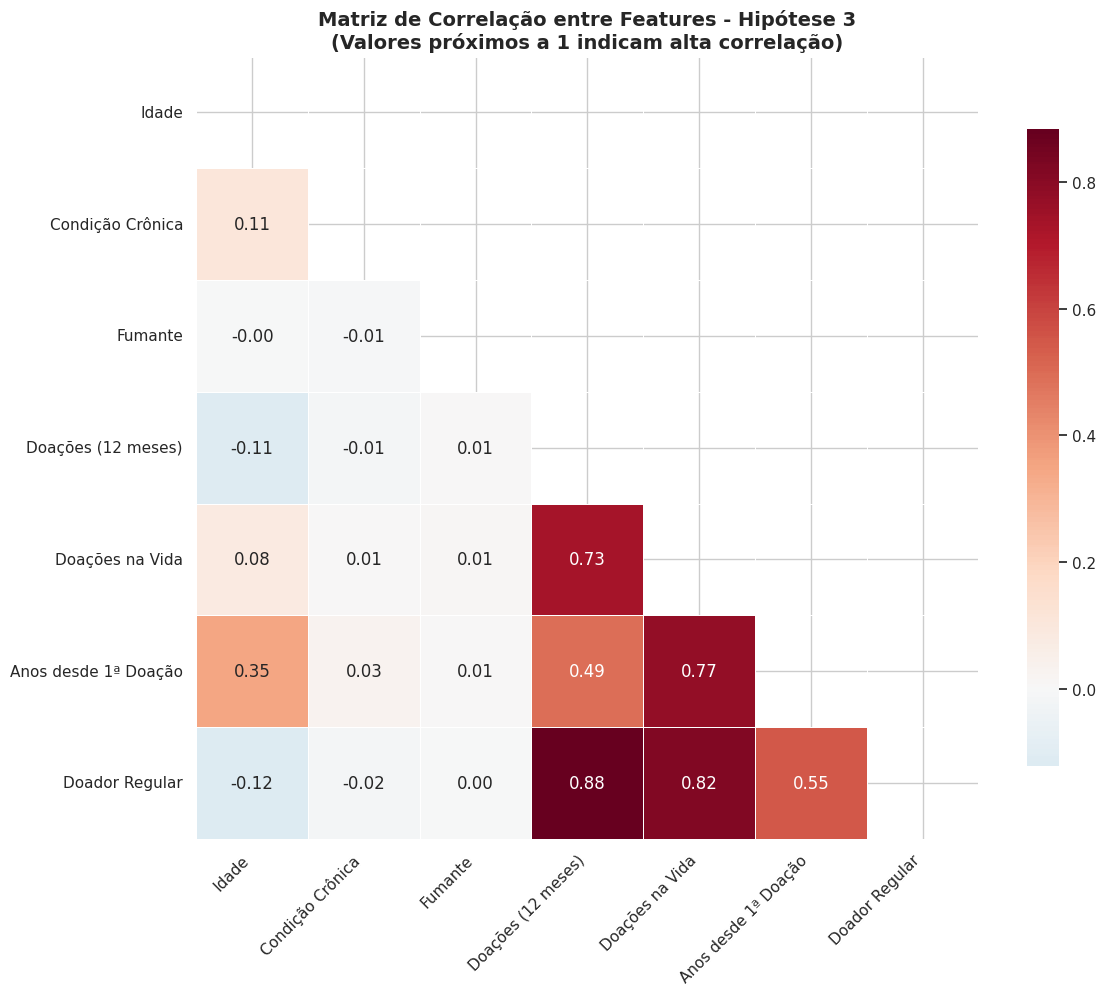

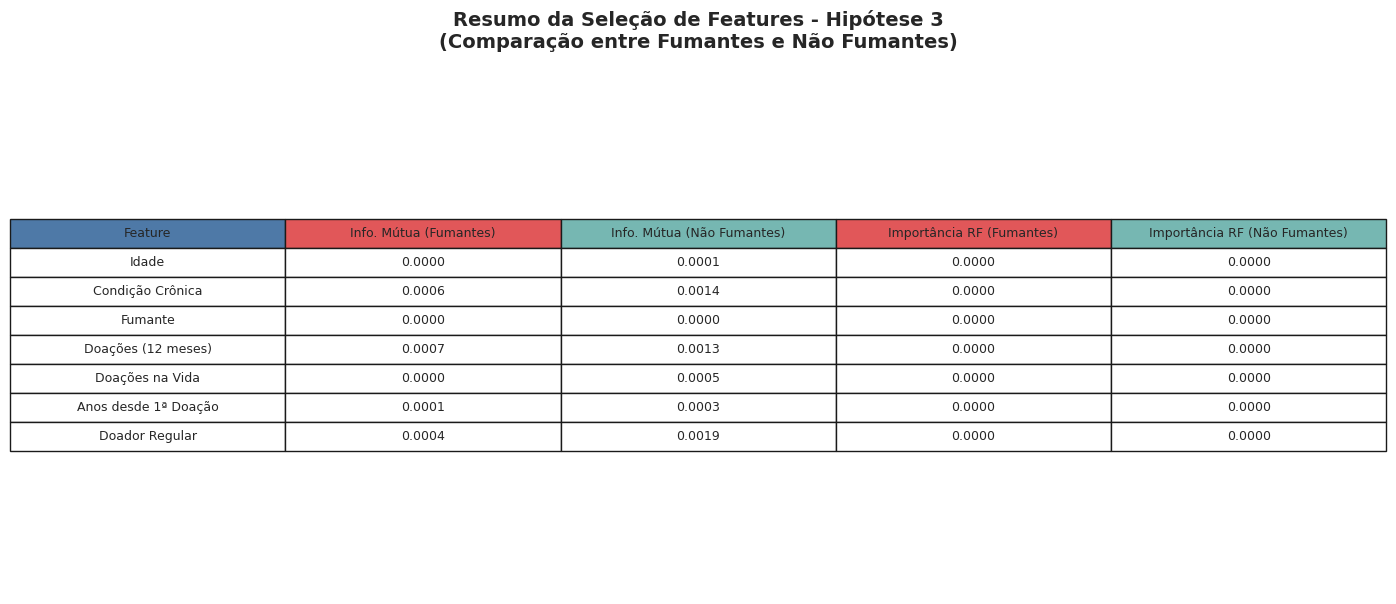

In [ ]:
X_fum = dataset_fumantes[variaveis_existentes].copy()
X_naofum = dataset_nao_fumantes[variaveis_existentes].copy()
if X_fum.isnull().sum().sum() > 0:
    X_fum = X_fum.fillna(X_fum.median())
if X_naofum.isnull().sum().sum() > 0:
    X_naofum = X_naofum.fillna(X_naofum.median())
scaler_fum = StandardScaler()
scaler_naofum = StandardScaler()
X_fum_scaled = scaler_fum.fit_transform(X_fum)
X_naofum_scaled = scaler_naofum.fit_transform(X_naofum)
X_fum = pd.DataFrame(X_fum_scaled, columns=variaveis_existentes)
X_naofum = pd.DataFrame(X_naofum_scaled, columns=variaveis_existentes)
mi_scores_fum = mutual_info_classif(X_fum, dataset_fumantes['smoker'], random_state=42)
mi_scores_naofum = mutual_info_classif(X_naofum, dataset_nao_fumantes['smoker'], random_state=42)
mi_df_fum = pd.DataFrame({
    'Feature': variaveis_existentes,
    'MI_Score_Fumantes': mi_scores_fum
}).sort_values('MI_Score_Fumantes', ascending=False)
mi_df_naofum = pd.DataFrame({
    'Feature': variaveis_existentes,
    'MI_Score_NaoFumantes': mi_scores_naofum
}).sort_values('MI_Score_NaoFumantes', ascending=False)

rf_fum = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_naofum = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_fum.fit(X_fum, dataset_fumantes['smoker'])
rf_naofum.fit(X_naofum, dataset_nao_fumantes['smoker'])
importancias_fum = pd.DataFrame({
    'Feature': variaveis_existentes,
    'Importancia_Fumantes': rf_fum.feature_importances_
}).sort_values('Importancia_Fumantes', ascending=False)
importancias_naofum = pd.DataFrame({
    'Feature': variaveis_existentes,
    'Importancia_NaoFumantes': rf_naofum.feature_importances_
}).sort_values('Importancia_NaoFumantes', ascending=False)

fig, axes = plt.subplots(3, 1, figsize=(14, 18))
fig.suptitle('Seleção de Features - Importância das Variáveis\n(Hipótese 3: Doadores Fumantes vs Não Fumantes)',
             fontsize=14, fontweight='bold', y=0.98)
ax1 = axes[0]
top_features = variaveis_existentes[:8]
nomes_traduzidos = [traducao_variaveis.get(f, f) for f in top_features]
x = np.arange(len(top_features))
width = 0.35
valores_fum = [mi_df_fum[mi_df_fum['Feature'] == f]['MI_Score_Fumantes'].values[0] if len(mi_df_fum[mi_df_fum['Feature'] == f]) > 0 else 0 for f in top_features]
valores_naofum = [mi_df_naofum[mi_df_naofum['Feature'] == f]['MI_Score_NaoFumantes'].values[0] if len(mi_df_naofum[mi_df_naofum['Feature'] == f]) > 0 else 0 for f in top_features]
bars1 = ax1.bar(x - width/2, valores_fum, width, label='Fumantes', color='#e15759', edgecolor='black', alpha=0.8)
bars2 = ax1.bar(x + width/2, valores_naofum, width, label='Não Fumantes', color='#76b7b2', edgecolor='black', alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(nomes_traduzidos, rotation=45, ha='right', fontsize=11)
ax1.set_ylabel('Informação Mútua', fontsize=12, fontweight='semibold')
ax1.set_title('Informação Mútua das Features por Grupo', fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
max_val = max(max(valores_fum), max(valores_naofum))
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height + (max_val * 0.02),
                f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height + (max_val * 0.02),
                f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2 = axes[1]
valores_imp_fum = [importancias_fum[importancias_fum['Feature'] == f]['Importancia_Fumantes'].values[0] if len(importancias_fum[importancias_fum['Feature'] == f]) > 0 else 0 for f in top_features]
valores_imp_naofum = [importancias_naofum[importancias_naofum['Feature'] == f]['Importancia_NaoFumantes'].values[0] if len(importancias_naofum[importancias_naofum['Feature'] == f]) > 0 else 0 for f in top_features]
bars3 = ax2.bar(x - width/2, valores_imp_fum, width, label='Fumantes', color='#e15759', edgecolor='black', alpha=0.8)
bars4 = ax2.bar(x + width/2, valores_imp_naofum, width, label='Não Fumantes', color='#76b7b2', edgecolor='black', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(nomes_traduzidos, rotation=45, ha='right', fontsize=11)
ax2.set_ylabel('Importância', fontsize=12, fontweight='semibold')
ax2.set_title('Random Forest - Importância das Features por Grupo', fontsize=13, fontweight='bold', pad=15)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
max_imp = max(max(valores_imp_fum), max(valores_imp_naofum))
for bar in bars3:
    height = bar.get_height()
    if height > 0:
        ax2.text(bar.get_x() + bar.get_width()/2., height + (max_imp * 0.02),
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars4:
    height = bar.get_height()
    if height > 0:
        ax2.text(bar.get_x() + bar.get_width()/2., height + (max_imp * 0.02),
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3 = axes[2]
ax3.text(0.5, 0.5, 'Análise Comparativa concluída\nConsulte as tabelas para detalhes',
         ha='center', va='center', fontsize=12, transform=ax3.transAxes)
ax3.set_title('Resumo da Análise', fontsize=13, fontweight='bold', pad=15)
ax3.axis('off')

plt.subplots_adjust(hspace=0.35, top=0.92)
plt.tight_layout()
plt.show()

X_all = dataset[variaveis_existentes].copy()
if X_all.isnull().sum().sum() > 0:
    X_all = X_all.fillna(X_all.median())
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)
X_all = pd.DataFrame(X_all_scaled, columns=variaveis_existentes)
corr_matrix = X_all.corr()
nomes_traduzidos = [traducao_variaveis.get(f, f) for f in corr_matrix.index]
corr_matrix_traduzida = corr_matrix.copy()
corr_matrix_traduzida.index = nomes_traduzidos
corr_matrix_traduzida.columns = nomes_traduzidos
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix_traduzida, dtype=bool))
sns.heatmap(corr_matrix_traduzida, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Matriz de Correlação entre Features - Hipótese 3\n(Valores próximos a 1 indicam alta correlação)',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, len(variaveis_existentes) * 0.6 + 2))
ax.axis('off')
ax.axis('tight')
tabela_data = []
for feat in variaveis_existentes:
    feat_trad = traducao_variaveis.get(feat, feat)
    mi_fum = mi_df_fum[mi_df_fum['Feature'] == feat]['MI_Score_Fumantes'].values[0] if len(mi_df_fum[mi_df_fum['Feature'] == feat]) > 0 else 0
    mi_naofum = mi_df_naofum[mi_df_naofum['Feature'] == feat]['MI_Score_NaoFumantes'].values[0] if len(mi_df_naofum[mi_df_naofum['Feature'] == feat]) > 0 else 0
    imp_fum = importancias_fum[importancias_fum['Feature'] == feat]['Importancia_Fumantes'].values[0] if len(importancias_fum[importancias_fum['Feature'] == feat]) > 0 else 0
    imp_naofum = importancias_naofum[importancias_naofum['Feature'] == feat]['Importancia_NaoFumantes'].values[0] if len(importancias_naofum[importancias_naofum['Feature'] == feat]) > 0 else 0
    tabela_data.append([
        feat_trad,
        f"{mi_fum:.4f}",
        f"{mi_naofum:.4f}",
        f"{imp_fum:.4f}",
        f"{imp_naofum:.4f}"
    ])
tabela = ax.table(cellText=tabela_data,
                  colLabels=['Feature', 'Info. Mútua (Fumantes)', 'Info. Mútua (Não Fumantes)',
                             'Importância RF (Fumantes)', 'Importância RF (Não Fumantes)'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#e15759', '#76b7b2', '#e15759', '#76b7b2'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1.2, 1.6)
plt.title('Resumo da Seleção de Features - Hipótese 3\n(Comparação entre Fumantes e Não Fumantes)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

####Redução de dimensionalidade

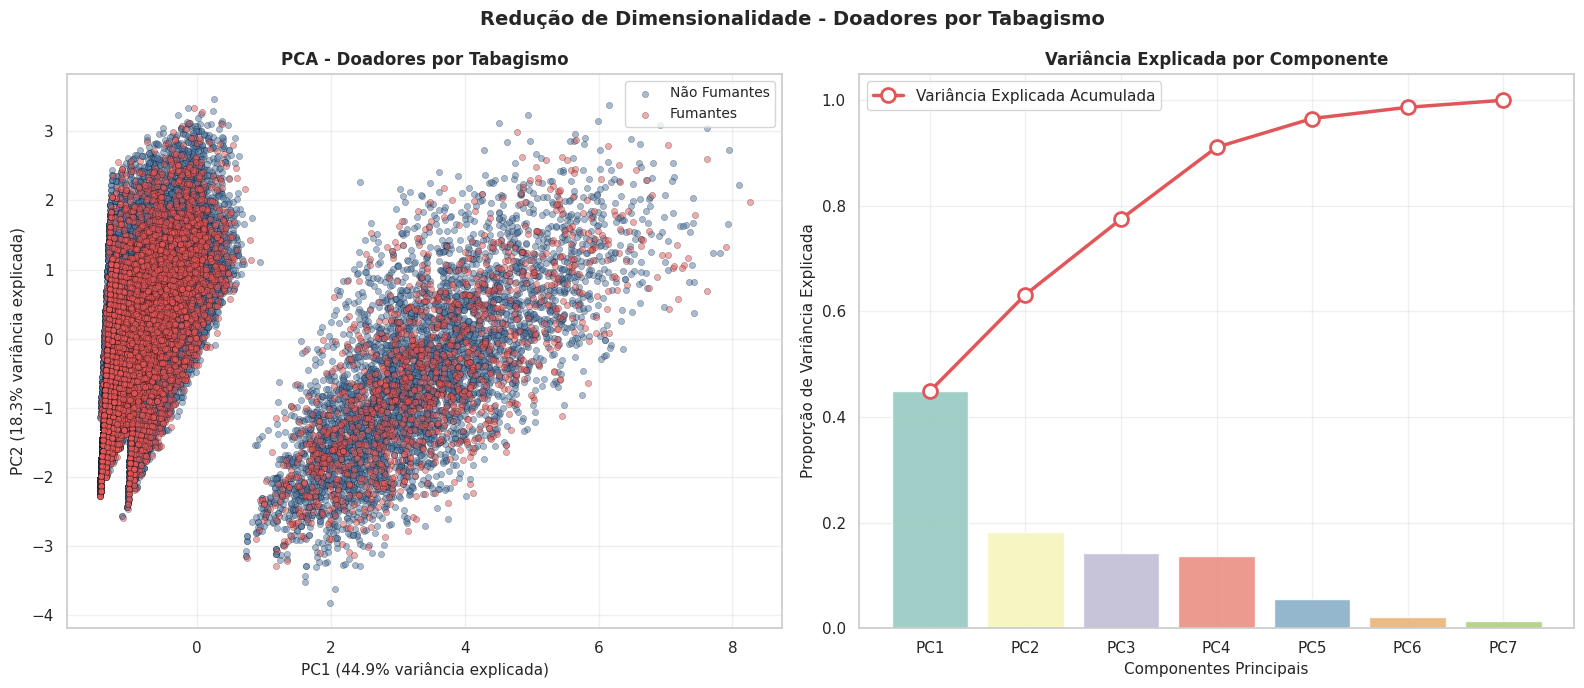

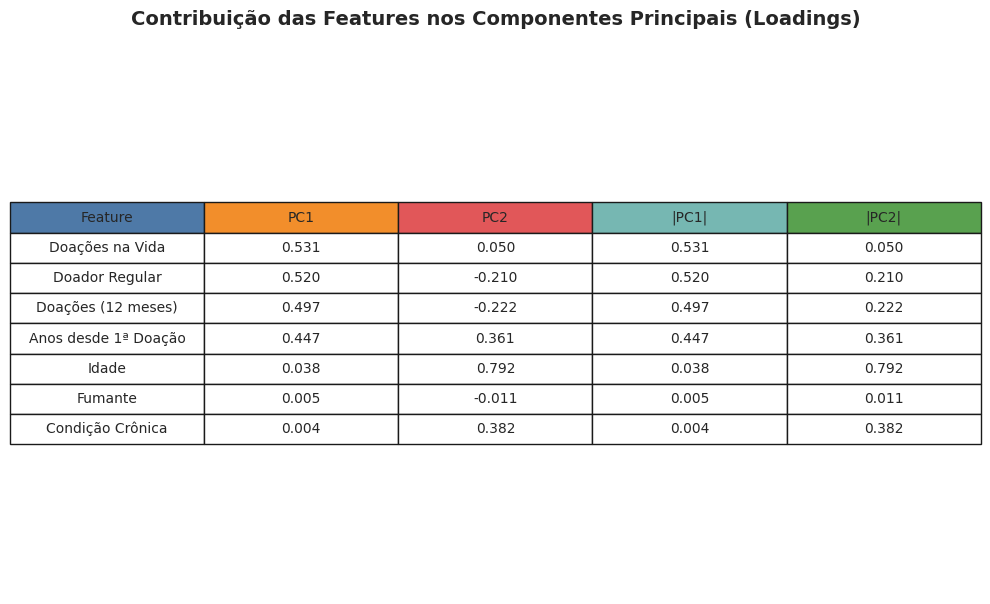

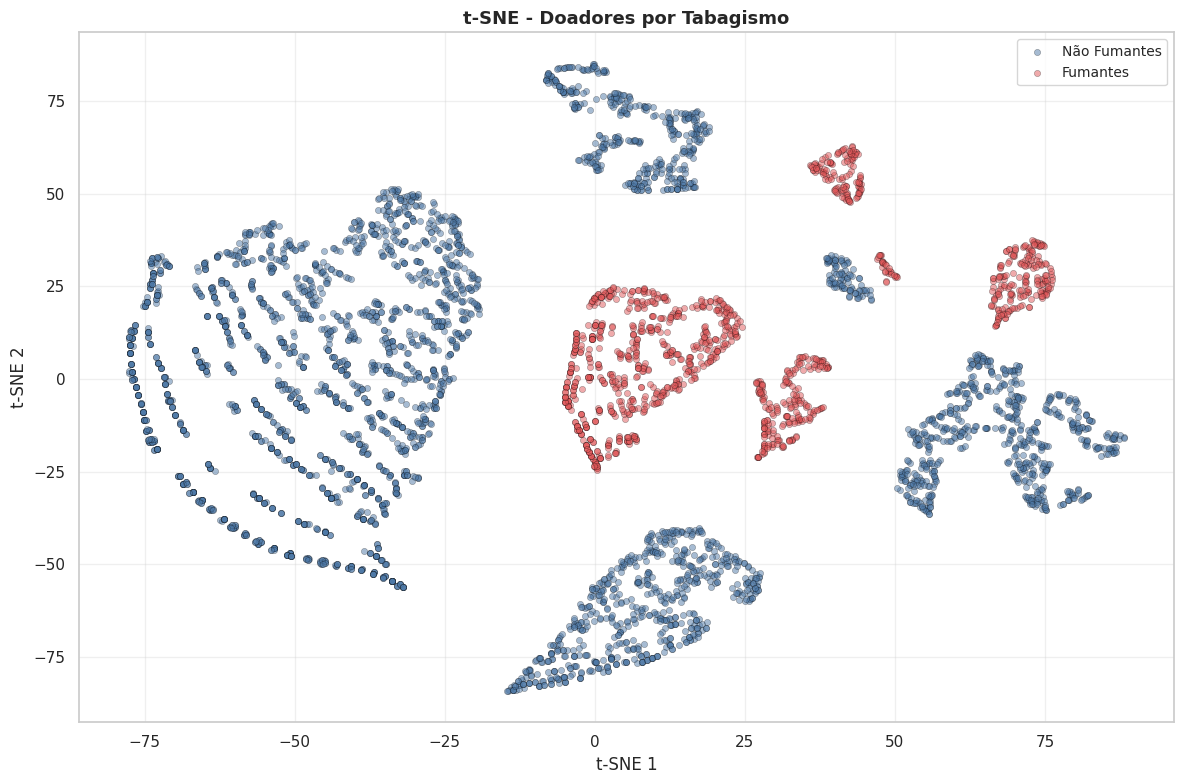

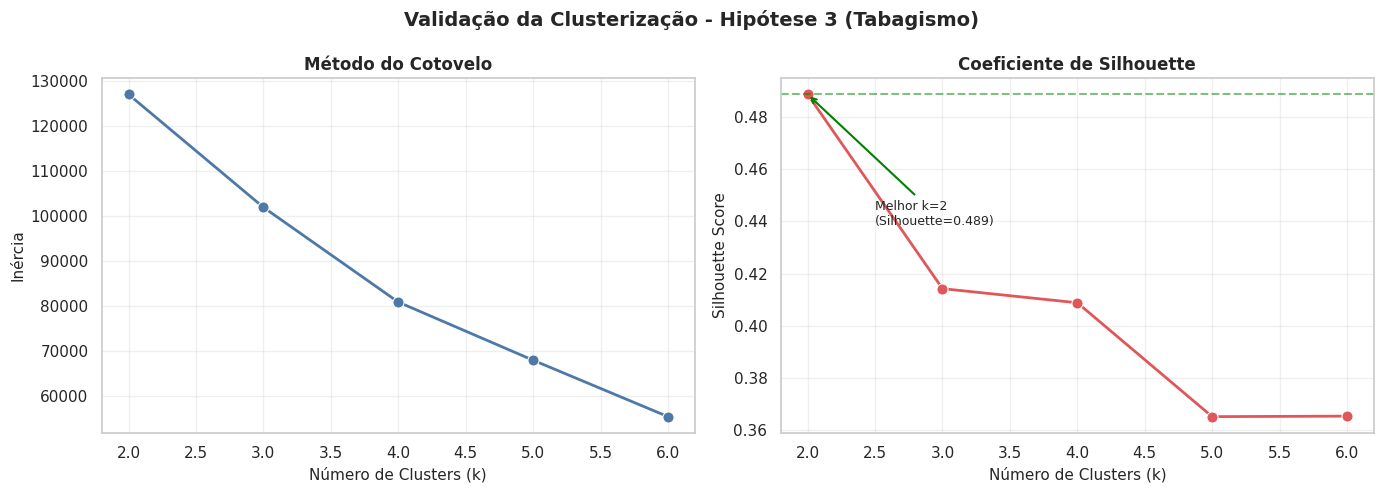

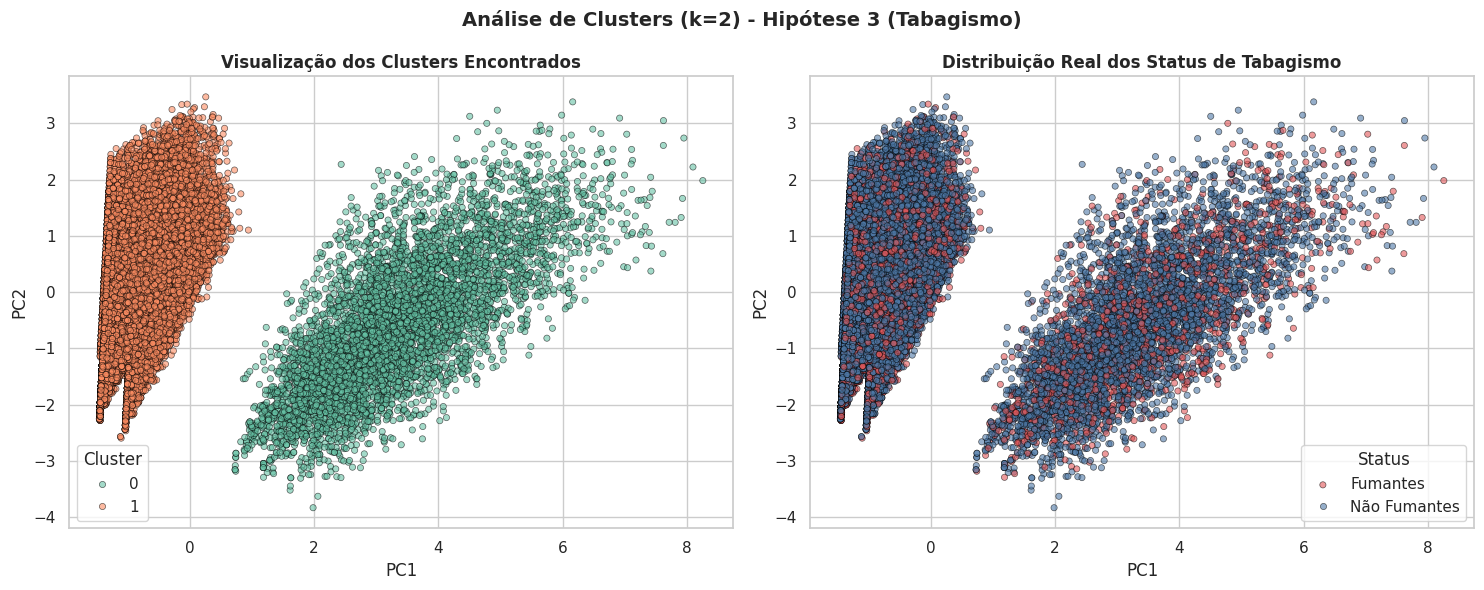

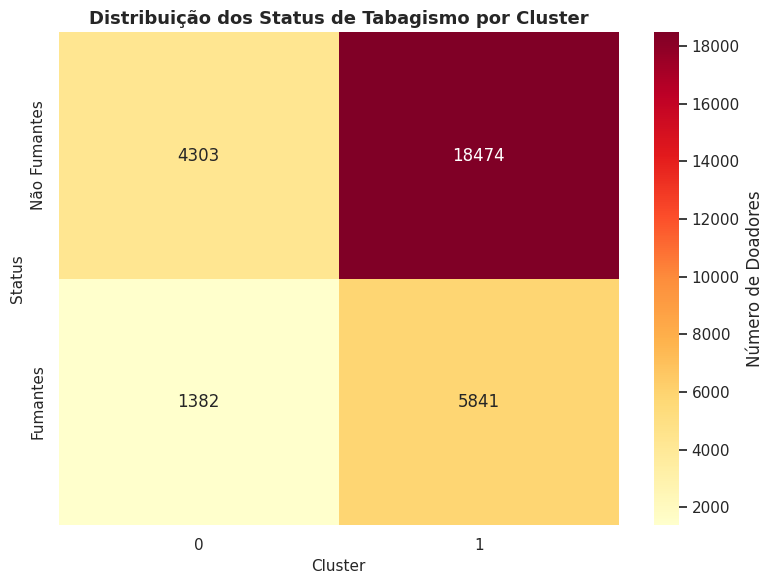

In [ ]:
y = dataset['smoker'].copy()
X = dataset[variaveis_existentes].copy()
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame({
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'Status': y
})
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=variaveis_existentes
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Redução de Dimensionalidade - Doadores por Tabagismo',
             fontsize=14, fontweight='bold')
ax1 = axes[0]
for status, cor in cores_fumantes_dict.items():
    subset = df_pca[df_pca['Status'] == status]
    nome = 'Fumantes' if status == 1 else 'Não Fumantes'
    ax1.scatter(subset['PC1'], subset['PC2'],
               label=nome, color=cor, alpha=0.5, s=20, edgecolor='black', linewidth=0.3)
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variância explicada)', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variância explicada)', fontsize=11)
ax1.set_title('PCA - Doadores por Tabagismo', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(alpha=0.3)
ax2 = axes[1]
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
var_df = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(explained_variance_ratio))],
    'Variância_Individual': explained_variance_ratio,
    'Variância_Acumulada': cumulative_variance
})
sns.barplot(data=var_df, x='Componente', y='Variância_Individual',
            alpha=0.9, ax=ax2, palette='Set3', legend=False, hue='Componente')
ax2.plot(range(len(cumulative_variance)), cumulative_variance,
         'o-', label='Variância Explicada Acumulada', color='#e15759',
         linewidth=2.5, markersize=10, markerfacecolor='white',
         markeredgewidth=2, markeredgecolor='#e15759')
ax2.set_xlabel('Componentes Principais', fontsize=11)
ax2.set_ylabel('Proporção de Variância Explicada', fontsize=11)
ax2.set_title('Variância Explicada por Componente', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, len(variaveis_existentes) * 0.6 + 2))
ax.axis('off')
ax.axis('tight')
tabela_loadings = []
for feat in variaveis_existentes:
    feat_trad = traducao_variaveis.get(feat, feat)
    tabela_loadings.append([
        feat_trad,
        f"{loadings.loc[feat, 'PC1']:.3f}",
        f"{loadings.loc[feat, 'PC2']:.3f}",
        f"{abs(loadings.loc[feat, 'PC1']):.3f}",
        f"{abs(loadings.loc[feat, 'PC2']):.3f}"
    ])
tabela_loadings = sorted(tabela_loadings, key=lambda x: float(x[3]), reverse=True)
tabela = ax.table(cellText=tabela_loadings,
                  colLabels=['Feature', 'PC1', 'PC2', '|PC1|', '|PC2|'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f'])
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.6)
plt.title('Contribuição das Features nos Componentes Principais (Loadings)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

max_samples = 5000
if len(X_scaled) > max_samples:
    indices = np.random.choice(len(X_scaled), max_samples, replace=False)
    X_sample = X_scaled[indices]
    y_sample = y.iloc[indices]
else:
    X_sample = X_scaled
    y_sample = y
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, learning_rate=200)
X_tsne = tsne.fit_transform(X_sample)
df_tsne = pd.DataFrame({
    'tSNE1': X_tsne[:, 0],
    'tSNE2': X_tsne[:, 1],
    'Status': y_sample
})

fig, ax = plt.subplots(figsize=(12, 8))
for status, cor in cores_fumantes_dict.items():
    subset = df_tsne[df_tsne['Status'] == status]
    nome = 'Fumantes' if status == 1 else 'Não Fumantes'
    ax.scatter(subset['tSNE1'], subset['tSNE2'],
               label=nome, color=cor, alpha=0.5, s=20, edgecolor='black', linewidth=0.3)
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('t-SNE - Doadores por Tabagismo', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

if len(variaveis_existentes) >= 2 and len(X_scaled) > 0:
    inertias = []
    silhouette_scores = []
    n_unique_status = len(np.unique(y))
    K_range = range(2, min(11, n_unique_status + 5))
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
        if k >= 2:
            score = silhouette_score(X_scaled, kmeans.labels_)
            silhouette_scores.append(score)

    if len(silhouette_scores) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Validação da Clusterização - Hipótese 3 (Tabagismo)',
                     fontsize=14, fontweight='bold')
        elbow_df = pd.DataFrame({'k': list(K_range), 'inertia': inertias})
        sns.lineplot(data=elbow_df, x='k', y='inertia', marker='o',
                     color='#4e79a7', linewidth=2, markersize=8, ax=axes[0])
        axes[0].set_xlabel('Número de Clusters (k)', fontsize=11)
        axes[0].set_ylabel('Inércia', fontsize=11)
        axes[0].set_title('Método do Cotovelo', fontsize=12, fontweight='bold')
        axes[0].grid(alpha=0.3)
        sil_df = pd.DataFrame({'k': list(K_range[:len(silhouette_scores)]), 'silhouette': silhouette_scores})
        sns.lineplot(data=sil_df, x='k', y='silhouette', marker='o',
                     color='#e15759', linewidth=2, markersize=8, ax=axes[1])
        axes[1].set_xlabel('Número de Clusters (k)', fontsize=11)
        axes[1].set_ylabel('Silhouette Score', fontsize=11)
        axes[1].set_title('Coeficiente de Silhouette', fontsize=12, fontweight='bold')
        axes[1].grid(alpha=0.3)
        best_idx = np.argmax(silhouette_scores)
        best_k = K_range[best_idx] if best_idx < len(K_range) else K_range[0]
        max_silhouette = max(silhouette_scores)
        axes[1].axhline(y=max_silhouette, color='green', linestyle='--', alpha=0.5, linewidth=1.5)
        axes[1].annotate(f'Melhor k={best_k}\n(Silhouette={max_silhouette:.3f})',
                        xy=(best_k, max_silhouette),
                        xytext=(best_k + 0.5, max_silhouette - 0.05),
                        fontsize=9,
                        arrowprops=dict(arrowstyle='->', color='green', lw=1.5)
                        )
        plt.tight_layout()
        plt.show()

        kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
        clusters = kmeans_final.fit_predict(X_scaled)
        df_clusters = pd.DataFrame({
            'PC1': X_pca_2d[:, 0],
            'PC2': X_pca_2d[:, 1],
            'Cluster': clusters,
            'Status': y
        })

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle(f'Análise de Clusters (k={best_k}) - Hipótese 3 (Tabagismo)',
                     fontsize=14, fontweight='bold')
        sns.scatterplot(data=df_clusters, x='PC1', y='PC2', hue='Cluster',
                       palette='Set2', alpha=0.6, s=20, ax=axes[0],
                       edgecolor='black', linewidth=0.5)
        axes[0].set_title('Visualização dos Clusters Encontrados', fontsize=12, fontweight='bold')
        axes[0].legend(title='Cluster')
        sns.scatterplot(data=df_clusters, x='PC1', y='PC2', hue='Status',
                       palette=cores_fumantes_dict, alpha=0.6, s=20, ax=axes[1],
                       edgecolor='black', linewidth=0.5)
        axes[1].set_title('Distribuição Real dos Status de Tabagismo', fontsize=12, fontweight='bold')
        axes[1].legend(title='Status', labels=['Fumantes', 'Não Fumantes'])
        plt.tight_layout()
        plt.show()

        cluster_distribution = pd.crosstab(y, clusters)
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cluster_distribution, annot=True, fmt='d', cmap='YlOrRd',
                   cbar_kws={'label': 'Número de Doadores'}, ax=ax)
        ax.set_title('Distribuição dos Status de Tabagismo por Cluster',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Cluster', fontsize=11)
        ax.set_ylabel('Status', fontsize=11)
        ax.set_yticklabels(['Não Fumantes', 'Fumantes'])
        plt.tight_layout()
        plt.show()

###Conclusão final Hipótese 3


#####Conclusão - média
A maior quantidade de doadores é não fumantes, isso pode implicar pelo fato de que fumantes tendem a possuir mais condições crônicas, ou que os impedem de realizar doação de sangue.


#####Conclusão - média
A idade média de doadores de sangue que fumam e não fumam, é a mesma. Isso é por conta de que a faixa etária para a doação de sangue é entre 18 e 69 anos, e isso limita a média das idades.

#####Conclusão - média
A média de doações na vida entre fumantes e não fumantes é maior para fumantes.

#####Conclusão - média
Entre os fumantes e não fumantes, as doações regulares é maior para doadores fumantes.

#####Conclusão - desvio padrão
Ambos os grupos apresentam percentuais de doadores regulares muito próximos, em torno de 19%, com diferença de apenas 0,2 pontos percentuais.

Isso indica que não há diferença significativa entre os grupos analisados em relação à regularidade de doação. O baixo percentual geral (menos de 20%) sugere um desafio comum para a retenção de doadores, independentemente do grupo.

#####Conclusão - histograma
Os doadores fumantes apresentam densidades ligeiramente superiores aos não fumantes em todas as faixas etárias, com a maior diferença ocorrendo entre 50-60 anos (diferença de 0,002).

Ambas as curvas têm forma muito semelhante, com pico entre 40-55 anos e faixa etária de 20 a 70 anos. A diferença consistente sugere que fumantes são mais prevalentes em todas as idades, especialmente na faixa de maior concentração de doadores.

#####Conclusão -- boxplot
O grupo de não fumantes apresenta maior complexidade etária: embora a maioria seja mais velha (mediana 54 anos), há um número significativo de jovens que reduz a média para 44 anos. Já os fumantes têm distribuição mais consistente, com média e mediana próximas (46 e 47 anos).

#####Conclusão - boxplot
Os doadores de sangue, tanto fumantes quanto não fumantes, apresentam IMC acima do ideal (mediana 28-29). A diferença entre os grupos é pequena (1 ponto), sugerindo que o tabagismo não é o principal fator associado ao IMC elevado nessa população. Ambos os grupos estão predominantemente na faixa de sobrepeso, o que pode ter implicações para a elegibilidade à doação.


#####Conclusão - matriz correlação
O tabagismo não modifica as relações entre as variáveis analisadas. Fumantes e não fumantes apresentam praticamente as mesmas correlações: o tempo de cadastro é o fator mais fortemente associado ao total de doações (r≈0,82), idade influencia doações acumuladas (r≈0,73-0,75) mas não as doações recentes, e a regularidade tende a diminuir com a idade em ambos os grupos.




#####Conclusão - normalização e padronização
Fumantes e não fumantes têm distribuições etárias praticamente idênticas antes e depois do escalonamento.

O tabagismo não influencia a distribuição etária dos doadores. Fumantes e não fumantes têm perfis de idade praticamente idênticos, e as transformações produzem resultados equivalentes para ambos os grupos.

#####Conclusão - tratamento de outliers
Não há diferenças significativas entre fumantes e não fumantes na presença e distribuição de outliers. Ambos os grupos apresentam taxas de outliers muito próximas em todas as variáveis analisadas.

1. Fumantes apresentam taxas de outliers ligeiramente superiores em todas as variáveis, com destaque para:

    * Doações (últimos 12 meses): +0,7 pontos percentuais

    * Doações na Vida: +0,4 pontos percentuais

    * IMC: +0,1 pontos percentuais

2. Variáveis críticas com alta taxa de outliers (>10%):

    * Doações na Vida (~16%) - a mais crítica em ambos os grupos

    * Doações (últimos 12 meses) (~12%) - também crítica

4. Variáveis com moderada taxa de outliers (5-10%):

    * Dias desde última doação (~7%) - requer atenção

5. Variáveis com baixa taxa de outliers (<5%):

    * Anos desde a 1ª doação (~1,3%) - aceitável

    * IMC (~0,3-0,4%) - excelente

    * Idade (0%) - perfeita


#####Conclusão - seleção de features
1. Correlação das Features com o Tabagismo

    * Todas as correlações são extremamente baixas (<0,012), indicando que não há relação linear entre nenhuma das variáveis e o tabagismo. Isso sugere que fumantes e não fumantes têm perfis muito semelhantes.


2. Informação Mútua com o Tabagismo

    * Mostra valores muito baixos, confirmando que não há relação significativa entre as variáveis e o tabagismo.


3. Random Forest - Importância das Features

    * Também mostra valores de importância muito baixos, confirmando que nenhuma variável tem capacidade significativa de predizer o tabagismo.


4. A matriz de correlação mostra que as features têm baixíssima correlação entre si (valores próximos de 0), indicando:

    * Não há multicolinearidade significativa

    * As variáveis são independentes entre si

    * Todas podem ser utilizadas sem risco de redundância



#####Conclusão -- redução de dimensionalidade
1. Correlação das Features com o Tabagismo

    * Todas as correlações são extremamente baixas (<0,012), indicando que não há relação linear entre nenhuma das variáveis e o tabagismo. Isso sugere que fumantes e não fumantes têm perfis muito semelhantes.


2. Informação Mútua com o Tabagismo

    * Mostra valores muito baixos, confirmando que não há relação significativa entre as variáveis e o tabagismo.


3. Random Forest - Importância das Features

    * Também mostra valores de importância muito baixos, confirmando que nenhuma variável tem capacidade significativa de predizer o tabagismo.


4. A matriz de correlação mostra que as features têm baixíssima correlação entre si (valores próximos de 0), indicando:

    * Não há multicolinearidade significativa

    * As variáveis são independentes entre si

    * Todas podem ser utilizadas sem risco de redundância



##Conclusão